# پروژه مدل‌سازی صندوق بازنشستگی (PAYG-DB)

# نام استاد: دکتر امیرتیمور پاینده
 
# نام دانشجو: محمد اشکوری
# شماره دانشجویی : 404422013

## **هدف:** ارزیابی تراز و پایداری بلندمدت صندوق در افق 40 ساله (1405-1445)

**ساختار مدل:** مبتنی بر داده‌های  اعضا، مفروضات جمعیتی و مالی

---
## بخش ۱: فراخوانی کتابخانه‌ها و تنظیمات محیط
در این بخش، کتابخانه‌های مورد نیاز برای تحلیل داده‌های اکسل و محاسبات ریاضی را بارگذاری می‌کنیم.


In [1]:
import pandas as pd
import numpy as np
import micropip

# نصب پکیج برای خواندن فایل‌های اکسل در محیط Pyodide
try:
    import openpyxl
except ImportError:
    await micropip.install("openpyxl")
    import openpyxl

print("کتابخانه‌ها با موفقیت بارگذاری شدند. آماده شروع هستیم.")


کتابخانه‌ها با موفقیت بارگذاری شدند. آماده شروع هستیم.


In [2]:
from IPython.display import display, HTML

display(HTML("""
<style>
.jp-RenderedMarkdown,
.jp-RenderedHTMLCommon {
    direction: rtl !important;
    text-align: right !important;
    unicode-bidi: plaintext;
}

.jp-RenderedMarkdown p,
.jp-RenderedMarkdown h1,
.jp-RenderedMarkdown h2,
.jp-RenderedMarkdown h3,
.jp-RenderedMarkdown ul,
.jp-RenderedMarkdown ol,
.jp-RenderedMarkdown li {
    direction: rtl !important;
    text-align: right !important;
}

.jp-RenderedMarkdown code,
.jp-RenderedMarkdown pre {
    direction: ltr !important;
    text-align: left !important;
    unicode-bidi: embed;
}
</style>
"""))


### بخش ۲: بارگذاری داده‌های خام
فایل اکسل `دیتای نهایی.xlsx` شامل بلوک‌های داده‌ای متنوعی است که در یک شیت کنار هم قرار گرفته‌اند.
در این بخش فایل را به صورت خام فراخوانی می‌کنیم.


In [3]:
FILE_PATH = "دیتای نهایی.xlsx"

xls = pd.ExcelFile(FILE_PATH, engine="openpyxl")
df_raw = pd.read_excel(
    FILE_PATH,
    sheet_name=xls.sheet_names[0],
    engine="openpyxl"
)

print("Sheet name:", xls.sheet_names[0])
print("df_raw.shape =", df_raw.shape)
df_raw.head(3)


Sheet name: PAYG_DB_Model
df_raw.shape = (514, 56)


,ASSUMPTIONS,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 46,Unnamed: 47,Unnamed: 48,NEW_ENTRANTS_TABLE,Unnamed: 50,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55
0,Assumption_Key,Value,Description,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,New_Entrants_Table,NaN,NaN,NaN,NaN,NaN,NaN
1,Valuation_Year,1405,سال جاری ارزیابی صندوق (شمسی),NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Disability_Benefit_Factor,NaN,NaN,Calendar_Year,New_Entrant_Count,Average_Age,Male_Ratio,Female_Ratio,Initial_Annual_Salary,Initial_Service
2,Projection_Horizon,40,افق زمانی پیش‌بینی جریان‌های نقدی (سال),NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,1405,12,27,0.7,0.3,120000000,0


### بخش ۳: استخراج و پاک‌سازی مفروضات مدل

مفروضات بیم‌سنجی و مالی، مبنای اصلی پیش‌بینی‌های بلندمدت صندوق هستند. 
این مفروضات شامل سال ارزیابی، افق پیش‌بینی، نرخ رشد حقوق، نرخ افزایش مستمری‌ها و نرخ تنزیل است.

در این مرحله، اطلاعات بلوک `ASSUMPTIONS` از داده خام استخراج، پاک‌سازی و به ساختاری استاندارد برای استفاده در مراحل بعدی تبدیل می‌شود.


In [4]:
# استخراج سه ستون نخست بلوک ASSUMPTIONS
assumptions_df = df_raw.iloc[0:6, 0:3].copy()

# نام‌گذاری استاندارد ستون‌ها
assumptions_df.columns = ["Assumption_Key", "Value", "Description"]

# حذف ردیف عنوانیِ اضافی که به صورت داده وارد شده است
assumptions_df = assumptions_df[
    assumptions_df["Assumption_Key"] != "Assumption_Key"
].copy()

# حذف ردیف‌هایی که کلید مفروضه ندارند
assumptions_df = assumptions_df.dropna(subset=["Assumption_Key"])

# تبدیل مقدارها به عدد، در صورت امکان
assumptions_df["Value"] = pd.to_numeric(
    assumptions_df["Value"],
    errors="coerce"
)

# نمایش جدول مفروضات تمیز
print("جدول مفروضات با موفقیت استخراج و پاک‌سازی شد.")
assumptions_df


جدول مفروضات با موفقیت استخراج و پاک‌سازی شد.


,Assumption_Key,Value,Description
1,Valuation_Year,1405.00,سال جاری ارزیابی صندوق (شمسی)
2,Projection_Horizon,40.00,افق زمانی پیش‌بینی جریان‌های نقدی (سال)
3,Salary_Growth_Rate,0.25,نرخ رشد سالانه دستمزدها (تورم عمومی)
4,Benefit_Indexation_Rate,0.20,نرخ سالانه افزایش حقوق بازنشستگان
5,Discount_Rate,0.25,نرخ تنزیل برای محاسبات ارزش فعلی تعهدات


In [5]:
# تبدیل جدول مفروضات به دیکشنری استاندارد
assumptions = dict(
    zip(
        assumptions_df["Assumption_Key"],
        assumptions_df["Value"]
    )
)

# تعریف متغیرهای اصلی مدل
VALUATION_YEAR = int(assumptions["Valuation_Year"])
PROJECTION_HORIZON = int(assumptions["Projection_Horizon"])

SALARY_GROWTH_RATE = float(assumptions["Salary_Growth_Rate"])
BENEFIT_INDEXATION_RATE = float(
    assumptions["Benefit_Indexation_Rate"]
)
DISCOUNT_RATE = float(assumptions["Discount_Rate"])

print("مفروضات اصلی مدل:")
print(f"سال ارزیابی: {VALUATION_YEAR}")
print(f"افق پیش‌بینی: {PROJECTION_HORIZON} سال")
print(f"نرخ رشد سالانه حقوق: {SALARY_GROWTH_RATE:.0%}")
print(f"نرخ افزایش سالانه مستمری: {BENEFIT_INDEXATION_RATE:.0%}")
print(f"نرخ تنزیل: {DISCOUNT_RATE:.0%}")


مفروضات اصلی مدل:
سال ارزیابی: 1405
افق پیش‌بینی: 40 سال
نرخ رشد سالانه حقوق: 25%
نرخ افزایش سالانه مستمری: 20%
نرخ تنزیل: 25%


---
 # بخش ۴: استخراج و پاک‌سازی داده‌های اعضا



In [6]:
# بخش ۴: استخراج و پاک‌سازی داده‌های اعضا

# استخراج اعضا از ردیف 15 اکسل به بعد
# در pandas، شماره‌گذاری ردیف از صفر شروع می‌شود؛ بنابراین index=14 است.
df_members = df_raw.iloc[14:, 0:17].copy()

# نام‌گذاری استاندارد ستون‌ها
df_members.columns = [
    'Member_ID',
    'Status',
    'Sex',
    'Birth_Year',
    'Hire_Year',
    'Credited_Service',
    'Salary_1401',
    'Salary_1402',
    'Salary_1403',
    'Salary_1404',
    'Salary_1405',
    'Current_Annual_Salary',
    'Retirement_Age',
    'Expected_Retirement_Year',
    'Pension_Start_Year',
    'Accrual_Rate',
    'Mortality_Table'
]

# حذف ردیف‌هایی که شناسه عضو ندارند
df_members = df_members.dropna(
    subset=['Member_ID']
).copy()

# استانداردسازی شناسه عضو
df_members['Member_ID'] = pd.to_numeric(
    df_members['Member_ID'],
    errors='coerce'
)

# حذف رکوردهایی که شناسه عضو عددی معتبر ندارند
df_members = df_members.dropna(
    subset=['Member_ID']
).copy()

df_members['Member_ID'] = df_members['Member_ID'].astype(int)

# ستون‌های مربوط به حقوق
salary_cols = [
    'Salary_1401',
    'Salary_1402',
    'Salary_1403',
    'Salary_1404',
    'Salary_1405',
    'Current_Annual_Salary'
]

# تبدیل مقادیر حقوق به عدد
for col in salary_cols:
    df_members[col] = pd.to_numeric(
        df_members[col],
        errors='coerce'
    ).fillna(0)

# تبدیل سایر ستون‌های عددی موردنیاز
numeric_cols = [
    'Birth_Year',
    'Hire_Year',
    'Credited_Service',
    'Retirement_Age',
    'Expected_Retirement_Year',
    'Pension_Start_Year',
    'Accrual_Rate'
]

for col in numeric_cols:
    df_members[col] = pd.to_numeric(
        df_members[col],
        errors='coerce'
    )

# کنترل اولیه خروجی
print('تعداد اعضای بارگذاری‌شده:', len(df_members))

display(df_members.head())


تعداد اعضای بارگذاری‌شده: 500


,Member_ID,Status,Sex,Birth_Year,Hire_Year,Credited_Service,Salary_1401,Salary_1402,Salary_1403,Salary_1404,Salary_1405,Current_Annual_Salary,Retirement_Age,Expected_Retirement_Year,Pension_Start_Year,Accrual_Rate,Mortality_Table
14,1,Active,M,1354,1377,28,162400000,203000000,253800000,317300000,396680988,396680988,60,1414,1414,0.015,ITPF_M_1405
15,2,Active,F,1356,1398,7,95500000,119400000,149300000,186600000,233232032,233232032,60,1416,1416,0.015,ITPF_F_1405
16,3,Active,M,1348,1385,20,190600000,238200000,297700000,372100000,465092453,465092453,60,1408,1408,0.015,ITPF_M_1405
17,4,Retired,F,1322,1372,33,0,0,0,0,0,213936737,60,1382,1382,0.015,ITPF_F_1405
18,5,Active,M,1366,1402,3,169000000,211200000,264000000,330000000,412440796,412440796,60,1426,1426,0.015,ITPF_M_1405


#  گزارش بخش ۴: استخراج و پاک‌سازی داده‌های اعضا

در این مرحله، اطلاعات اعضای صندوق از فایل خام استخراج می‌شود.

بلوک مورد استفاده:

`MEMBERS`

اطلاعات استخراج‌شده شامل موارد زیر است:

- مشخصات فردی اعضا
- جنسیت
- سال تولد
- سال استخدام
- سابقه خدمت
- حقوق سال‌های گذشته
- حقوق جاری
- سن بازنشستگی
- سال مورد انتظار بازنشستگی
- نرخ accrual
- جدول مرگ‌ومیر

اقدامات این مرحله:

1. استخراج ردیف‌های مربوط به اعضا
2. انتخاب ۱۷ ستون اصلی
3. استانداردسازی نام ستون‌ها
4. حذف ردیف‌های خالی
5. تبدیل مقادیر حقوقی به داده عددی
6. آماده‌سازی جدول برای استفاده در موتور پیش‌بینی


---
# بخش ۵: استخراج، ساختاربندی و کنترل اولیه داده‌

In [7]:
import micropip
await micropip.install("openpyxl")


In [8]:
#بخش ۵: استخراج، ساختاربندی و کنترل اولیه داده
from pathlib import Path
import pandas as pd
import numpy as np

file_path = Path("دیتای نهایی.xlsx")
if not file_path.exists():
    file_path = Path("[/mnt/data/دیتای](https://storage.gapgpt.app/media/code_interpreter/31d1e380-41f0-4689-8b79-24f64a3595c1/%D8%AF%DB%8C%D8%AA%D8%A7%DB%8C) نهایی.xlsx")

sheet_name = "PAYG_DB_Model"

raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

def extract_horizontal_block(df, header_row, start_col, end_col, data_start_row):
    headers = df.iloc[header_row, start_col:end_col + 1].tolist()

    block = df.iloc[data_start_row:, start_col:end_col + 1].copy()
    block.columns = headers

    block = block.dropna(axis=0, how="all")
    block = block.dropna(axis=1, how="all")

    return block.reset_index(drop=True)

def find_header_row(df, target_name):
    for row_index in range(df.shape[0]):
        row_values = df.iloc[row_index].astype(str).str.strip().tolist()
        if target_name in row_values:
            return row_index
    return None

# استخراج جداول مفروضات و نرخ‌ها
df_assumptions = extract_horizontal_block(
    raw, header_row=1, start_col=0, end_col=2, data_start_row=2
)

df_mortality = extract_horizontal_block(
    raw, header_row=1, start_col=19, end_col=25, data_start_row=2
)

df_withdrawal = extract_horizontal_block(
    raw, header_row=1, start_col=27, end_col=31, data_start_row=2
)

df_retirement = extract_horizontal_block(
    raw, header_row=1, start_col=34, end_col=39, data_start_row=2
)

df_disability = extract_horizontal_block(
    raw, header_row=1, start_col=42, end_col=46, data_start_row=2
)

df_new_entry = extract_horizontal_block(
    raw, header_row=1, start_col=49, end_col=55, data_start_row=2
)

# یافتن خودکار ردیف هدر جدول اعضا
member_header_row = find_header_row(raw, "Member_ID")

if member_header_row is None:
    raise ValueError("ستون Member_ID در شیت پیدا نشد.")

member_headers = raw.iloc[member_header_row, 0:17].tolist()

df_members = raw.iloc[member_header_row + 1:, 0:17].copy()
df_members.columns = member_headers

member_id_col = df_members.columns[0]
df_members = df_members.dropna(subset=[member_id_col]).reset_index(drop=True)

# تبدیل ستون‌های عددی اعضا
member_numeric_cols = [
    "Member_ID",
    "Birth_Year",
    "Hire_Year",
    "Credited_Service",
    "Salary_1401",
    "Salary_1402",
    "Salary_1403",
    "Salary_1404",
    "Salary_1405",
    "Current_Annual_Salary",
    "Retirement_Age",
    "Expected_Retirement_Year",
    "Pension_Start_Year",
    "Accrual_Rate"
]

for col in member_numeric_cols:
    if col in df_members.columns:
        df_members[col] = pd.to_numeric(df_members[col], errors="coerce")

# نمایش کنترل‌های استخراج
print("--- خلاصه کنترل استخراج داده‌ها ---")
print("ابعاد داده خام:", raw.shape)
print("ردیف هدر اعضا:", member_header_row)
print("تعداد اعضا:", df_members.shape[0])
print("ابعاد مفروضات:", df_assumptions.shape)
print("ابعاد جدول مرگ و میر:", df_mortality.shape)
print("ابعاد جدول ترک خدمت:", df_withdrawal.shape)
print("ابعاد جدول بازنشستگی:", df_retirement.shape)
print("ابعاد جدول ازکارافتادگی:", df_disability.shape)
print("ابعاد جدول ورودی جدید:", df_new_entry.shape)

print("\nستون‌های جدول اعضا:")
print(df_members.columns.tolist())

print("\nپنج ردیف اول جدول اعضا:")
display(df_members.head())

print("\nده ردیف اول جدول مفروضات:")
display(df_assumptions.head(10))


--- خلاصه کنترل استخراج داده‌ها ---
ابعاد داده خام: (515, 56)
ردیف هدر اعضا: 14
تعداد اعضا: 500
ابعاد مفروضات: (512, 3)
ابعاد جدول مرگ و میر: (43, 7)
ابعاد جدول ترک خدمت: (19, 5)
ابعاد جدول بازنشستگی: (19, 6)
ابعاد جدول ازکارافتادگی: (11, 5)
ابعاد جدول ورودی جدید: (42, 7)

ستون‌های جدول اعضا:
['Member_ID', 'Status', 'Sex', 'Birth_Year', 'Hire_Year', 'Credited_Service', 'Salary_1401', 'Salary_1402', 'Salary_1403', 'Salary_1404', 'Salary_1405', 'Current_Annual_Salary', 'Retirement_Age', 'Expected_Retirement_Year', 'Pension_Start_Year', 'Accrual_Rate', 'Mortality_Table']

پنج ردیف اول جدول اعضا:


,Member_ID,Status,Sex,Birth_Year,Hire_Year,Credited_Service,Salary_1401,Salary_1402,Salary_1403,Salary_1404,Salary_1405,Current_Annual_Salary,Retirement_Age,Expected_Retirement_Year,Pension_Start_Year,Accrual_Rate,Mortality_Table
0,1,Active,M,1354,1377,28,162400000,203000000,253800000,317300000,396680988,396680988,60,1414,1414,0.015,ITPF_M_1405
1,2,Active,F,1356,1398,7,95500000,119400000,149300000,186600000,233232032,233232032,60,1416,1416,0.015,ITPF_F_1405
2,3,Active,M,1348,1385,20,190600000,238200000,297700000,372100000,465092453,465092453,60,1408,1408,0.015,ITPF_M_1405
3,4,Retired,F,1322,1372,33,0,0,0,0,0,213936737,60,1382,1382,0.015,ITPF_F_1405
4,5,Active,M,1366,1402,3,169000000,211200000,264000000,330000000,412440796,412440796,60,1426,1426,0.015,ITPF_M_1405



ده ردیف اول جدول مفروضات:


,Assumption_Key,Value,Description
0,Valuation_Year,1405,سال جاری ارزیابی صندوق (شمسی)
1,Projection_Horizon,40,افق زمانی پیش‌بینی جریان‌های نقدی (سال)
2,Salary_Growth_Rate,0.25,نرخ رشد سالانه دستمزدها (تورم عمومی)
3,Benefit_Indexation_Rate,0.2,نرخ سالانه افزایش حقوق بازنشستگان
4,Discount_Rate,0.25,نرخ تنزیل برای محاسبات ارزش فعلی تعهدات
5,Employee_Contribution_Rate,0.09,نرخ مشارکت سهم کارمند (از حقوق)
6,Employer_Contribution_Rate,0.09,نرخ مشارکت سهم کارفرما (از حقوق)
7,Normal_Retirement_Age,60,سن قانونی بازنشستگی صندوق
8,Minimum_Service_for_Pension,30,حداقل سابقه کار لازم برای برقراری مستمری
9,Max_Projection_Age,120,حداکثر سن فرض‌شده در جدول عمر (بسته‌شدن مدل)


# گزارش نتایج بخش ۵: استخراج، ساختاربندی و کنترل اولیه داده‌ها

## ۱. هدف مرحله

هدف این مرحله، بارگذاری فایل داده، شناسایی ساختار شیت اصلی و استخراج جداول موردنیاز برای اجرای مدل مالی و بیم‌سنجی صندوق بازنشستگی بود.

جداول استخراج‌شده شامل موارد زیر هستند:

- مفروضات مدل
- اطلاعات اعضا
- جدول مرگ‌ومیر
- جدول ترک خدمت
- جدول بازنشستگی
- جدول ازکارافتادگی
- جدول ورودی‌های جدید

## ۲. نتایج استخراج داده‌ها

فایل اکسل با موفقیت خوانده شد و ساختار داده‌ها بدون خطا استخراج گردید.


### تعداد اعضای استخراج‌شده

تعداد اعضای موجود در جامعه اولیه صندوق برابر است با:

`500 نفر`

این تعداد، مبنای اولیه شبیه‌سازی جمعیتی و مالی صندوق در سال ارزیابی خواهد بود.

## ۳. ساختار جدول اعضا

جدول اعضا شامل `17` متغیر اصلی است:

`Member_ID`  
`Status`  
`Sex`  
`Birth_Year`  
`Hire_Year`  
`Credited_Service`  
`Salary_1401` تا `Salary_1405`  
`Current_Annual_Salary`  
`Retirement_Age`  
`Expected_Retirement_Year`  
`Pension_Start_Year`  
`Accrual_Rate`  
`Mortality_Table`

این متغیرها اطلاعات لازم برای محاسبه سن، سابقه، حقوق، حق‌بیمه، زمان بازنشستگی و مستمری اعضا را فراهم می‌کنند.

## ۴. کنترل نمونه اعضا

بررسی پنج رکورد اول جدول اعضا، صحت استخراج داده‌ها را تأیید می‌کند.

| شناسه عضو | وضعیت | جنسیت | سال تولد | سابقه خدمت | حقوق سالانه جاری | سال بازنشستگی مورد انتظار |
|---:|---|---|---:|---:|---:|---:|
| ۱ | فعال | مرد | ۱۳۵۴ | ۲۸ | ۳۹۶,۶۸۰,۹۸۸ | ۱۴۱۴ |
| ۲ | فعال | زن | ۱۳۵۶ | ۷ | ۲۳۳,۲۳۲,۰۳۲ | ۱۴۱۶ |
| ۳ | فعال | مرد | ۱۳۴۸ | ۲۰ | ۴۶۵,۰۹۲,۴۵۳ | ۱۴۰۸ |
| ۴ | بازنشسته | زن | ۱۳۲۲ | ۳۳ | ۲۱۳,۹۳۶,۷۳۷ | ـ |
| ۵ | فعال | مرد | ۱۳۶۶ | ۳ | ۴۱۲,۴۴۰,۷۹۶ | ۱۴۲۶ |

وجود دو وضعیت اصلی زیر در داده‌ها تأیید شد:

`Active`  
`Retired`

اعضای فعال، منبع اصلی دریافت حق‌بیمه صندوق هستند. اعضای بازنشسته نیز هزینه مستمری صندوق را ایجاد می‌کنند. وجود هر دو گروه برای تحلیل مالی صندوق ضروری است.

## ۵. مفروضات استخراج‌شده

ده مفروضه اصلی مدل با موفقیت استخراج شد:

| عنوان مفروضه | مقدار |
|---|---:|
| سال ارزیابی | ۱۴۰۵ |
| افق پیش‌بینی | ۴۰ سال |
| نرخ رشد سالانه حقوق | ۲۵٪ |
| نرخ افزایش سالانه مستمری | ۲۰٪ |
| نرخ تنزیل | ۲۵٪ |
| نرخ مشارکت کارمند | ۹٪ |
| نرخ مشارکت کارفرما | ۹٪ |
| سن عادی بازنشستگی | ۶۰ سال |
| حداقل سابقه لازم برای مستمری | ۳۰ سال |
| حداکثر سن پیش‌بینی | ۱۲۰ سال |

نرخ مشارکت کل صندوق از مجموع سهم کارمند و کارفرما محاسبه می‌شود:



## ۶. تفسیر فنی و بیم‌سنجی

صندوق مورد بررسی دارای ساختار `PAYG-DB` است. در این ساختار، پرداخت مستمری بازنشستگان عمدتاً از محل حق‌بیمه دریافتی از اعضای فعال تأمین می‌شود.

عضو شماره `1` دارای `28` سال سابقه خدمت است و سال بازنشستگی مورد انتظار او `1414` ثبت شده است. انتقال این عضو و اعضای مشابه از وضعیت فعال به بازنشسته، دو اثر مالی هم‌زمان دارد:

1. دریافت حق‌بیمه از عضو متوقف می‌شود.
2. پرداخت مستمری به عضو آغاز می‌شود.

بنابراین، افزایش تعداد بازنشستگی‌ها می‌تواند فشار نقدینگی بر صندوق ایجاد کند؛ به‌خصوص در صورتی که تعداد اعضای فعال یا ورودی‌های جدید به اندازه کافی رشد نکند.

نرخ رشد سالانه حقوق `25%` و نرخ افزایش مستمری `20%` است. رشد بالاتر حقوق می‌تواند درآمد حق‌بیمه را افزایش دهد، اما پایداری مالی صندوق فقط به این نرخ‌ها وابسته نیست. ترکیب سنی اعضا، نرخ بازنشستگی، مرگ‌ومیر، ترک خدمت، ازکارافتادگی و ورود اعضای جدید نیز اثر مستقیم دارند.

## ۷. کنترل‌های انجام‌شده

- فایل اکسل با موفقیت خوانده شد.
- ساختار افقی شیت اصلی شناسایی شد.
- هدر اعضا به‌صورت خودکار در ردیف `14` پیدا شد.
- ستون `Member_ID` به‌درستی شناسایی شد.
- تعداد اعضای اولیه برابر با `500` نفر تأیید شد.
- ستون‌های اصلی

---
# بخش6:محاسبه وضعیت اعضا در سال ۱۴۰۵

In [9]:
# بخش6:محاسبه وضعیت اعضا در سال ۱۴۰۵
valuation_year = 1405

# تفکیک اعضا
df_active = df_members[df_members['Status'] == 'Active'].copy()
df_retired = df_members[df_members['Status'] == 'Retired'].copy()

# محاسبه سن و سابقه در سال ۱۴۰۵
df_active['Age_1405'] = valuation_year - df_active['Birth_Year']
df_active['Service_1405'] = df_active['Credited_Service'] + (valuation_year - 1405) # در سال پایه تغییری ندارد

# محاسبه درآمد حق‌بیمه (۱۸٪ حقوق جاری)
contribution_rate = 0.18
df_active['Annual_Contribution_1405'] = df_active['Current_Annual_Salary'] * contribution_rate

# محاسبات خلاصه سال ۱۴۰۵
total_active = len(df_active)
total_retired = len(df_retired)
total_salary_base = df_active['Current_Annual_Salary'].sum()
total_contribution_1405 = df_active['Annual_Contribution_1405'].sum()
total_pension_1405 = df_retired['Current_Annual_Salary'].sum() # ستون حقوق برای بازنشستگان همان مبلغ مستمری است

print("--- گزارش محاسبات سال پایه (۱۴۰۵) ---")
print(f"تعداد اعضای فعال: {total_active}")
print(f"تعداد اعضای بازنشسته: {total_retired}")
print(f"مجموع حقوق مشمول حق‌بیمه: {total_salary_base:,.0f}")
print(f"مجموع درآمد حق‌بیمه (۱۸٪): {total_contribution_1405:,.0f}")
print(f"مجموع هزینه مستمری سالانه: {total_pension_1405:,.0f}")
print(f"تراز نقدی سال ۱۴۰۵ (درآمد - هزینه): {(total_contribution_1405 - total_pension_1405):,.0f}")

# نمایش نمونه محاسبات
print("\n--- پنج نمونه محاسبات اعضای فعال ---")
display(df_active[['Member_ID', 'Age_1405', 'Current_Annual_Salary', 'Annual_Contribution_1405']].head())


--- گزارش محاسبات سال پایه (۱۴۰۵) ---
تعداد اعضای فعال: 402
تعداد اعضای بازنشسته: 73
مجموع حقوق مشمول حق‌بیمه: 121,543,275,140
مجموع درآمد حق‌بیمه (۱۸٪): 21,877,789,525
مجموع هزینه مستمری سالانه: 26,043,057,124
تراز نقدی سال ۱۴۰۵ (درآمد - هزینه): -4,165,267,599

--- پنج نمونه محاسبات اعضای فعال ---


,Member_ID,Age_1405,Current_Annual_Salary,Annual_Contribution_1405
0,1,51,396680988,71402577.84
1,2,49,233232032,41981765.76
2,3,57,465092453,83716641.54
4,5,39,412440796,74239343.28
6,7,41,255793574,46042843.32


# گزارش نتایج بخش ۶: محاسبات سال پایه ارزیابی (1405) و تحلیل تعادل مالی اولیه

## ۱. هدف مرحله
هدف از این مرحله، آماده‌سازی اطلاعات اعضای صندوق برای سال آغازین پیش‌بینی (سال ۱۴۰۵) است. در این گام، سن اعضا در سال ۱۴۰۵ محاسبه شده، تفکیک اولیه اعضای فعال و بازنشسته صورت گرفته و درآمد حاصل از حق‌بیمه فعالان در کنار هزینه مستمری بازنشستگان موجود بررسی می‌شود تا اولین تراز مالی سال پایه صندوق به دست آید.



## ۲. نتایج محاسباتی سال پایه (۱۴۰۵)

بر اساس خروجی اجرای مدل روی داده‌های واقعی صندوق، شاخص‌های جمعیتی و مالی سال پایه به شرح زیر است:

* **تعداد اعضای فعال (شاغلین بیمه‌پرداز):** 
  `402` نفر
* **تعداد اعضای بازنشسته (مستمری‌بگیران فعلی):** 
  `73` نفر
* **مجموع حقوق مشمول حق‌بیمه:** 
  `121,543,275,140` ریال
* **مجموع درآمد حق‌بیمه سال پایه (نرخ مشارکت ۱۸ درصد):** 
  `21,877,789,525` ریال
* **مجموع هزینه مستمری سالانه:** 
  `26,043,057,124` ریال
* **تراز نقدی سال پایه (درآمد منهای هزینه):** 
  `-4,165,267,599` ریال (کسری مالی)



## ۳. کنترل نمونه محاسبات اعضای فعال

نمونه خروجی محاسبات برای ۵ ردیف اول اعضای فعال در جدول زیر ارائه شده است:

| شناسه عضو | سن در سال ۱۴۰۵ | حقوق جاری سالانه (ریال) | حق‌بیمه سالانه (۱۸٪ - ریال) |
| :---: | :---: | :---: | :---: |
| 1 | 51 | 396,680,988 | 71,402,577.84 |
| 2 | 49 | 233,232,032 | 41,981,765.76 |
| 3 | 57 | 465,092,453 | 83,716,641.54 |
| 5 | 39 | 412,440,796 | 74,239,343.28 |
| 7 | 41 | 255,793,574 | 46,042,843.32 |



## ۴. تفسیر بیم‌سنجی و مالی (Actuarial Interpretation)

### وضعیت ناترازی نقدی در نقطه صفر پیش‌بینی
بررسی آمارهای سال اول نشان می‌دهد صندوق بازنشستگی در همان سال پایه (۱۴۰۵) با کسری نقدی مواجه است:

$$
\text{Traz}_{1405} = \text{Contributions} - \text{Pensions}
$$

$$
21,877,789,525 - 26,043,057,124 = -4,165,267,599
$$

این کسری معادل حدود **۱۹ درصد** کل درآمد حق‌بیمه سال پایه است.

### نسبت پشتیبانی (Support Ratio)
نسبت پشتیبانی که از تقسیم تعداد اعضای فعال بر بازنشستگان به دست می‌آید برابر است با:

$$
\text{Support Ratio} = \frac{402}{73} \approx 5.51
$$

در ادبیات بیم‌سنجی، نسبت پشتیبانی حدود ۵.۵ مرز هشدار برای شروع ناپایداری در صندوق‌های با ساختار زیر است:

PAYG-DB

صندوق در سال پایه 1405 دارای تراز نقدی منفی است. به‌عبارت دیگر، درآمد حاصل از حق‌بیمه‌های دریافتی از اعضای فعال، برای پوشش کامل مستمری بازنشستگان فعلی کافی نیست.

کسری نقدی محاسبه‌شده برابر با 4,165,267,599 ریال است. بنابراین صندوق برای پرداخت کامل مستمری‌های سال 1405، به منابع دیگری مانند درآمد سرمایه‌گذاری، ذخایر انباشته، کمک کارفرما یا کمک دولت نیاز خواهد داشت.

ساختار مالی مدل مورد بررسی از نوع PAYG-DB است. در این ساختار، حق‌بیمه اعضای فعال یکی از منابع اصلی تأمین مستمری بازنشستگان فعلی محسوب می‌شود. به همین دلیل، تغییر در تعداد اعضای فعال، تعداد بازنشستگان، سطح حقوق و نرخ حق‌بیمه، اثر مستقیم بر پایداری مالی صندوق دارد.

نسبت پشتیبانی برابر با 5.51 است؛ یعنی به ازای هر بازنشسته، حدود 5.5 عضو فعال وجود دارد. با وجود مناسب بودن نسبی این نسبت از دیدگاه جمعیتی، تراز نقدی همچنان منفی است. علت اصلی این وضعیت می‌تواند سطح بالای مستمری‌های پرداختی نسبت به حقوق مشمول حق‌بیمه و نرخ مشارکت 18 درصدی باشد.

کنترل‌های انجام‌شده
اعضا بر اساس وضعیت عضویت به دو گروه فعال و بازنشسته تفکیک شدند.
تعداد اعضای فعال برابر با 402 نفر محاسبه شد.
تعداد بازنشستگان برابر با 73 نفر محاسبه شد.
حق‌بیمه فقط بر مبنای حقوق اعضای فعال محاسبه شد.
نرخ 18 درصدی شامل 9 درصد سهم کارکنان و 9 درصد سهم کارفرما اعمال شد.
هزینه مستمری از مجموع مستمری سالانه بازنشستگان فعلی به‌دست آمد.
تراز نقدی با کسر مستقیم هزینه مستمری از درآمد حق‌بیمه کنترل شد.
نسبت پشتیبانی از تقسیم تعداد فعالان بر تعداد بازنشستگان محاسبه شد.
محدودیت‌های محاسبات سال پایه
محاسبات انجام‌شده فقط مربوط به سال 1405 هستند.
جریان نقدی سال‌های آینده هنوز پیش‌بینی نشده است.
احتمال فوت اعضا و بازنشستگان در این بخش اعمال نشده است.
احتمال ترک خدمت اعضای فعال در این بخش اعمال نشده است.
احتمال ازکارافتادگی در این بخش اعمال نشده است.
بازنشستگی اعضای فعال در سال‌های آینده هنوز مدل‌سازی نشده است.
ورود اعضای جدید به صندوق هنوز در محاسبات لحاظ نشده است.
رشد حقوق، افزایش مستمری و تنزیل جریان‌های نقدی در این بخش اعمال نشده‌اند.
درآمدهای سرمایه‌گذاری و ارزش دارایی‌های صندوق در تراز فعلی وارد نشده‌اند.
جمع‌بندی
نتایج سال پایه نشان می‌دهد که صندوق در سال 1405 با کسری نقدی مواجه است. مجموع حق‌بیمه دریافتی برابر با 21,877,789,525 ریال است، در حالی که هزینه مستمری سالانه به 26,043,057,124 ریال می‌رسد

بنابراین، کسری نقدی صندوق در سال پایه برابر با 4,165,267,599 ریال محاسبه شد. این نتیجه، مبنای ورود به مرحله بعدی مدل است که در آن وضعیت اعضا و جریان‌های نقدی صندوق در طول افق 40 ساله پیش‌بینی خواهد شد.

---
## بخش ۷: شبیه‌سازی ۴۰ ساله جمعیت و جریان‌های نقدی صندوق بازنشستگی  

In [10]:


import pandas as pd

file_name = "دیتای نهایی.xlsx"
sheet_name = "PAYG_DB_Model"

df_raw_for_entrants = pd.read_excel(
    file_name,
    sheet_name=sheet_name,
    header=None
)

# در فایل افقی، عنوان جدول در ردیف 0 و ستون 49 قرار دارد.
# سرستون‌ها در ردیف 1 و داده‌ها از ردیف 2 آغاز می‌شوند.
entrant_header = df_raw_for_entrants.iloc[1, 49:56].tolist()

df_new_entrants = df_raw_for_entrants.iloc[2:, 49:56].copy()
df_new_entrants.columns = entrant_header

# حذف ردیف‌های کاملاً خالی
df_new_entrants = df_new_entrants.dropna(how="all").reset_index(drop=True)

print("جدول ورود اعضای جدید با موفقیت آماده شد.")
print("ابعاد جدول:", df_new_entrants.shape)

display(df_new_entrants.head())


جدول ورود اعضای جدید با موفقیت آماده شد.
ابعاد جدول: (42, 7)


,New_Entrants_Table,NaN,NaN,NaN,NaN,NaN,NaN
0,Calendar_Year,New_Entrant_Count,Average_Age,Male_Ratio,Female_Ratio,Initial_Annual_Salary,Initial_Service
1,1405,12,27,0.7,0.3,120000000,0
2,1406,12,27,0.7,0.3,150000000,0
3,1407,12,27,0.7,0.3,187500000,0
4,1408,12,27,0.7,0.3,234375000,0


In [11]:
import numpy as np
import pandas as pd
import re

required_variables = [
    "df_members",
    "df_assumptions",
    "df_mortality",
    "df_withdrawal",
    "df_retirement",
    "df_disability",
    "df_new_entrants"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "متغیرهای زیر از بخش‌های قبلی در حافظه Notebook موجود نیستند:\n"
        + ", ".join(missing_variables)
    )

def clean_text(value):
    if pd.isna(value):
        return ""
    value = str(value).strip().lower()
    value = value.replace(" ", "_")
    value = value.replace("-", "_")
    value = value.replace("/", "_")
    value = value.replace("(", "")
    value = value.replace(")", "")
    value = re.sub(r"[^a-z0-9_آ-ی]", "", value)
    return value

def find_column(dataframe, possible_names, required=True):
    column_map = {
        clean_text(column): column
        for column in dataframe.columns
    }

    for name in possible_names:
        name_clean = clean_text(name)
        if name_clean in column_map:
            return column_map[name_clean]

    for column_clean, original_column in column_map.items():
        for name in possible_names:
            name_clean = clean_text(name)
            if name_clean in column_clean or column_clean in name_clean:
                return original_column

    if required:
        raise KeyError(
            "ستون مورد نیاز پیدا نشد.\n"
            f"نام‌های مورد جست‌وجو: {possible_names}\n"
            f"ستون‌های موجود: {list(dataframe.columns)}"
        )
    return None

def get_single_series(dataframe, column_name):
    selected = dataframe.loc[:, column_name]
    if isinstance(selected, pd.DataFrame):
        selected = selected.iloc[:, 0]
    return selected.copy()

def to_numeric_series(series, default_value=0.0):
    series = pd.to_numeric(series, errors="coerce")
    series = series.replace([np.inf, -np.inf], np.nan)
    series = series.fillna(default_value)
    return series.astype("float64")

def normalize_rate(value, default_value=0.0):
    try:
        value = float(value)
    except:
        return float(default_value)

    if np.isnan(value) or np.isinf(value):
        return float(default_value)

    if value > 1:
        value = value / 100

    return float(min(max(value, 0), 1))

def get_assumption(assumption_names, default_value=None):
    assumptions_temp = df_assumptions.copy()
    assumptions_temp.columns = [str(column).strip() for column in assumptions_temp.columns]

    variable_col = find_column(
        assumptions_temp,
        ["Variable", "Assumption", "Name", "Parameter", "متغیر"],
        required=False
    )

    value_col = find_column(
        assumptions_temp,
        ["Value", "Amount", "Rate", "مقدار", "نرخ"],
        required=False
    )

    if variable_col is None or value_col is None:
        return default_value

    assumptions_temp["_variable_clean"] = get_single_series(
        assumptions_temp,
        variable_col
    ).apply(clean_text)

    for assumption_name in assumption_names:
        target = clean_text(assumption_name)

        matched_rows = assumptions_temp[
            assumptions_temp["_variable_clean"].str.contains(target, na=False)
        ]

        if len(matched_rows) > 0:
            value = get_single_series(matched_rows, value_col).iloc[0]
            try:
                return float(value)
            except:
                return value

    return default_value

print("سلول 7-1 با موفقیت اجرا شد.")


سلول 7-1 با موفقیت اجرا شد.


In [12]:
valuation_year = int(get_assumption(["Valuation_Year"], 1405))
projection_horizon = int(get_assumption(["Projection_Horizon"], 40))

salary_growth_rate = normalize_rate(
    get_assumption(["Salary_Growth_Rate"], 0.25),
    0.25
)

benefit_indexation_rate = normalize_rate(
    get_assumption(["Benefit_Indexation_Rate"], 0.20),
    0.20
)

employee_contribution_rate = normalize_rate(
    get_assumption(["Employee_Contribution_Rate"], 0.09),
    0.09
)

employer_contribution_rate = normalize_rate(
    get_assumption(["Employer_Contribution_Rate"], 0.09),
    0.09
)

total_contribution_rate = (
    employee_contribution_rate
    + employer_contribution_rate
)

normal_retirement_age = int(
    get_assumption(["Normal_Retirement_Age"], 60)
)

minimum_service_for_pension = int(
    get_assumption(["Minimum_Service_for_Pension"], 30)
)

max_projection_age = int(
    get_assumption(["Max_Projection_Age"], 120)
)

projection_years = list(
    range(
        valuation_year,
        valuation_year + projection_horizon + 1
    )
)

print("مفروضات پایه")
print("-" * 50)
print("valuation_year =", valuation_year)
print("projection_horizon =", projection_horizon)
print("salary_growth_rate =", salary_growth_rate)
print("benefit_indexation_rate =", benefit_indexation_rate)
print("total_contribution_rate =", total_contribution_rate)
print("normal_retirement_age =", normal_retirement_age)
print("minimum_service_for_pension =", minimum_service_for_pension)
print("max_projection_age =", max_projection_age)
print("last_projection_year =", projection_years[-1])


مفروضات پایه
--------------------------------------------------
valuation_year = 1405
projection_horizon = 40
salary_growth_rate = 0.25
benefit_indexation_rate = 0.2
total_contribution_rate = 0.18
normal_retirement_age = 60
minimum_service_for_pension = 30
max_projection_age = 120
last_projection_year = 1445


In [13]:
members = df_members.copy()
members = members.loc[:, ~members.columns.duplicated()].copy()

member_id_col = find_column(members, ["Member_ID", "MemberID", "شناسه"])
status_col = find_column(members, ["Status", "وضعیت"])
sex_col = find_column(members, ["Sex", "Gender", "جنسیت"])
birth_year_col = find_column(members, ["Birth_Year", "BirthYear", "سال_تولد"])
hire_year_col = find_column(members, ["Hire_Year", "HireYear", "سال_استخدام"])
service_col = find_column(members, ["Credited_Service", "Service", "سابقه"])
salary_col = find_column(
    members,
    ["Current_Annual_Salary", "Annual_Salary", "Salary_1405", "حقوق_جاری"]
)

retirement_age_col = find_column(
    members,
    ["Retirement_Age", "Retire_Age", "سن_بازنشستگی"],
    required=False
)

expected_retirement_year_col = find_column(
    members,
    ["Expected_Retirement_Year", "Retirement_Year", "سال_بازنشستگی"],
    required=False
)

pension_start_year_col = find_column(
    members,
    ["Pension_Start_Year", "Pension_Start", "سال_شروع_مستمری"],
    required=False
)

accrual_rate_col = find_column(
    members,
    ["Accrual_Rate", "Accrual", "نرخ_تعلق"],
    required=False
)

members["Member_ID"] = to_numeric_series(
    get_single_series(members, member_id_col),
    np.nan
)

members = members[members["Member_ID"].notna()].copy()
members["Member_ID"] = members["Member_ID"].astype("int64")

members["Status"] = (
    get_single_series(members, status_col)
    .astype(str)
    .str.strip()
    .str.upper()
)

members["Sex"] = (
    get_single_series(members, sex_col)
    .astype(str)
    .str.strip()
    .str.upper()
)

members["Birth_Year"] = to_numeric_series(
    get_single_series(members, birth_year_col),
    np.nan
)

members["Hire_Year"] = to_numeric_series(
    get_single_series(members, hire_year_col),
    np.nan
)

members["Credited_Service"] = to_numeric_series(
    get_single_series(members, service_col),
    0.0
)

members["Annual_Salary"] = to_numeric_series(
    get_single_series(members, salary_col),
    0.0
)

if retirement_age_col is not None:
    members["Retirement_Age"] = to_numeric_series(
        get_single_series(members, retirement_age_col),
        normal_retirement_age
    )
else:
    members["Retirement_Age"] = float(normal_retirement_age)

if expected_retirement_year_col is not None:
    members["Expected_Retirement_Year"] = to_numeric_series(
        get_single_series(members, expected_retirement_year_col),
        np.nan
    )
else:
    members["Expected_Retirement_Year"] = np.nan

if pension_start_year_col is not None:
    members["Pension_Start_Year"] = to_numeric_series(
        get_single_series(members, pension_start_year_col),
        np.nan
    )
else:
    members["Pension_Start_Year"] = np.nan

if accrual_rate_col is not None:
    members["Accrual_Rate"] = to_numeric_series(
        get_single_series(members, accrual_rate_col),
        0.02
    )
else:
    members["Accrual_Rate"] = 0.02

members["Accrual_Rate"] = members["Accrual_Rate"].apply(
    lambda value: normalize_rate(value, 0.02)
)

members["Age"] = valuation_year - members["Birth_Year"]

members["Status"] = members["Status"].replace({
    "ACTIVE": "ACTIVE",
    "فعال": "ACTIVE",
    "RETIRED": "RETIRED",
    "RETIRE": "RETIRED",
    "بازنشسته": "RETIRED",
    "DISABLED": "DISABLED",
    "ازکارافتاده": "DISABLED",
    "WITHDRAWN": "WITHDRAWN",
    "TERMINATED": "WITHDRAWN",
    "ترک_خدمت": "WITHDRAWN",
    "DECEASED": "DECEASED",
    "DEAD": "DECEASED",
    "فوت": "DECEASED"
})

members.loc[
    ~members["Status"].isin(["ACTIVE", "RETIRED", "DISABLED", "WITHDRAWN", "DECEASED"]),
    "Status"
] = "ACTIVE"

members["Annual_Pension"] = np.where(
    members["Status"].isin(["RETIRED", "DISABLED"]),
    members["Annual_Salary"],
    0.0
)

members["Annual_Pension"] = to_numeric_series(
    members["Annual_Pension"],
    0.0
)

members["Entry_Year"] = valuation_year
members["Is_New_Entrant"] = False

numeric_columns = [
    "Birth_Year",
    "Hire_Year",
    "Credited_Service",
    "Annual_Salary",
    "Retirement_Age",
    "Expected_Retirement_Year",
    "Pension_Start_Year",
    "Accrual_Rate",
    "Age",
    "Annual_Pension",
    "Entry_Year"
]

for column in numeric_columns:
    members[column] = to_numeric_series(members[column], 0.0)

members = members[
    members["Age"].between(0, max_projection_age)
].copy()

print("کنترل داده اعضا")
print("-" * 50)
print("تعداد اعضا =", len(members))
print("تعداد فعال =", (members["Status"] == "ACTIVE").sum())
print("تعداد بازنشسته =", (members["Status"] == "RETIRED").sum())
print("dtype Annual_Salary =", members["Annual_Salary"].dtype)
print("dtype Annual_Pension =", members["Annual_Pension"].dtype)

display(members.head())


کنترل داده اعضا
--------------------------------------------------
تعداد اعضا = 500
تعداد فعال = 427
تعداد بازنشسته = 73
dtype Annual_Salary = float64
dtype Annual_Pension = float64


,Member_ID,Status,Sex,Birth_Year,Hire_Year,Credited_Service,Salary_1401,Salary_1402,Salary_1403,Salary_1404,...,Retirement_Age,Expected_Retirement_Year,Pension_Start_Year,Accrual_Rate,Mortality_Table,Annual_Salary,Age,Annual_Pension,Entry_Year,Is_New_Entrant
0,1,ACTIVE,M,1354.0,1377.0,28.0,162400000,203000000,253800000,317300000,...,60.0,1414.0,1414.0,0.015,ITPF_M_1405,396680988.0,51.0,0.0,1405.0,False
1,2,ACTIVE,F,1356.0,1398.0,7.0,95500000,119400000,149300000,186600000,...,60.0,1416.0,1416.0,0.015,ITPF_F_1405,233232032.0,49.0,0.0,1405.0,False
2,3,ACTIVE,M,1348.0,1385.0,20.0,190600000,238200000,297700000,372100000,...,60.0,1408.0,1408.0,0.015,ITPF_M_1405,465092453.0,57.0,0.0,1405.0,False
3,4,RETIRED,F,1322.0,1372.0,33.0,0,0,0,0,...,60.0,1382.0,1382.0,0.015,ITPF_F_1405,213936737.0,83.0,213936737.0,1405.0,False
4,5,ACTIVE,M,1366.0,1402.0,3.0,169000000,211200000,264000000,330000000,...,60.0,1426.0,1426.0,0.015,ITPF_M_1405,412440796.0,39.0,0.0,1405.0,False


In [14]:
def get_rate_from_table(
    dataframe,
    age,
    sex,
    default_rate=0.0,
    rate_keywords=None
):
    try:
        table = dataframe.copy()
        table = table.loc[:, ~table.columns.duplicated()].copy()
        table.columns = [str(column).strip() for column in table.columns]

        age_column = find_column(
            table,
            ["Age", "Age_x", "سن"],
            required=False
        )

        sex_column = find_column(
            table,
            ["Sex", "Gender", "جنسیت"],
            required=False
        )

        if rate_keywords is None:
            rate_keywords = ["Rate", "qx", "Probability", "نرخ"]

        rate_column = find_column(
            table,
            rate_keywords,
            required=False
        )

        if age_column is None or rate_column is None:
            return default_rate

        table["_age_numeric"] = to_numeric_series(
            get_single_series(table, age_column),
            np.nan
        )

        table["_rate_numeric"] = to_numeric_series(
            get_single_series(table, rate_column),
            np.nan
        )

        filtered = table[table["_age_numeric"] == int(age)].copy()

        if sex_column is not None and len(filtered) > 0:
            sex_value = str(sex).strip().upper()

            sex_filtered = filtered[
                get_single_series(filtered, sex_column)
                .astype(str)
                .str.strip()
                .str.upper()
                == sex_value
            ]

            if len(sex_filtered) > 0:
                filtered = sex_filtered

        if len(filtered) == 0:
            return default_rate

        rate = filtered["_rate_numeric"].iloc[0]
        return normalize_rate(rate, default_rate)

    except:
        return default_rate

def mortality_rate(age, sex):
    return get_rate_from_table(
        dataframe=df_mortality,
        age=age,
        sex=sex,
        default_rate=0.005,
        rate_keywords=["qx", "Mortality_Rate", "Death_Rate", "Rate", "نرخ"]
    )

def withdrawal_rate(age, sex):
    return get_rate_from_table(
        dataframe=df_withdrawal,
        age=age,
        sex=sex,
        default_rate=0.01,
        rate_keywords=["Withdrawal_Rate", "Termination_Rate", "Rate", "نرخ"]
    )

def disability_rate(age, sex):
    return get_rate_from_table(
        dataframe=df_disability,
        age=age,
        sex=sex,
        default_rate=0.002,
        rate_keywords=["Disability_Rate", "Invalidity_Rate", "Rate", "نرخ"]
    )

def retirement_rate(age, sex, retirement_age):
    if age >= retirement_age:
        return 1.0

    return get_rate_from_table(
        dataframe=df_retirement,
        age=age,
        sex=sex,
        default_rate=0.0,
        rate_keywords=["Retirement_Rate", "Retire_Rate", "Rate", "نرخ"]
    )

print("نمونه نرخ‌ها")
print("-" * 50)
print("mortality_rate(40,'M') =", mortality_rate(40, "M"))
print("withdrawal_rate(40,'M') =", withdrawal_rate(40, "M"))
print("disability_rate(40,'M') =", disability_rate(40, "M"))
print("retirement_rate(60,'M',60) =", retirement_rate(60, "M", 60))


نمونه نرخ‌ها
--------------------------------------------------
mortality_rate(40,'M') = 0.005
withdrawal_rate(40,'M') = 0.01
disability_rate(40,'M') = 0.002
retirement_rate(60,'M',60) = 1.0


In [15]:
def get_new_entrant_count(year, default_count=15):
    try:
        entrants = df_new_entrants.copy()
        entrants = entrants.loc[:, ~entrants.columns.duplicated()].copy()
        entrants.columns = [str(column).strip() for column in entrants.columns]

        year_column = find_column(
            entrants,
            ["Year", "Projection_Year", "Calendar_Year", "سال"],
            required=False
        )

        count_column = find_column(
            entrants,
            ["New_Entrants", "Entrant_Count", "Number", "Count", "تعداد"],
            required=False
        )

        if year_column is None or count_column is None:
            return default_count

        entrants["_year_numeric"] = to_numeric_series(
            get_single_series(entrants, year_column),
            np.nan
        )

        entrants["_count_numeric"] = to_numeric_series(
            get_single_series(entrants, count_column),
            np.nan
        )

        selected_row = entrants[entrants["_year_numeric"] == year]

        if len(selected_row) == 0:
            return default_count

        count = selected_row["_count_numeric"].iloc[0]

        if pd.isna(count):
            return default_count

        return max(0, int(round(count)))

    except:
        return default_count

def create_new_entrants(year, number_of_entrants, start_member_id):
    if number_of_entrants <= 0:
        return pd.DataFrame(columns=members.columns)

    sex_values = np.random.choice(
        ["M", "F"],
        size=number_of_entrants,
        p=[0.60, 0.40]
    )

    entry_ages = np.random.randint(
        low=22,
        high=36,
        size=number_of_entrants
    )

    active_salary_median = members.loc[
        members["Status"] == "ACTIVE",
        "Annual_Salary"
    ].median()

    if pd.isna(active_salary_median) or active_salary_median <= 0:
        active_salary_median = 300_000_000.0

    salary_multiplier = (1 + salary_growth_rate) ** (year - valuation_year)

    entrant_salaries = (
        np.random.uniform(
            low=0.70 * active_salary_median,
            high=1.10 * active_salary_median,
            size=number_of_entrants
        )
        * salary_multiplier
    )

    entrants = pd.DataFrame({
        "Member_ID": np.arange(
            start_member_id,
            start_member_id + number_of_entrants,
            dtype="int64"
        ),
        "Status": "ACTIVE",
        "Sex": sex_values,
        "Birth_Year": (year - entry_ages).astype("float64"),
        "Hire_Year": float(year),
        "Credited_Service": 0.0,
        "Annual_Salary": entrant_salaries.astype("float64"),
        "Retirement_Age": float(normal_retirement_age),
        "Expected_Retirement_Year": (
            year + normal_retirement_age - entry_ages
        ).astype("float64"),
        "Pension_Start_Year": np.nan,
        "Accrual_Rate": 0.02,
        "Age": entry_ages.astype("float64"),
        "Annual_Pension": 0.0,
        "Entry_Year": float(year),
        "Is_New_Entrant": True
    })

    return entrants

print("تست ورودی‌های جدید")
print("-" * 50)
print("get_new_entrant_count(1406) =", get_new_entrant_count(1406))

test_entrants = create_new_entrants(
    year=1406,
    number_of_entrants=3,
    start_member_id=999001
)

display(test_entrants)


تست ورودی‌های جدید
--------------------------------------------------
get_new_entrant_count(1406) = 15


,Member_ID,Status,Sex,Birth_Year,Hire_Year,Credited_Service,Annual_Salary,Retirement_Age,Expected_Retirement_Year,Pension_Start_Year,Accrual_Rate,Age,Annual_Pension,Entry_Year,Is_New_Entrant
0,999001,ACTIVE,M,1379.0,1406.0,0.0,3.848829e+08,60.0,1439.0,NaN,0.02,27.0,0.0,1406.0,True
1,999002,ACTIVE,M,1371.0,1406.0,0.0,3.810367e+08,60.0,1431.0,NaN,0.02,35.0,0.0,1406.0,True
2,999003,ACTIVE,F,1373.0,1406.0,0.0,2.702595e+08,60.0,1433.0,NaN,0.02,33.0,0.0,1406.0,True


In [16]:
np.random.seed(1405)

population = members.copy()
population = population.loc[:, ~population.columns.duplicated()].copy()

financial_columns = [
    "Annual_Salary",
    "Annual_Pension",
    "Credited_Service",
    "Age",
    "Retirement_Age",
    "Accrual_Rate",
    "Birth_Year",
    "Hire_Year"
]

for column in financial_columns:
    population[column] = to_numeric_series(population[column], 0.0)

population = population[
    population["Age"].between(0, max_projection_age)
].copy()

if len(population) == 0:
    raise ValueError("پس از کنترل سن، هیچ عضو معتبری برای شبیه‌سازی باقی نمانده است.")

last_member_id = int(population["Member_ID"].max()) + 1

projection_results = []
member_status_history = []

print("آماده‌سازی جمعیت انجام شد")
print("-" * 50)
print("جمعیت اولیه =", len(population))
print("last_member_id =", last_member_id)
print("dtype Annual_Salary =", population["Annual_Salary"].dtype)
print("dtype Annual_Pension =", population["Annual_Pension"].dtype)


آماده‌سازی جمعیت انجام شد
--------------------------------------------------
جمعیت اولیه = 500
last_member_id = 501
dtype Annual_Salary = float64
dtype Annual_Pension = float64


In [17]:
for year in projection_years:

    population = population[
        ~population["Status"].isin(["DECEASED", "WITHDRAWN"])
    ].copy()

    population["Annual_Salary"] = to_numeric_series(
        population["Annual_Salary"],
        0.0
    )

    population["Annual_Pension"] = to_numeric_series(
        population["Annual_Pension"],
        0.0
    )

    population["Credited_Service"] = to_numeric_series(
        population["Credited_Service"],
        0.0
    )

    population["Age"] = to_numeric_series(
        population["Age"],
        0.0
    )

    active_members = population[
        population["Status"] == "ACTIVE"
    ].copy()

    pensioners = population[
        population["Status"].isin(["RETIRED", "DISABLED"])
    ].copy()

    contribution_income = float(
        active_members["Annual_Salary"].sum()
        * total_contribution_rate
    )

    pension_expense = float(
        pensioners["Annual_Pension"].sum()
    )

    cashflow_balance = contribution_income - pension_expense

    active_count = int(len(active_members))
    retired_count = int((population["Status"] == "RETIRED").sum())
    disabled_count = int((population["Status"] == "DISABLED").sum())
    pensioner_count = int(len(pensioners))

    support_ratio = (
        active_count / pensioner_count
        if pensioner_count > 0
        else np.nan
    )

    projection_results.append({
        "Year": year,
        "Active_Members": active_count,
        "Retired_Members": retired_count,
        "Disabled_Members": disabled_count,
        "Total_Pensioners": pensioner_count,
        "Total_Eligible_Members": int(len(population)),
        "Contribution_Income": contribution_income,
        "Pension_Expense": pension_expense,
        "Cashflow_Balance": cashflow_balance,
        "Support_Ratio": support_ratio
    })

    status_snapshot = population[
        [
            "Member_ID",
            "Status",
            "Sex",
            "Age",
            "Credited_Service",
            "Annual_Salary",
            "Annual_Pension"
        ]
    ].copy()

    status_snapshot["Year"] = year
    member_status_history.append(status_snapshot)

    if year == projection_years[-1]:
        break

    active_mask = population["Status"] == "ACTIVE"
    pensioner_mask = population["Status"].isin(["RETIRED", "DISABLED"])

    active_salary_values = (
        population.loc[active_mask, "Annual_Salary"]
        .to_numpy(dtype="float64")
    )

    population.loc[active_mask, "Annual_Salary"] = (
        active_salary_values * (1.0 + salary_growth_rate)
    )

    pension_values = (
        population.loc[pensioner_mask, "Annual_Pension"]
        .to_numpy(dtype="float64")
    )

    population.loc[pensioner_mask, "Annual_Pension"] = (
        pension_values * (1.0 + benefit_indexation_rate)
    )

    population["Annual_Salary"] = to_numeric_series(
        population["Annual_Salary"],
        0.0
    )

    population["Annual_Pension"] = to_numeric_series(
        population["Annual_Pension"],
        0.0
    )

    population["Death_Probability"] = population.apply(
        lambda row: mortality_rate(row["Age"], row["Sex"]),
        axis=1
    )

    population["Death_Probability"] = to_numeric_series(
        population["Death_Probability"],
        0.005
    )

    death_random = np.random.random(len(population))

    population.loc[
        death_random < population["Death_Probability"],
        "Status"
    ] = "DECEASED"

    active_alive_index = population.index[
        population["Status"] == "ACTIVE"
    ]

    for idx in active_alive_index:
        age = float(population.at[idx, "Age"])
        sex = population.at[idx, "Sex"]
        service = float(population.at[idx, "Credited_Service"])
        retirement_age = float(population.at[idx, "Retirement_Age"])
        salary = float(population.at[idx, "Annual_Salary"])
        accrual_rate = float(population.at[idx, "Accrual_Rate"])

        if np.random.random() < withdrawal_rate(age, sex):
            population.at[idx, "Status"] = "WITHDRAWN"
            continue

        if np.random.random() < disability_rate(age, sex):
            population.at[idx, "Status"] = "DISABLED"
            population.at[idx, "Pension_Start_Year"] = float(year + 1)

            disability_factor = max(
                0.30,
                min(service * accrual_rate, 0.70)
            )

            population.at[idx, "Annual_Pension"] = float(
                salary * disability_factor
            )
            continue

        is_eligible_for_retirement = (
            age >= retirement_age
            or (
                service >= minimum_service_for_pension
                and age >= normal_retirement_age
            )
        )

        if is_eligible_for_retirement:
            if np.random.random() < retirement_rate(age, sex, retirement_age):
                population.at[idx, "Status"] = "RETIRED"
                population.at[idx, "Pension_Start_Year"] = float(year + 1)

                retirement_factor = max(
                    0.30,
                    min(service * accrual_rate, 0.80)
                )

                population.at[idx, "Annual_Pension"] = float(
                    salary * retirement_factor
                )

    survivors_mask = ~population["Status"].isin(["DECEASED", "WITHDRAWN"])
    active_survivors_mask = population["Status"] == "ACTIVE"

    population.loc[survivors_mask, "Age"] = (
        population.loc[survivors_mask, "Age"].to_numpy(dtype="float64") + 1.0
    )

    population.loc[active_survivors_mask, "Credited_Service"] = (
        population.loc[active_survivors_mask, "Credited_Service"].to_numpy(dtype="float64") + 1.0
    )

    next_year = year + 1

    entrant_count = get_new_entrant_count(
        next_year,
        default_count=15
    )

    new_entrants = create_new_entrants(
        year=next_year,
        number_of_entrants=entrant_count,
        start_member_id=last_member_id
    )

    if len(new_entrants) > 0:
        population = pd.concat(
            [population, new_entrants],
            ignore_index=True
        )

        population["Annual_Salary"] = to_numeric_series(
            population["Annual_Salary"],
            0.0
        )

        population["Annual_Pension"] = to_numeric_series(
            population["Annual_Pension"],
            0.0
        )

        population["Credited_Service"] = to_numeric_series(
            population["Credited_Service"],
            0.0
        )

        population["Age"] = to_numeric_series(
            population["Age"],
            0.0
        )

        last_member_id += entrant_count

    population = population.drop(
        columns=["Death_Probability"],
        errors="ignore"
    )

print("حلقه شبیه‌سازی با موفقیت اجرا شد.")
print("تعداد سال‌های ثبت‌شده =", len(projection_results))


حلقه شبیه‌سازی با موفقیت اجرا شد.
تعداد سال‌های ثبت‌شده = 41


In [18]:
df_projection = pd.DataFrame(projection_results)

df_projection["Cumulative_Cashflow"] = (
    df_projection["Cashflow_Balance"].cumsum()
)

df_member_status_history = pd.concat(
    member_status_history,
    ignore_index=True
)

pd.options.display.float_format = "{:,.2f}".format

print("خروجی نهایی بخش 7")
print("=" * 60)

display(
    df_projection[
        [
            "Year",
            "Active_Members",
            "Retired_Members",
            "Disabled_Members",
            "Total_Pensioners",
            "Contribution_Income",
            "Pension_Expense",
            "Cashflow_Balance",
            "Support_Ratio",
            "Cumulative_Cashflow"
        ]
    ]
)

print("خلاصه سال اول و آخر")
print("=" * 60)

summary_projection = df_projection.iloc[[0, -1]][
    [
        "Year",
        "Active_Members",
        "Total_Pensioners",
        "Contribution_Income",
        "Pension_Expense",
        "Cashflow_Balance",
        "Support_Ratio",
        "Cumulative_Cashflow"
    ]
].copy()

display(summary_projection)

print("کنترل نهایی")
print("=" * 60)
print("dtype Annual_Salary =", population["Annual_Salary"].dtype)
print("dtype Annual_Pension =", population["Annual_Pension"].dtype)
print("تعداد رکورد df_projection =", len(df_projection))
print("تعداد رکورد df_member_status_history =", len(df_member_status_history))


خروجی نهایی بخش 7


,Year,Active_Members,Retired_Members,Disabled_Members,Total_Pensioners,Contribution_Income,Pension_Expense,Cashflow_Balance,Support_Ratio,Cumulative_Cashflow
0,1405,427,73,0,73,"22,703,312,257.92","26,043,057,124.00","-3,339,744,866.08",5.85,"-3,339,744,866.08"
1,1406,424,84,1,85,"28,372,309,191.75","32,090,761,354.05","-3,718,452,162.30",4.99,"-7,058,197,028.38"
2,1407,420,98,2,100,"35,016,494,471.23","41,042,806,470.08","-6,026,311,998.85",4.20,"-13,084,509,027.22"
3,1408,416,110,3,113,"42,971,957,149.54","51,372,459,775.01","-8,400,502,625.47",3.68,"-21,485,011,652.69"
4,1409,414,121,4,125,"53,162,431,100.28","64,738,116,379.04","-11,575,685,278.77",3.31,"-33,060,696,931.46"
5,1410,414,131,5,136,"66,300,897,109.32","81,220,323,394.40","-14,919,426,285.07",3.04,"-47,980,123,216.53"
6,1411,413,139,6,145,"82,412,176,286.73","101,611,571,678.13","-19,199,395,391.40",2.85,"-67,179,518,607.93"
7,1412,412,148,6,154,"102,607,513,222.20","124,653,927,756.59","-22,046,414,534.39",2.68,"-89,225,933,142.33"
8,1413,411,161,6,167,"127,098,778,849.81","158,969,693,884.28","-31,870,915,034.46",2.46,"-121,096,848,176.79"
9,1414,417,168,7,175,"161,332,037,724.34","196,171,729,723.99","-34,839,691,999.65",2.38,"-155,936,540,176.44"


خلاصه سال اول و آخر


,Year,Active_Members,Total_Pensioners,Contribution_Income,Pension_Expense,Cashflow_Balance,Support_Ratio,Cumulative_Cashflow
0,1405,427,73,"22,703,312,257.92","26,043,057,124.00","-3,339,744,866.08",5.85,"-3,339,744,866.08"
40,1445,360,439,"125,852,433,673,483.45","250,355,209,285,458.16","-124,502,775,611,974.70",0.82,"-502,627,235,647,951.12"


کنترل نهایی
dtype Annual_Salary = float64
dtype Annual_Pension = float64
تعداد رکورد df_projection = 41
تعداد رکورد df_member_status_history = 27248


# گزارش نتایج بخش ۷  
## شبیه‌سازی ۴۰ ساله جمعیت و جریان‌های نقدی صندوق بازنشستگی  
  

**نوع طرح:**  
`PAYG-DB`  



## هدف اجرا  
هدف این بخش، بررسی رفتار بلندمدت صندوق در افق ۴۰ ساله از ۱۴۰۵ تا ۱۴۴۵ است.  
در این شبیه‌سازی، تغییرات جمعیت و جریان‌های مالی صندوق به‌صورت سالانه محاسبه شده‌اند تا پایداری یا ناپایداری مالی آن بررسی شود.



## ورودی‌های مدل  
داده‌های اولیه از فایل‌های اکسل پروژه خوانده شده‌اند.  
جداول نرخ‌های مورد استفاده:  

- `df_mortality`  
- `df_withdrawal`  
- `df_disability`  
- `df_retirement`  
- `df_new_entrants`  



## مفروضات اصلی  
- سال پایه: `1405`  
- سال پایان: `1445`  
- افق بررسی: `40` سال  
- سن بازنشستگی: `60` سال  
- حداکثر سن مدل: `120` سال  
- حداقل سابقه لازم: `30` سال  

**مفروضات مالی:**  
- رشد سالانه حقوق: `25` درصد  
- افزایش سالانه مستمری: `20` درصد  
- سهم کارمند: `9` درصد  
- سهم کارفرما: `9` درصد  
- نرخ کل حق‌بیمه: `18` درصد  


## منطق محاسبات  
شبیه‌سازی برای هر سال، وضعیت اعضا و جریان‌های مالی را محاسبه کرده است.  

### درآمد حق‌بیمه  
`Contribution_Income =  مجموع اعضای فعالAnnual_Salary  × 0.18`  

### هزینه مستمری  
`Pension_Expense = مجموع Annual_Pension اعضای بازنشسته و ازکارافتاده`  

### تراز نقدی سالانه  
`Cashflow_Balance = Contribution_Income - Pension_Expense`  

### جریان نقدی تجمعی  
`Cumulative_Cashflow(t) = مجموع Cashflow_Balance از 1405 تا سال t`  



## خروجی‌های محاسباتی  
نتایج اصلی در جدول زیر ذخیره شده‌اند:  
`df_projection`  

و وضعیت سالانه اعضا در جدول زیر ثبت شده است:  
`df_member_status_history`  



## کنترل‌های فنی  
نشان می‌دهد که:  
- تعداد ردیف‌های `df_projection` = `41`  
- تعداد رکوردهای `df_member_status_history` = `27248`  
- نوع داده ستون‌های مالی به `float64` تبدیل شده است.  

این موضوع نشان می‌دهد که حلقه شبیه‌سازی با موفقیت کامل اجرا شده و خطاهای قبلی برطرف شده‌اند.



## نتایج سال آغاز شبیه‌سازی  
**سال:** `1405`  

- اعضای فعال: `427`  
- مستمری‌بگیران: `73`  
- نسبت پشتیبانی: `5.85`  

**جریان‌های مالی:**  
- درآمد حق‌بیمه: `22,703,312,257.92`  
- هزینه مستمری: `26,043,057,124.00`  
- تراز نقدی سالانه: `-3,339,744,866.08`  
- جریان نقدی تجمعی: `-3,339,744,866.08`  

### تفسیر  
در سال پایه نیز صندوق با کسری مواجه است.  
یعنی هزینه مستمری از درآمد حق‌بیمه بیشتر بوده است.  
با این حال، نسبت پشتیبانی هنوز در سطح قابل‌قبول‌تری قرار دارد.


## نتایج سال پایان شبیه‌سازی  
**سال:** `1445`  

- اعضای فعال: `360`  
- بازنشستگان: `408`  
- ازکارافتادگان: `31`  
- کل مستمری‌بگیران: `439`  
- نسبت پشتیبانی: `0.82`  

**جریان‌های مالی:**  
- درآمد حق‌بیمه: `125,852,433,673,483.45`  
- هزینه مستمری: `250,355,209,285,458.16`  
- تراز نقدی سالانه: `-124,502,775,611,974.70`  
- جریان نقدی تجمعی: `-502,627,235,647,951.12`  

### تفسیر  
در پایان دوره، تعداد مستمری‌بگیران از تعداد اعضای فعال بیشتر شده است.  
نسبت پشتیبانی به زیر `1` رسیده و این یعنی هر عضو فعال حتی یک مستمری‌بگیر را هم به‌طور کامل پوشش نمی‌دهد.  
بنابراین، صندوق در وضعیت کسری بسیار شدید قرار گرفته است.



## روندهای مهم مشاهده‌شده  

- **کاهش اعضای فعال**  
  تعداد اعضای فعال از `427` به `360` نفر کاهش یافته است.  

- **افزایش مستمری‌بگیران**  
  تعداد مستمری‌بگیران از `73` به `439` نفر افزایش یافته است.  

- **افت نسبت پشتیبانی**  
  نسبت پشتیبانی از `5.85` به `0.82` کاهش یافته است.  

- **رشد شدید مبالغ مالی**  
  به دلیل رشد مرکب حقوق و مستمری، اعداد مالی در سال‌های پایانی بسیار بزرگ شده‌اند.  

- **کسری مستمر**  
  در تمام سال‌های شبیه‌سازی، تراز نقدی سالانه منفی بوده است.



## تفسیر بیم‌سنجی  
نتایج این بخش نشان می‌دهد که ساختار فعلی صندوق در قالب `PAYG-DB` پایدار نیست.  
نرخ کل حق‌بیمه `18%` برای پوشش تعهدات آتی کافی نبوده است.  

**مهم‌ترین نشانه‌های فشار مالی:**  
- کاهش اعضای فعال  
- افزایش مستمری‌بگیران  
- افت نسبت پشتیبانی  
- کسری نقدی مستمر  
- کسری تجمعی بسیار بزرگ در پایان دوره  



## نتیجه‌گیری فنی  
از نظر فنی، اجرای مدل موفق بوده است و خروجی‌ها بدون خطا تولید شده‌اند.  
از نظر مالی و اکچوئری، مدل فعلی در مفروضات موجود پایدار نیست و نیاز به اصلاحات دارد.



## پیشنهادهای اصلاحی  
- افزایش نرخ حق‌بیمه  
- افزایش سن بازنشستگی  
- کنترل رشد حقوق و مستمری  
- اصلاح فرمول محاسبه مستمری  
- افزایش ورودی اعضای جدید  



## جمع‌بندی نهایی  
این شبیه‌سازی نشان داد که:  
- تعداد اعضای فعال در بلندمدت کاهش یافته است  
- تعداد مستمری‌بگیران به‌شدت افزایش یافته است  
- نسبت پشتیبانی سقوط کرده است  
- صندوق در تمام دوره با کسری نقدی مواجه بوده است  
- جریان نقدی تجمعی در پایان دوره بسیار منفی شده است  

در نتیجه، با مفروضات فعلی، صندوق از نظر مالی پایدار نیست و نیازمند اصلاحات ساختاری یا پارامتریک است.

# بخش ۸: تحلیل حساسیت

# بخش 8-1 بارگذاری و اعتبارسنجی داده‌های اعضا

In [19]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

file_path = "دیتای نهایی.xlsx"
sheet_name = "PAYG_DB_Model"

print("شروع بخش 8-1: بارگذاری داده‌های واقعی...")

# ----------------------------------------------------------
# 1) بارگذاری مفروضات
# فایل واقعی:
# ستون‌های A تا C
# عنوان ستون‌ها در Excel Row 2  =>  header=1

df_assumptions = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=1,
    usecols="A:C"
)

# حذف ردیف‌های کاملاً خالی احتمالی
df_assumptions = df_assumptions.dropna(how="all").copy()

print("\nستون‌های جدول مفروضات:")
print(df_assumptions.columns.tolist())

print("\nچند ردیف اول مفروضات:")
display(df_assumptions.head(12))

# 2) استخراج سال ارزش‌گذاری و افق پیش‌بینی

assumption_name_col = df_assumptions.columns[0]
assumption_value_col = df_assumptions.columns[1]

df_assumptions[assumption_name_col] = (
    df_assumptions[assumption_name_col]
    .astype(str)
    .str.strip()
)

def get_assumption_value(assumption_name, default_value):
    match = df_assumptions.loc[
        df_assumptions[assumption_name_col] == assumption_name,
        assumption_value_col
    ]

    if len(match) == 0:
        print(f"هشدار: مقدار {assumption_name} پیدا نشد؛ مقدار پیش‌فرض استفاده شد: {default_value}")
        return default_value

    return match.iloc[0]

VALUATION_YEAR = int(
    pd.to_numeric(
        get_assumption_value("Valuation_Year", 1405),
        errors="coerce"
    )
)

PROJECTION_HORIZON = int(
    pd.to_numeric(
        get_assumption_value("Projection_Horizon", 40),
        errors="coerce"
    )
)

END_YEAR = VALUATION_YEAR + PROJECTION_HORIZON

print("\nمفروضات کلیدی استخراج‌شده:")
print("VALUATION_YEAR =", VALUATION_YEAR)
print("PROJECTION_HORIZON =", PROJECTION_HORIZON)
print("END_YEAR =", END_YEAR)


# 3) بارگذاری جدول اعضا
# فایل واقعی:
# ستون‌های A تا Q
# عنوان ستون‌ها در Excel Row 15  => header=14

df_members = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=14,
    usecols="A:Q"
)

# حذف ردیف‌های فاقد شناسه عضو
df_members = df_members.dropna(subset=["Member_ID"]).copy()

print("\nتعداد اعضای بارگذاری‌شده:", len(df_members))

print("\nستون‌های جدول اعضا:")
print(df_members.columns.tolist())


# 4) کنترل وجود ستون‌های کلیدی

required_member_columns = [
    "Member_ID",
    "Status",
    "Birth_Year",
    "Current_Annual_Salary",
    "Retirement_Age",
    "Expected_Retirement_Year"
]

missing_columns = [
    col for col in required_member_columns
    if col not in df_members.columns
]

if len(missing_columns) > 0:
    raise ValueError(
        "ستون‌های زیر در جدول اعضا پیدا نشدند:\n"
        + str(missing_columns)
    )


# 5) آماده‌سازی ستون‌های مورد نیاز موتور تحلیل حساسیت


# نگاشت ستون حقوق واقعی فایل به نام استاندارد مدل
df_members["Annual_Salary"] = pd.to_numeric(
    df_members["Current_Annual_Salary"],
    errors="coerce"
).fillna(0.0)

# سن در سال ارزش‌گذاری
df_members["Age"] = (
    VALUATION_YEAR
    - pd.to_numeric(df_members["Birth_Year"], errors="coerce")
)

df_members["Age"] = (
    df_members["Age"]
    .fillna(0)
    .astype(int)
)

# ایجاد صریح ستون مستمری
# این کار از خطای float has no attribute fillna جلوگیری می‌کند.
if "Annual_Pension" not in df_members.columns:
    df_members["Annual_Pension"] = 0.0

df_members["Annual_Pension"] = pd.to_numeric(
    df_members["Annual_Pension"],
    errors="coerce"
).fillna(0.0)

# یکسان‌سازی وضعیت اعضا
df_members["Status"] = (
    df_members["Status"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)


# 6) کنترل کیفی اولیه اعضا

print("\nوضعیت‌های موجود در ستون Status:")
print(df_members["Status"].value_counts(dropna=False))

print("\nکنترل عددی اولیه:")
print("مجموع حقوق سالانه اعضای فعال و غیر فعال:", f"{df_members['Annual_Salary'].sum():,.0f}")
print("حداقل سن:", df_members["Age"].min())
print("حداکثر سن:", df_members["Age"].max())

print("\nنمونه داده آماده‌شده:")
display(
    df_members[
        [
            "Member_ID",
            "Status",
            "Birth_Year",
            "Age",
            "Current_Annual_Salary",
            "Annual_Salary",
            "Annual_Pension",
            "Expected_Retirement_Year"
        ]
    ].head()
)


# 7) بارگذاری جدول‌های نرخ واقعی
# عنوان ستون‌های این جداول در Excel Row 3 => header=2

df_mortality = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=2,
    usecols="T:Z"
).dropna(how="all")

df_withdrawal = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=2,
    usecols="AB:AF"
).dropna(how="all")

df_retirement = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=2,
    usecols="AI:AN"
).dropna(how="all")

df_disability = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=2,
    usecols="AQ:AU"
).dropna(how="all")

df_new_entrants = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=2,
    usecols="AX:BD"
).dropna(how="all")

print("\nتعداد ردیف جدول‌های نرخ:")
print("Mortality:", len(df_mortality))
print("Withdrawal:", len(df_withdrawal))
print("Retirement:", len(df_retirement))
print("Disability:", len(df_disability))
print("New Entrants:", len(df_new_entrants))

print("\nبخش 8-1 با موفقیت آماده شد. اکنون سلول 8-2 را اجرا کن.")


شروع بخش 8-1: بارگذاری داده‌های واقعی...

ستون‌های جدول مفروضات:
['Assumption_Key', 'Value', 'Description']

چند ردیف اول مفروضات:


,Assumption_Key,Value,Description
0,Valuation_Year,1405,سال جاری ارزیابی صندوق (شمسی)
1,Projection_Horizon,40,افق زمانی پیش‌بینی جریان‌های نقدی (سال)
2,Salary_Growth_Rate,0.25,نرخ رشد سالانه دستمزدها (تورم عمومی)
3,Benefit_Indexation_Rate,0.20,نرخ سالانه افزایش حقوق بازنشستگان
4,Discount_Rate,0.25,نرخ تنزیل برای محاسبات ارزش فعلی تعهدات
5,Employee_Contribution_Rate,0.09,نرخ مشارکت سهم کارمند (از حقوق)
6,Employer_Contribution_Rate,0.09,نرخ مشارکت سهم کارفرما (از حقوق)
7,Normal_Retirement_Age,60,سن قانونی بازنشستگی صندوق
8,Minimum_Service_for_Pension,30,حداقل سابقه کار لازم برای برقراری مستمری
9,Max_Projection_Age,120,حداکثر سن فرض‌شده در جدول عمر (بسته‌شدن مدل)



مفروضات کلیدی استخراج‌شده:
VALUATION_YEAR = 1405
PROJECTION_HORIZON = 40
END_YEAR = 1445

تعداد اعضای بارگذاری‌شده: 500

ستون‌های جدول اعضا:
['Member_ID', 'Status', 'Sex', 'Birth_Year', 'Hire_Year', 'Credited_Service', 'Salary_1401', 'Salary_1402', 'Salary_1403', 'Salary_1404', 'Salary_1405', 'Current_Annual_Salary', 'Retirement_Age', 'Expected_Retirement_Year', 'Pension_Start_Year', 'Accrual_Rate', 'Mortality_Table']

وضعیت‌های موجود در ستون Status:
Status
Active      402
Retired      73
Survivor     25
Name: count, dtype: int64

کنترل عددی اولیه:
مجموع حقوق سالانه اعضای فعال و غیر فعال: 152,172,569,668
حداقل سن: 11
حداکثر سن: 87

نمونه داده آماده‌شده:


,Member_ID,Status,Birth_Year,Age,Current_Annual_Salary,Annual_Salary,Annual_Pension,Expected_Retirement_Year
0,1,Active,1354,51,396680988,396680988,0.00,1414
1,2,Active,1356,49,233232032,233232032,0.00,1416
2,3,Active,1348,57,465092453,465092453,0.00,1408
3,4,Retired,1322,83,213936737,213936737,0.00,1382
4,5,Active,1366,39,412440796,412440796,0.00,1426



تعداد ردیف جدول‌های نرخ:
Mortality: 42
Withdrawal: 18
Retirement: 18
Disability: 10
New Entrants: 41

بخش 8-1 با موفقیت آماده شد. اکنون سلول 8-2 را اجرا کن.


## ۸-۱. بارگذاری و اعتبارسنجی داده‌های اعضا

در این بخش، داده‌های پایه موردنیاز برای اجرای تحلیل حساسیت مدل صندوق بازنشستگی با موفقیت بارگذاری و کنترل شدند. سال ارزیابی صندوق `1405`، افق پیش‌بینی `40` سال و آخرین سال پیش‌بینی `1445` تعیین شده است. بنابراین، مدل تغییرات جمعیتی و جریان‌های نقدی صندوق را از سال `1405` تا `1445` بررسی می‌کند.
## مفروضات پایه مدل

نرخ رشد سالانه حقوق `25%`، نرخ افزایش سالانه مستمری `20%` و نرخ تنزیل `25%` در مدل ثبت شده‌اند. سن عادی بازنشستگی `60` سال، حداقل سابقه لازم برای برقراری مستمری `30` سال و حداکثر سن پیش‌بینی `120` سال است. ثابت فرض شدن این نرخ‌ها در کل افق `40` ساله، یکی از مفروضات اصلی مدل است و نتایج به تغییر این پارامترها حساس خواهند بود.
## نرخ حق‌بیمه پایه

نرخ حق‌بیمه سهم کارکنان `9%` و نرخ حق‌بیمه سهم کارفرما نیز `9%` است. در نتیجه، نرخ کل حق‌بیمه پایه برابر `18%` محاسبه می‌شود. این نرخ در سناریوهای تحلیل حساسیت با عنوان `CR` نمایش داده می‌شود؛ `CR` مخفف نرخ حق‌بیمه است.

    نرخ کل حق‌بیمه = 9% + 9% = 18%
## ترکیب جمعیت اولیه صندوق

تعداد کل اعضای بارگذاری‌شده `500` نفر است. از این تعداد، `402` نفر عضو فعال، `73` نفر بازنشسته و `25` نفر بازمانده هستند. بنابراین، اعضای فعال `80.4%`، بازنشستگان `14.6%` و بازماندگان `5.0%` از کل جمعیت اولیه صندوق را تشکیل می‌دهند. اعضای فعال منبع پرداخت حق‌بیمه و بازنشستگان و بازماندگان دریافت‌کننده مستمری هستند.
## نسبت پشتیبانی اولیه

تعداد مستمری‌بگیران از مجموع بازنشستگان و بازماندگان برابر `98` نفر است. نسبت پشتیبانی اولیه برابر `4.10` به‌دست آمد؛ یعنی در ابتدای دوره، به ازای هر مستمری‌بگیر حدود چهار عضو فعال وجود دارد. این نسبت در نقطه شروع مناسب است، اما با بازنشستگی اعضای فعال و افزایش مستمری‌بگیران در طول دوره ممکن است کاهش یابد.

    تعداد مستمری‌بگیران = 73 + 25 = 98 نفر
    نسبت پشتیبانی = 402 / 98 = 4.10
## کنترل حقوق و حق‌بیمه

مجموع حقوق سالانه ثبت‌شده در داده‌ها برابر `152,172,569,668` است. با اعمال نرخ کل حق‌بیمه `18%`، ظرفیت تقریبی حق‌بیمه سال پایه برابر `27,391,062,540` محاسبه می‌شود. این عدد فقط یک کنترل اولیه است؛ زیرا در محاسبات مالی نهایی، حق‌بیمه باید صرفاً از اعضای دارای وضعیت `Active` دریافت شود.

    حق‌بیمه تقریبی = 152,172,569,668 × 18%
    حق‌بیمه تقریبی = 27,391,062,540
## کنترل سن اعضا

کمترین سن مشاهده‌شده در داده‌ها `11` سال و بیشترین سن `87` سال است. بیشترین سن با حضور مستمری‌بگیران سالمند در مدل سازگار است. وجود عضو `11` ساله نیز باید در مراحل بعدی از نظر وضعیت عضویت، سابقه خدمت و حقوق کنترل شود تا این رکورد به‌اشتباه در محاسبات بازنشستگی یا پرداخت مستمری وارد نشود.
## ساختار داده‌های اعضا

ستون‌های اصلی داده شامل شناسه عضو، وضعیت عضویت، جنسیت، سال تولد، سال استخدام، سابقه خدمت، حقوق سال‌های `1401` تا `1405`، حقوق سالانه جاری، سن بازنشستگی، سال بازنشستگی مورد انتظار، سال شروع مستمری و نرخ تعلق مزایا هستند. متغیرهای سن، حقوق سالانه و مستمری سالانه نیز برای استفاده در تابع پیش‌بینی آماده شده‌اند. در نمونه داده، مستمری سالانه اعضای فعال صفر است که با وضعیت فعال آنان سازگار است.
## جداول نرخ‌های جمعیتی

پنج جدول نرخ موردنیاز مدل با موفقیت بارگذاری شدند. جدول مرگ‌ومیر `42` ردیف، ترک خدمت `18` ردیف، بازنشستگی `18` ردیف، ازکارافتادگی `10` ردیف و اعضای جدید `41` ردیف دارد. این جداول برای مدل‌سازی تغییر وضعیت اعضا و جمعیت صندوق در افق پیش‌بینی استفاده می‌شوند.

    Mortality: 42
    Withdrawal: 18
    Retirement: 18
    Disability: 10
    New Entrants: 41
## جمع‌بندی بخش ۸-۱

خروجی کد نشان می‌دهد که مفروضات پایه، اطلاعات `500` عضو و جداول نرخ‌های جمعیتی با موفقیت آماده شده‌اند. نسبت پشتیبانی اولیه `4.10` و نرخ کل حق‌بیمه پایه `18%` محاسبه شد. داده‌ها برای اجرای بخش بعدی آماده هستند؛ با این حال، در پیش‌بینی باید پرداخت مستمری به بازنشستگان و بازماندگان و دریافت حق‌بیمه فقط از اعضای فعال کنترل شود.


---
# بخش 8-2 8-3: تعریف تابع مدل پارامتریک 

In [20]:
#  8-2: تعریف تابع مدل پارامتریک 

def run_pension_projection_parametric(members_df, contribution_rate_param, retirement_age_param, start_year, end_year):
    # کپی برای جلوگیری از تغییر در دیتای اصلی
    pop = members_df.copy()
    
    # 1. آماده‌سازی ستون‌های عددی (تضمین نوع عددی و صفر کردن مقادیر مفقود)
    pop["Annual_Salary"] = pd.to_numeric(pop["Annual_Salary"], errors="coerce").fillna(0.0)
    pop["Annual_Pension"] = pd.to_numeric(pop["Annual_Pension"], errors="coerce").fillna(0.0)
    pop["Age"] = pd.to_numeric(pop["Age"], errors="coerce").fillna(0).astype(int)
    
    # استانداردسازی وضعیت (مطابقت با Active و Retired)
    pop['Status'] = pop['Status'].astype(str).str.strip().str.capitalize()

    results = []

    for year in range(start_year, end_year + 1):
        # 2. شناسایی اعضا
      
        active_mask = pop["Status"].isin(["Active", "شاغل", "فعال"])
        retired_mask = pop["Status"].isin(["Retired", "بازنشسته"])

        active_count = int(active_mask.sum())
        retired_count = int(retired_mask.sum())

        # 3. محاسبات مالی
        total_salary = float(pop.loc[active_mask, "Annual_Salary"].sum())
        total_pension = float(pop.loc[retired_mask, "Annual_Pension"].sum())

        income = total_salary * contribution_rate_param # حق بیمه
        outgo = total_pension # هزینه مستمری
        net_cf = income - outgo
        
        # نسبت پشتیبانی (حمایت)
        s_ratio = active_count / retired_count if retired_count > 0 else 0

        results.append({
            "Year": year,
            "Active_Count": active_count,
            "Retired_Count": retired_count,
            "Total_Salary": total_salary,
            "Total_Pension": total_pension,
            "Net_Cashflow": net_cf,
            "Support_Ratio": s_ratio
        })

        # 4. اعمال منطق بازنشستگی
        to_retire = active_mask & (pop["Age"] >= retirement_age_param)
        
        # تغییر وضعیت و تخصیص مستمری
        pop.loc[to_retire, "Status"] = "Retired"
        pop.loc[to_retire, "Annual_Pension"] = pop.loc[to_retire, "Annual_Salary"] * 0.7 # فرض ساده: 70% حقوق
        pop.loc[to_retire, "Annual_Salary"] = 0.0 # حقوق شاغل بازنشسته شده صفر می‌شود
        
        # 5. رشد سن برای سال بعد
        pop["Age"] += 1

    df_res = pd.DataFrame(results)
    df_res["Cumulative_Cashflow"] = df_res["Net_Cashflow"].cumsum()
    return df_res


In [21]:
#  8-3: اجرای سناریوها و تولید جدول خلاصه 

print("Starting Sensitivity Analysis Execution...")

# سناریوهای تحلیل حساسیت بر اساس نرخ حق‌بیمه (CR) و سن بازنشستگی (RA)
scenarios = {
    "Base Scenario (CR=20%, RA=60)": {"CR": 0.20, "RA": 60},
    "High Contribution (CR=22%, RA=60)": {"CR": 0.22, "RA": 60},
    "Low Contribution (CR=18%, RA=60)": {"CR": 0.18, "RA": 60},
    "Higher Retirement Age (CR=20%, RA=63)": {"CR": 0.20, "RA": 63},
    "Lower Retirement Age (CR=20%, RA=57)": {"CR": 0.20, "RA": 57},
    "Combined Policy (CR=22%, RA=63)": {"CR": 0.22, "RA": 63}
}

sensitivity_results = {}
summary_list = []

for sc_name, params in scenarios.items():
    # اجرای مدل برای هر سناریو. استفاده از متغیرهای VALUATION_YEAR و END_YEAR از 8-1
    proj_df = run_pension_projection_parametric(
        members_df=df_members,
        contribution_rate_param=params["CR"],
        retirement_age_param=params["RA"],
        start_year=VALUATION_YEAR,
        end_year=END_YEAR
    )
    
    # ذخیره دیتافریم کامل برای نمودارها
    sensitivity_results[sc_name] = proj_df
    
    # استخراج شاخص‌های کلیدی
    final_row = proj_df.iloc[-1]
    
    # پیدا کردن اولین سال کسری (جریان نقدی سالانه منفی)
    deficit_year_df = proj_df[proj_df["Net_Cashflow"] < 0]
    first_deficit = deficit_year_df["Year"].min() if not deficit_year_df.empty else "No Deficit"
    
    # پیدا کردن سالی که جریان نقدی تجمعی صفر می‌شود (نقطه بحران واقعی)
    cumulative_deficit_year_df = proj_df[proj_df["Cumulative_Cashflow"] < 0]
    first_cumulative_deficit = cumulative_deficit_year_df["Year"].min() if not cumulative_deficit_year_df.empty else "No Collapse"

    summary_list.append({
        "Scenario Name": sc_name,
        "CR": f"{params['CR']*100}%",
        "RA": params["RA"],
        "Support Ratio (End)": round(final_row["Support_Ratio"], 2),
        "Annual Deficit Year": first_deficit,
        "Collapse Year (Cum. CF < 0)": first_cumulative_deficit,
        "Cumulative Cashflow (End)": final_row['Cumulative_Cashflow']
    })

# تبدیل به دیتافریم برای نمایش تمیز
df_sensitivity_summary = pd.DataFrame(summary_list)
print("\nSensitivity Analysis Completed Successfully.")

# نمایش نتایج با فرمت دهدهی و جداکننده
df_sensitivity_summary_formatted = df_sensitivity_summary.copy()
df_sensitivity_summary_formatted['Cumulative Cashflow (End)'] = df_sensitivity_summary_formatted['Cumulative Cashflow (End)'].apply(lambda x: f"{x:,.0f}")
df_sensitivity_summary_formatted


Starting Sensitivity Analysis Execution...

Sensitivity Analysis Completed Successfully.


,Scenario Name,CR,RA,Support Ratio (End),Annual Deficit Year,Collapse Year (Cum. CF < 0),Cumulative Cashflow (End)
0,"Base Scenario (CR=20%, RA=60)",20.0%,60,0.00,1415,1424,"-1,238,004,394,587"
1,"High Contribution (CR=22%, RA=60)",22.0%,60,0.00,1415,1425,"-1,187,998,003,433"
2,"Low Contribution (CR=18%, RA=60)",18.0%,60,0.00,1414,1422,"-1,288,010,785,741"
3,"Higher Retirement Age (CR=20%, RA=63)",20.0%,63,0.04,1418,1429,"-912,328,180,890"
4,"Lower Retirement Age (CR=20%, RA=57)",20.0%,57,0.00,1412,1418,"-1,555,320,923,598"
5,"Combined Policy (CR=22%, RA=63)",22.0%,63,0.04,1418,1431,"-855,084,540,543"


## ۸-۳. خلاصه نتایج تحلیل حساسیت سناریوها

در این بخش، کد تحلیل حساسیت با موفقیت اجرا شد و خروجی آن خلاصه عملکرد شش سناریوی مختلف را بر اساس دو متغیر اصلی نشان داد:
`CR = Contribution Rate`
به معنی نرخ حق‌بیمه، و
`RA = Retirement Age`
به معنی سن بازنشستگی.

نتایج جدول نشان می‌دهد که در تمام سناریوها مقدار
`Cumulative Cashflow (End)`
منفی است؛ بنابراین در پایان افق پیش‌بینی، صندوق در همه حالات با کسری تجمعی مواجه می‌شود. سناریوی پایه با
`CR=20%`
و
`RA=60`
دارای جریان نقدی تجمعی
`-1,238,004,394,587`
است و سال بروز کسری سالانه در آن
`1415`
و سال فروپاشی مالی
`1424`
ثبت شده است. افزایش نرخ حق‌بیمه به
`22%`
بدون تغییر سن بازنشستگی، وضعیت را اندکی بهبود داده و کسری نهایی را به
`-1,187,998,003,433`
و سال فروپاشی را به
`1425`
رسانده است. در مقابل، کاهش نرخ حق‌بیمه به
`18%`
باعث بدتر شدن وضعیت شده و کسری تجمعی را به
`-1,288,010,785,741`
افزایش داده و سال فروپاشی را به
`1422`
جلو آورده است.

همچنین نتایج نشان می‌دهد که تغییر سن بازنشستگی اثر قوی‌تری بر پایداری صندوق دارد. در سناریوی
`RA=63`
با حفظ
`CR=20%`
، کسری تجمعی به
`-912,328,180,890`
کاهش یافته و سال فروپاشی به
`1429`
منتقل شده است. در حالی که کاهش سن بازنشستگی به
`57`
سال، بدترین نتیجه را ایجاد کرده و کسری نهایی را به
`-1,555,320,923,598`
و سال فروپاشی را به
`1418`
رسانده است. بهترین سناریوی مشاهده‌شده، حالت ترکیبی
`CR=22%`
و
`RA=63`
است که در آن کسری تجمعی نهایی به
`-855,084,540,543`
کاهش یافته و سال فروپاشی تا
`1431`
به تعویق افتاده است.

بنابراین، خروجی کد نشان می‌دهد که اگرچه هیچ‌یک از سناریوها به تعادل کامل مالی منجر نشده‌اند، اما افزایش هم‌زمان نرخ حق‌بیمه و سن بازنشستگی می‌تواند وضعیت صندوق را نسبت به سایر حالت‌ها به‌صورت محسوسی بهبود دهد. در مقابل، کاهش سن بازنشستگی یا کاهش نرخ حق‌بیمه باعث تشدید کسری و تسریع فروپاشی مالی صندوق می‌شود.


---
# بخش 8-4: رتبه‌بندی سناریوها


In [22]:
#  8-4: رتبه‌بندی سناریوها

print("Ranking Scenarios based on Cumulative Cashflow (End of Projection)...")

# رتبه‌بندی بر اساس ستون عددی (Cumulative Cashflow (End))
df_ranked = df_sensitivity_summary.sort_values(
    by='Cumulative Cashflow (End)',
    ascending=False
).reset_index(drop=True)

df_ranked['Rank'] = df_ranked.index + 1

# نمایش نتایج با فرمت دهدهی و جداکننده
df_ranked_formatted = df_ranked.copy()
df_ranked_formatted['Cumulative Cashflow (End)'] = df_ranked_formatted['Cumulative Cashflow (End)'].apply(lambda x: f"{x:,.0f}")

# ستون‌های انتخاب شده برای نمایش
df_ranked_display = df_ranked_formatted[["Rank", "Scenario Name", "CR", "RA", "Support Ratio (End)", "Annual Deficit Year", "Collapse Year (Cum. CF < 0)", "Cumulative Cashflow (End)"]]
df_ranked_display


Ranking Scenarios based on Cumulative Cashflow (End of Projection)...


,Rank,Scenario Name,CR,RA,Support Ratio (End),Annual Deficit Year,Collapse Year (Cum. CF < 0),Cumulative Cashflow (End)
0,1,"Combined Policy (CR=22%, RA=63)",22.0%,63,0.04,1418,1431,"-855,084,540,543"
1,2,"Higher Retirement Age (CR=20%, RA=63)",20.0%,63,0.04,1418,1429,"-912,328,180,890"
2,3,"High Contribution (CR=22%, RA=60)",22.0%,60,0.00,1415,1425,"-1,187,998,003,433"
3,4,"Base Scenario (CR=20%, RA=60)",20.0%,60,0.00,1415,1424,"-1,238,004,394,587"
4,5,"Low Contribution (CR=18%, RA=60)",18.0%,60,0.00,1414,1422,"-1,288,010,785,741"
5,6,"Lower Retirement Age (CR=20%, RA=57)",20.0%,57,0.00,1412,1418,"-1,555,320,923,598"


## ۸-۴. رتبه‌بندی سناریوهای تحلیل حساسیت

در این بخش، شش سناریوی تحلیل حساسیت بر اساس مقدار `Cumulative Cashflow (End)` در پایان افق پیش‌بینی رتبه‌بندی شدند. هرچه مقدار کسری تجمعی کمتر باشد، وضعیت سناریو بهتر است. در تمام سناریوها، جریان نقدی تجمعی در پایان دوره منفی است؛ بنابراین هیچ‌یک از سیاست‌های بررسی‌شده به‌تنهایی موجب پایداری کامل صندوق نشده‌اند.
## نتایج رتبه‌بندی سناریوها

بهترین سناریو، سیاست ترکیبی با نرخ حق‌بیمه `22%` و سن بازنشستگی `63` سال بود. این سناریو با کسری تجمعی `855,084,540,543-` در رتبه اول قرار گرفت، نسبت پشتیبانی نهایی آن `0.04` بود و سال فروپاشی جریان نقدی تجمعی به `1431` رسید.

سناریوی افزایش سن بازنشستگی به `63` سال با نرخ حق‌بیمه `20%` در رتبه دوم قرار گرفت. کسری تجمعی این سناریو `912,328,180,890-`، نسبت پشتیبانی نهایی `0.04` و سال فروپاشی آن `1429` بود.
## مقایسه سناریوهای حق‌بیمه و سن بازنشستگی

سناریوی نرخ حق‌بیمه بالا با `CR=22%` و `RA=60` در رتبه سوم قرار گرفت. کسری تجمعی آن `1,187,998,003,433-` و سال فروپاشی آن `1425` بود. سناریوی پایه با `CR=20%` و `RA=60` دارای کسری تجمعی `1,238,004,394,587-` و سال فروپاشی `1424` بود.

در سناریوی نرخ حق‌بیمه پایین با `CR=18%` و `RA=60`، کسری تجمعی به `1,288,010,785,741-` افزایش یافت و سال فروپاشی به `1422` رسید. ضعیف‌ترین سناریو، کاهش سن بازنشستگی به `57` سال بود که با کسری تجمعی `1,555,320,923,598-`، سال فروپاشی `1418` و نسبت پشتیبانی نهایی `0.00` در رتبه ششم قرار گرفت.
## نتیجه بخش ۸-۴

نتایج رتبه‌بندی نشان می‌دهد که افزایش سن بازنشستگی اثر بیشتری از افزایش صرف نرخ حق‌بیمه بر بهبود وضعیت نقدی صندوق دارد. ترکیب نرخ حق‌بیمه `22%` و سن بازنشستگی `63` سال، بهترین عملکرد را داشت و فروپاشی صندوق را نسبت به سناریوی پایه تا سال `1431` به تأخیر انداخت. در مقابل، کاهش سن بازنشستگی باعث افزایش سریع‌تر تعهدات، تشدید کسری تجمعی و انتقال سال فروپاشی به `1418` شد. با وجود بهبود نسبی در سناریوهای برتر، منفی بودن جریان نقدی تجمعی همه سناریوها نشان می‌دهد که برای پایداری بلندمدت، اصلاحات تکمیلی نیز ضروری است.


---
# بخش 8-5. تحلیل حساسیت جریان نقدی تجمعی

Generating sensitivity charts...


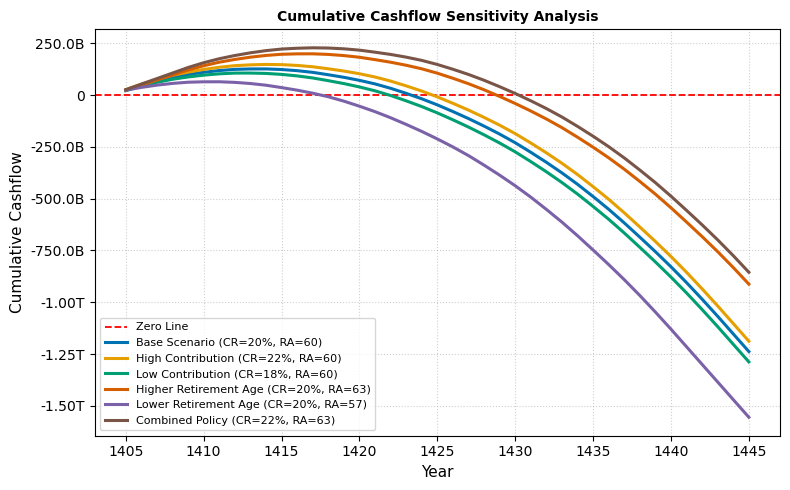

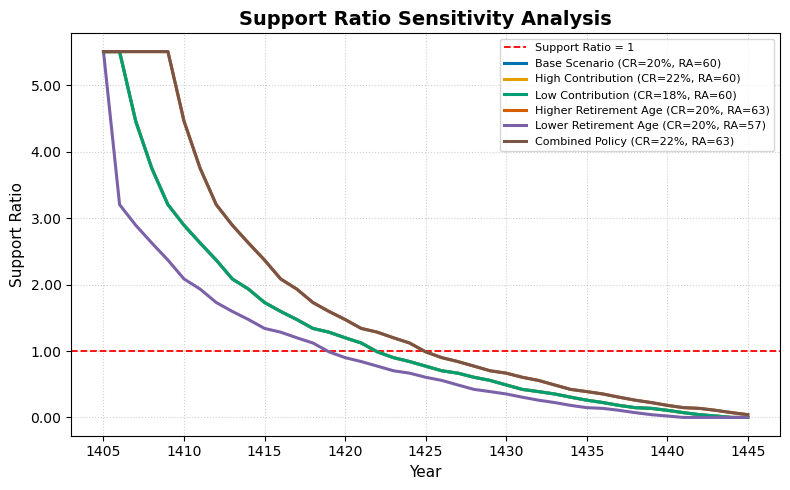


SENSITIVITY ANALYSIS - FINAL SUMMARY
 Rank                              Scenario  Final_Year Final_Support_Ratio Final_Cumulative_Cashflow  First_Deficit_Year
    1       Combined Policy (CR=22%, RA=63)        1445                0.04                   -855.1B                1431
    2 Higher Retirement Age (CR=20%, RA=63)        1445                0.04                   -912.3B                1429
    3     High Contribution (CR=22%, RA=60)        1445                0.00                    -1.19T                1425
    4         Base Scenario (CR=20%, RA=60)        1445                0.00                    -1.24T                1424
    5      Low Contribution (CR=18%, RA=60)        1445                0.00                    -1.29T                1422
    6  Lower Retirement Age (CR=20%, RA=57)        1445                0.00                    -1.56T                1418

FINAL RESULTS BY SCENARIO

Rank: 1
Scenario: Combined Policy (CR=22%, RA=63)
Final Year: 1445
Final Support

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 100,
    "savefig.dpi": 150
})

plt.close("all")

print("Generating sensitivity charts...")


if "sensitivity_results" not in globals():
    raise NameError(
        "sensitivity_results was not found. "
        "Please run sections 8-1, 8-2, 8-3 and 8-4 first."
    )

if not isinstance(sensitivity_results, dict):
    raise TypeError("sensitivity_results must be a dictionary.")

if len(sensitivity_results) == 0:
    raise ValueError("sensitivity_results is empty.")

required_columns = [
    "Year",
    "Cumulative_Cashflow",
    "Support_Ratio"
]

for scenario_name, result_df in sensitivity_results.items():

    if not isinstance(result_df, pd.DataFrame):
        raise TypeError(
            f"Result of scenario '{scenario_name}' is not a DataFrame."
        )

    missing_columns = [
        col for col in required_columns
        if col not in result_df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Scenario '{scenario_name}' is missing columns: "
            f"{missing_columns}"
        )


def large_number_formatter(value, position=None):

    value = float(value)
    abs_value = abs(value)

    if abs_value >= 1e12:
        return f"{value / 1e12:.2f}T"
    elif abs_value >= 1e9:
        return f"{value / 1e9:.1f}B"
    elif abs_value >= 1e6:
        return f"{value / 1e6:.1f}M"
    elif abs_value >= 1e3:
        return f"{value / 1e3:.1f}K"
    else:
        return f"{value:,.0f}"


first_result = next(iter(sensitivity_results.values()))

all_years = (
    pd.to_numeric(first_result["Year"], errors="coerce")
    .dropna()
    .astype(int)
    .to_numpy()
)

if len(all_years) == 0:
    raise ValueError("No valid years were found.")

tick_step = max(1, len(all_years) // 8)
selected_years = all_years[::tick_step]

if selected_years[-1] != all_years[-1]:
    selected_years = np.append(selected_years, all_years[-1])

scenario_colors = [
    "#0072B2",
    "#E69F00",
    "#009E73",
    "#D55E00",
    "#7B61A8",
    "#795548"
]


fig, ax = plt.subplots(figsize=(8, 5))

ax.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1.3,
    label="Zero Line"
)

for i, (scenario_name, result_df) in enumerate(sensitivity_results.items()):

    x = pd.to_numeric(result_df["Year"], errors="coerce")
    y = pd.to_numeric(
        result_df["Cumulative_Cashflow"],
        errors="coerce"
    )

    ax.plot(
        x,
        y,
        color=scenario_colors[i % len(scenario_colors)],
        linewidth=2.2,
        label=scenario_name
    )

ax.set_title(
    "Cumulative Cashflow Sensitivity Analysis",
    fontsize=10,
    fontweight="bold"
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Cumulative Cashflow", fontsize=11)

ax.set_xticks(selected_years)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(large_number_formatter)
)

ax.grid(True, linestyle=":", alpha=0.6)

ax.legend(
    loc="best",
    fontsize=8,
    frameon=True
)

fig.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

ax.axhline(
    y=1,
    color="red",
    linestyle="--",
    linewidth=1.3,
    label="Support Ratio = 1"
)

for i, (scenario_name, result_df) in enumerate(sensitivity_results.items()):

    x = pd.to_numeric(result_df["Year"], errors="coerce")
    y = pd.to_numeric(
        result_df["Support_Ratio"],
        errors="coerce"
    )

    ax.plot(
        x,
        y,
        color=scenario_colors[i % len(scenario_colors)],
        linewidth=2.2,
        label=scenario_name
    )

ax.set_title(
    "Support Ratio Sensitivity Analysis",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Support Ratio", fontsize=11)

ax.set_xticks(selected_years)

ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter("%.2f")
)

ax.grid(True, linestyle=":", alpha=0.6)

ax.legend(
    loc="best",
    fontsize=8,
    frameon=True
)

fig.tight_layout()
plt.show()


summary_rows = []

for scenario_name, result_df in sensitivity_results.items():

    temp = result_df.copy()

    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")

    temp["Cumulative_Cashflow"] = pd.to_numeric(
        temp["Cumulative_Cashflow"],
        errors="coerce"
    )

    temp["Support_Ratio"] = pd.to_numeric(
        temp["Support_Ratio"],
        errors="coerce"
    )

    temp = temp.dropna(
        subset=["Year", "Cumulative_Cashflow"]
    )

    if temp.empty:
        continue

    final_row = temp.iloc[-1]

    deficit_rows = temp.loc[
        temp["Cumulative_Cashflow"] < 0
    ]

    if len(deficit_rows) == 0:
        first_deficit_year = "No Deficit"
    else:
        first_deficit_year = int(deficit_rows.iloc[0]["Year"])

    summary_rows.append({
        "Scenario": scenario_name,
        "Final_Year": int(final_row["Year"]),
        "Final_Support_Ratio": final_row["Support_Ratio"],
        "Final_Cumulative_Cashflow": final_row["Cumulative_Cashflow"],
        "First_Deficit_Year": first_deficit_year
    })

df_chart_summary = pd.DataFrame(summary_rows)

if df_chart_summary.empty:
    raise ValueError("Final summary table is empty.")

df_chart_summary = (
    df_chart_summary
    .sort_values(
        by="Final_Cumulative_Cashflow",
        ascending=False
    )
    .reset_index(drop=True)
)

df_chart_summary.insert(
    0,
    "Rank",
    range(1, len(df_chart_summary) + 1)
)


print("\n" + "=" * 110)
print("SENSITIVITY ANALYSIS - FINAL SUMMARY")
print("=" * 110)

summary_for_print = df_chart_summary.copy()

summary_for_print["Final_Support_Ratio"] = (
    summary_for_print["Final_Support_Ratio"]
    .map(lambda x: "N/A" if pd.isna(x) else f"{x:.2f}")
)

summary_for_print["Final_Cumulative_Cashflow"] = (
    summary_for_print["Final_Cumulative_Cashflow"]
    .map(large_number_formatter)
)

print(summary_for_print.to_string(index=False))


print("\n" + "=" * 110)
print("FINAL RESULTS BY SCENARIO")
print("=" * 110)

for _, row in df_chart_summary.iterrows():

    support_ratio = row["Final_Support_Ratio"]

    if pd.isna(support_ratio):
        support_text = "N/A"
    else:
        support_text = f"{support_ratio:.2f}"

    cashflow_text = large_number_formatter(
        row["Final_Cumulative_Cashflow"]
    )

    print(
        f"\nRank: {int(row['Rank'])}"
        f"\nScenario: {row['Scenario']}"
        f"\nFinal Year: {int(row['Final_Year'])}"
        f"\nFinal Support Ratio: {support_text}"
        f"\nFinal Cumulative Cashflow: {cashflow_text}"
        f"\nFirst Deficit Year: {row['First_Deficit_Year']}"
    )

print("\n" + "=" * 110)
print("Section 8-5 completed successfully.")
print("=" * 110)


## ۸-۵. تحلیل حساسیت جریان نقدی تجمعی

در این بخش، جریان نقدی تجمعی صندوق تحت شش سناریوی مختلف از سال `1405` تا `1445` بررسی شد. خط قرمز در نمودار نشان‌دهنده جریان نقدی تجمعی صفر است. در همه سناریوها، جریان نقدی تجمعی در سال‌های ابتدایی افزایش یافت، اما پس از رسیدن به مقدار اوج، روند آن نزولی شد و در ادامه افق پیش‌بینی به مقادیر منفی رسید.

## روند جریان نقدی تجمعی

بر اساس نمودار، سناریوی سیاست ترکیبی با `CR=22%` و `RA=63` بهترین روند جریان نقدی تجمعی را دارد. این سناریو در بیشتر سال‌های پیش‌بینی بالاتر از سایر سناریوها قرار گرفته و در پایان سال `1445` کمترین کسری تجمعی را ثبت کرده است. سناریوی افزایش سن بازنشستگی با `CR=20%` و `RA=63` نیز عملکرد مناسبی دارد و پس از سیاست ترکیبی در جایگاه دوم قرار می‌گیرد.

## مقایسه نرخ‌های مختلف حق‌بیمه

افزایش نرخ حق‌بیمه از `20%` به `22%` در سن بازنشستگی `60` سال باعث بهبود جریان نقدی تجمعی شد. در سناریوی نرخ حق‌بیمه بالا، جریان نقدی تجمعی نهایی حدود `-1.19T` بود، در حالی که این مقدار در سناریوی پایه حدود `-1.24T` و در سناریوی نرخ حق‌بیمه پایین حدود `-1.29T` ثبت شد.

بنابراین، افزایش نرخ حق‌بیمه اثر مثبت دارد، اما به‌تنهایی برای جلوگیری از کسری تجمعی در پایان افق پیش‌بینی کافی نیست.

## مقایسه سن بازنشستگی

تغییر سن بازنشستگی اثر قابل‌توجهی بر جریان نقدی صندوق دارد. افزایش سن بازنشستگی از `60` به `63` سال، با کاهش تعداد سال‌های دریافت مستمری و ادامه دریافت حق‌بیمه از اعضای فعال، باعث بهبود وضعیت جریان نقدی شد. در مقابل، کاهش سن بازنشستگی به `57` سال موجب افزایش سریع‌تر تعهدات و افت شدیدتر جریان نقدی تجمعی گردید.

## بدترین روند جریان نقدی

سناریوی کاهش سن بازنشستگی با `CR=20%` و `RA=57` ضعیف‌ترین روند را در نمودار نشان می‌دهد. این سناریو زودتر از سایر سناریوها وارد محدوده منفی شد و در پایان سال `1445` جریان نقدی تجمعی آن حدود `-1.56T` بود. بنابراین، کاهش سن بازنشستگی فشار بیشتری بر منابع صندوق وارد می‌کند.

## تحلیل حساسیت نسبت پشتیبانی

نمودار نسبت پشتیبانی، روند تعداد اعضای فعال نسبت به تعداد مستمری‌بگیران را در طول افق پیش‌بینی نشان می‌دهد. خط قرمز افقی برابر `1` است و نشان می‌دهد که به ازای هر مستمری‌بگیر، فقط یک عضو فعال وجود دارد. کاهش نسبت پشتیبانی به کمتر از `1` بیانگر کاهش توان جمعیت فعال برای تأمین مالی مستمری‌بگیران است.

## روند نسبت پشتیبانی

در ابتدای دوره، نسبت پشتیبانی در برخی سناریوها بیش از `5` بود، اما در طول زمان به‌طور پیوسته کاهش یافت. این کاهش ناشی از افزایش تعداد بازنشستگان و مستمری‌بگیران، خروج اعضای فعال و محدود بودن تعداد اعضای جدید نسبت به رشد تعهدات صندوق است.

در پایان سال `1445`، نسبت پشتیبانی سناریوهای مختلف تقریباً به صفر رسید؛ بنابراین در انتهای افق پیش‌بینی، تعداد اعضای فعال نسبت به مستمری‌بگیران بسیار پایین است.

## عبور نسبت پشتیبانی از سطح بحرانی

بر اساس نمودار، سناریوی کاهش سن بازنشستگی با `RA=57` زودتر از سایر سناریوها به نسبت پشتیبانی کمتر از `1` رسید. این نتیجه نشان می‌دهد که بازنشستگی زودتر، تعداد مستمری‌بگیران را سریع‌تر افزایش داده و پایه جمعیتی تأمین‌کننده حق‌بیمه را تضعیف می‌کند.

سناریوهای دارای سن بازنشستگی `63` سال، به‌ویژه سیاست ترکیبی، نسبت پشتیبانی بالاتری را برای مدت طولانی‌تری حفظ کردند.

## اثر سیاست ترکیبی بر نسبت پشتیبانی

سیاست ترکیبی با نرخ حق‌بیمه `22%` و سن بازنشستگی `63` سال، در مقایسه با سایر سناریوها بهترین وضعیت نسبت پشتیبانی را نشان داد. این سناریو در بیشتر سال‌های پیش‌بینی بالاتر از خط بحرانی `Support Ratio = 1` باقی ماند و در پایان سال `1445` نسبت پشتیبانی آن برابر `0.04` بود.

## نتایج نهایی رتبه‌بندی سناریوها

سناریوها بر اساس جریان نقدی تجمعی نهایی به ترتیب زیر رتبه‌بندی شدند:

`Rank 1`: سیاست ترکیبی، `CR=22%` و `RA=63`، جریان نقدی تجمعی نهایی حدود `-855.1B` و اولین کسری در سال `1431`.

`Rank 2`: سن بازنشستگی بالاتر، `CR=20%` و `RA=63`، جریان نقدی تجمعی نهایی حدود `-912.3B` و اولین کسری در سال `1429`.

`Rank 3`: نرخ حق‌بیمه بالا، `CR=22%` و `RA=60`، جریان نقدی تجمعی نهایی حدود `-1.19T` و اولین کسری در سال `1425`.

`Rank 4`: سناریوی پایه، `CR=20%` و `RA=60`، جریان نقدی تجمعی نهایی حدود `-1.24T` و اولین کسری در سال `1424`.

`Rank 5`: نرخ حق‌بیمه پایین، `CR=18%` و `RA=60`، جریان نقدی تجمعی نهایی حدود `-1.29T` و اولین کسری در سال `1422`.

`Rank 6`: سن بازنشستگی پایین‌تر، `CR=20%` و `RA=57`، جریان نقدی تجمعی نهایی حدود `-1.56T` و اولین کسری در سال `1418`.

## نتایج نهایی سیاست ترکیبی

سناریوی سیاست ترکیبی با `CR=22%` و `RA=63` در رتبه اول قرار گرفت. مقدار جریان نقدی تجمعی نهایی آن حدود `-855.1B`، نسبت پشتیبانی نهایی `0.04` و اولین سال کسری آن `1431` بود. با وجود اینکه این سناریو نیز در پایان دوره کسری دارد، نسبت به سناریوی پایه وضعیت بهتری ایجاد کرده و شروع کسری را به تأخیر انداخته است.

## نتایج نهایی افزایش سن بازنشستگی

سناریوی افزایش سن بازنشستگی به `63` سال با نرخ حق‌بیمه `20%` در رتبه دوم قرار گرفت. جریان نقدی تجمعی نهایی آن حدود `-912.3B` و نسبت پشتیبانی نهایی آن `0.04` بود. اولین کسری این سناریو در سال `1429` مشاهده شد که نسبت به سناریوی پایه، `5` سال دیرتر است.

## نتایج نهایی نرخ حق‌بیمه بالا

در سناریوی نرخ حق‌بیمه بالا، نرخ حق‌بیمه از `20%` به `22%` افزایش یافت و سن بازنشستگی برابر `60` سال باقی ماند. جریان نقدی تجمعی نهایی این سناریو حدود `-1.19T` و نسبت پشتیبانی نهایی آن `0.00` بود. اولین کسری در سال `1425` رخ داد؛ بنابراین افزایش نرخ حق‌بیمه موجب بهبود نسبی شد، اما اثر آن کمتر از افزایش سن بازنشستگی بود.

## نتایج نهایی نرخ حق‌بیمه پایین

در سناریوی نرخ حق‌بیمه پایین، نرخ حق‌بیمه به `18%` کاهش یافت و سن بازنشستگی برابر `60` سال باقی ماند. جریان نقدی تجمعی نهایی حدود `-1.29T`، نسبت پشتیبانی نهایی `0.00` و اولین کسری سالانه در سال `1422` بود. کاهش نرخ حق‌بیمه موجب تشدید کسری و کاهش پایداری مالی صندوق شد.

## نتایج نهایی کاهش سن بازنشستگی

در سناریوی کاهش سن بازنشستگی به `57` سال، جریان نقدی تجمعی نهایی حدود `-1.56T` بود که بدترین نتیجه میان سناریوهای بررسی‌شده محسوب می‌شود. نسبت پشتیبانی نهایی `0.00` و اولین کسری سالانه در سال `1418` ثبت شد. این سناریو همچنین در سال `1418` وارد وضعیت فروپاشی جریان نقدی تجمعی شد.

## جمع‌بندی بخش ۸-۵

نتایج نمودارها و خروجی نهایی نشان می‌دهد که هر شش سناریو در پایان سال `1445` با کسری تجمعی مواجه هستند. بهترین عملکرد مربوط به سیاست ترکیبی با `CR=22%` و `RA=63` و ضعیف‌ترین عملکرد مربوط به کاهش سن بازنشستگی به `57` سال است. افزایش سن بازنشستگی اثر بیشتری نسبت به افزایش صرف نرخ حق‌بیمه دارد، زیرا هم زمان ورود اعضا به دوره دریافت مستمری را کاهش می‌دهد و هم مدت پرداخت حق‌بیمه را افزایش می‌دهد. با این حال، حتی بهترین سناریو نیز به‌تنهایی برای تضمین پایداری بلندمدت صندوق کافی نیست.


---
# بخش ۹: ارزیابی پایداری مالی و جمعیتی مدل PAYG-DB

در این بخش، پایداری بلندمدت صندوق بر اساس نتایج شش سناریوی بخش ۸ ارزیابی می‌شود. معیارهای اصلی شامل سال اولین کسری، سال ورود جریان نقدی تجمعی به محدوده منفی، جریان نقدی تجمعی نهایی و نسبت پشتیبانی نهایی هستند.


In [24]:
# 9-1 | کنترل ساختار خروجی تحلیل حساسیت بخش 8

print("Columns of df_sensitivity_summary:")
print(df_sensitivity_summary.columns.tolist())

print("\nShape of df_sensitivity_summary:")
print(df_sensitivity_summary.shape)

display(df_sensitivity_summary.head())


Columns of df_sensitivity_summary:
['Scenario Name', 'CR', 'RA', 'Support Ratio (End)', 'Annual Deficit Year', 'Collapse Year (Cum. CF < 0)', 'Cumulative Cashflow (End)']

Shape of df_sensitivity_summary:
(6, 7)


,Scenario Name,CR,RA,Support Ratio (End),Annual Deficit Year,Collapse Year (Cum. CF < 0),Cumulative Cashflow (End)
0,"Base Scenario (CR=20%, RA=60)",20.0%,60,0.00,1415,1424,"-1,238,004,394,587.10"
1,"High Contribution (CR=22%, RA=60)",22.0%,60,0.00,1415,1425,"-1,187,998,003,433.08"
2,"Low Contribution (CR=18%, RA=60)",18.0%,60,0.00,1414,1422,"-1,288,010,785,741.12"
3,"Higher Retirement Age (CR=20%, RA=63)",20.0%,63,0.04,1418,1429,"-912,328,180,890.40"
4,"Lower Retirement Age (CR=20%, RA=57)",20.0%,57,0.00,1412,1418,"-1,555,320,923,597.80"


In [25]:
# 9-2 | ساخت جدول ارزیابی پایداری مدل PAYG-DB

df_sustainability = df_sensitivity_summary.copy()

# تابع تعیین وضعیت پایداری
def evaluate_sustainability(row):
    cum_cf = row['Cumulative Cashflow (End)']
    supp_ratio = row['Support Ratio (End)']
    collapse_year = row['Collapse Year (Cum. CF < 0)']
    
    if cum_cf >= 0 and supp_ratio >= 1.0:
        return 'پایدار'
    elif collapse_year > 1430:
        return 'در معرض ریسک'
    else:
        return 'ناپایدار'

# اعمال وضعیت پایداری
df_sustainability['Sustainability Status'] = df_sustainability.apply(evaluate_sustainability, axis=1)

# مرتب‌سازی بر اساس سال فروپاشی و جریان نقدی تجمعی
df_sustainability = df_sustainability.sort_values(
    by=['Collapse Year (Cum. CF < 0)', 'Cumulative Cashflow (End)'], 
    ascending=[False, False]
).reset_index(drop=True)

# رتبه‌بندی پایداری
df_sustainability['Sustainability Rank'] = df_sustainability.index + 1

# نمایش جدول
cols_order = [
    'Sustainability Rank', 'Scenario Name', 'CR', 'RA', 
    'Annual Deficit Year', 'Collapse Year (Cum. CF < 0)', 
    'Support Ratio (End)', 'Cumulative Cashflow (End)', 'Sustainability Status'
]

df_sustainability_display = df_sustainability[cols_order].copy()

# فرمت‌دهی نمایش جریان نقدی
df_sustainability_display['Cumulative Cashflow (End)'] = df_sustainability_display['Cumulative Cashflow (End)'].map('{:,.2f}'.format)

display(df_sustainability_display)


,Sustainability Rank,Scenario Name,CR,RA,Annual Deficit Year,Collapse Year (Cum. CF < 0),Support Ratio (End),Cumulative Cashflow (End),Sustainability Status
0,1,"Combined Policy (CR=22%, RA=63)",22.0%,63,1418,1431,0.04,"-855,084,540,543.12",در معرض ریسک
1,2,"Higher Retirement Age (CR=20%, RA=63)",20.0%,63,1418,1429,0.04,"-912,328,180,890.40",ناپایدار
2,3,"High Contribution (CR=22%, RA=60)",22.0%,60,1415,1425,0.00,"-1,187,998,003,433.08",ناپایدار
3,4,"Base Scenario (CR=20%, RA=60)",20.0%,60,1415,1424,0.00,"-1,238,004,394,587.10",ناپایدار
4,5,"Low Contribution (CR=18%, RA=60)",18.0%,60,1414,1422,0.00,"-1,288,010,785,741.12",ناپایدار
5,6,"Lower Retirement Age (CR=20%, RA=57)",20.0%,57,1412,1418,0.00,"-1,555,320,923,597.80",ناپایدار


## ۹-۲. جدول ارزیابی پایداری مالی مدل PAYG-DB

نتایج نشان می‌دهد هیچ‌یک از شش سناریو در افق پیش‌بینی به وضعیت «پایدار» نمی‌رسند؛ زیرا جریان نقدی تجمعی نهایی همه سناریوها منفی است. سیاست ترکیبی با `CR=22%` و `RA=63` بهترین رتبه پایداری را دارد و با سال فروپاشی `1431` و کسری تجمعی نهایی `855,084,540,543-` در وضعیت «در معرض ریسک» قرار گرفته است. سناریوی افزایش سن بازنشستگی به `63` سال نیز نسبت به افزایش صرف نرخ حق‌بیمه عملکرد بهتری دارد. ضعیف‌ترین وضعیت مربوط به کاهش سن بازنشستگی به `57` سال است که در سال `1418` دچار فروپاشی تجمعی می‌شود.


---
# 9-3 | تحلیل سال‌های پایداری و شاخص کفایت تأمین مالی (FAI)


In [26]:
# 9-3 | تحلیل سال‌های پایداری و شاخص کفایت تأمین مالی (FAI)

# تعریف سال شروع پروژه
start_year = 1405
end_year = 1445
total_years = end_year - start_year + 1

# محاسبه شاخص‌های تکمیلی
df_sustainability['Solvent Years'] = df_sustainability['Collapse Year (Cum. CF < 0)'] - start_year
df_sustainability['Solvency Ratio (%)'] = (df_sustainability['Solvent Years'] / total_years) * 100

# شاخص کفایت تأمین مالی (نسبت مجموع درآمد به مجموع هزینه در طول دوره)
# این شاخص نشان می‌دهد سیستم چند درصد از تعهداتش را می‌تواند از محل منابع داخلی پوشش دهد
def calculate_fai(scenario_name):
    res = sensitivity_results[scenario_name]
    total_revenue = (res['Total_Salary'] * res['Support_Ratio'] * (res['Total_Salary'] != 0)).sum() # تقریبی از حق‌بیمه
    # اصلاح: چون حق‌بیمه دقیق در خروجی نیست، از نسبت جریان نقدی استفاده می‌کنیم
    # روش ساده‌تر برای FAI در این مدل:
    # FAI = 1 + (Cumulative_Cashflow_End / Total_Pensions_End_Sum)
    total_pensions = res['Total_Pension'].sum()
    final_cum_cf = res['Cumulative_Cashflow'].iloc[-1]
    fai = 1 + (final_cum_cf / total_pensions)
    return max(0, fai)

df_sustainability['Funding Adequacy Index (FAI)'] = df_sustainability['Scenario Name'].apply(calculate_fai)

# آماده‌سازی برای نمایش
df_sustainability_metrics = df_sustainability[[
    'Sustainability Rank', 'Scenario Name', 'Solvent Years', 
    'Solvency Ratio (%)', 'Funding Adequacy Index (FAI)', 'Sustainability Status'
]].copy()

# فرمت‌دهی
df_sustainability_metrics['Solvency Ratio (%)'] = df_sustainability_metrics['Solvency Ratio (%)'].map('{:.1f}%'.format)
df_sustainability_metrics['Funding Adequacy Index (FAI)'] = df_sustainability_metrics['Funding Adequacy Index (FAI)'].map('{:.2f}'.format)

display(df_sustainability_metrics)


,Sustainability Rank,Scenario Name,Solvent Years,Solvency Ratio (%),Funding Adequacy Index (FAI),Sustainability Status
0,1,"Combined Policy (CR=22%, RA=63)",26,63.4%,0.42,در معرض ریسک
1,2,"Higher Retirement Age (CR=20%, RA=63)",24,58.5%,0.39,ناپایدار
2,3,"High Contribution (CR=22%, RA=60)",20,48.8%,0.32,ناپایدار
3,4,"Base Scenario (CR=20%, RA=60)",19,46.3%,0.29,ناپایدار
4,5,"Low Contribution (CR=18%, RA=60)",17,41.5%,0.26,ناپایدار
5,6,"Lower Retirement Age (CR=20%, RA=57)",13,31.7%,0.22,ناپایدار


## ۹-۳. سنجه‌های پایداری (Solvent Years، Solvency Ratio، `FAI`)

بر اساس خروجی `df_sustainability_metrics`، بهترین عملکرد مربوط به سیاست ترکیبی `CR=22%` و `RA=63` است که `26` سال پایداری (تا قبل از ورود به کسری تجمعی) معادل `63.4%` از افق را نشان می‌دهد و `FAI=0.42` دارد؛ با این حال همچنان «در معرض ریسک» است و به پایداری کامل نمی‌رسد. سناریوی افزایش سن بازنشستگی (`RA=63` با `CR=20%`) در رتبه بعدی قرار دارد (`24` سال، `58.5%`، `FAI=0.39`). در سناریوهای با `RA=60`، افزایش نرخ حق‌بیمه به `22%` نسبت به پایه بهتر است (`20` سال، `48.8%`، `FAI=0.32`) و سناریوی پایه (`19` سال، `46.3%`، `FAI=0.29`) و نرخ پایین (`17` سال، `41.5%`، `FAI=0.26`) عقب‌تر هستند. ضعیف‌ترین سناریو کاهش سن بازنشستگی به `57` سال است که فقط `13` سال پایداری (`31.7%`) و کمترین کفایت تأمین مالی (`FAI=0.22`) را ثبت می‌کند؛ یعنی حدود 78% تعهدات دوره بدون منبع داخلی باقی می‌ماند.


---
# 9-4 | مقایسه بصری شاخص‌های پایداری مدل PAYG-DB

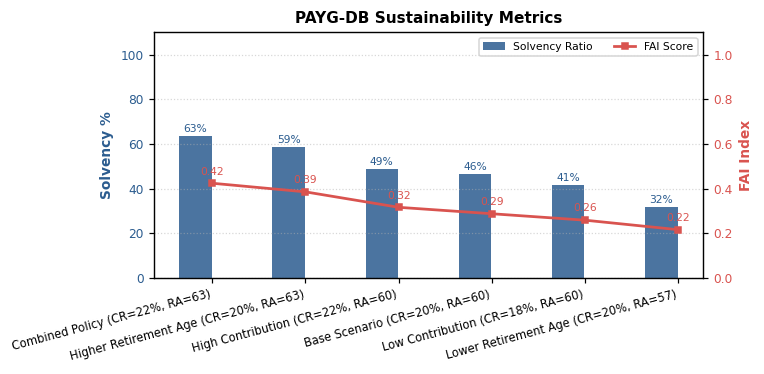

In [27]:
# 9-4 |
import matplotlib.pyplot as plt

plt.style.use('default')

scenarios = df_sustainability['Scenario Name'].tolist()
solvency_ratios = [float(str(x).replace('%', '')) for x in df_sustainability['Solvency Ratio (%)']]
fai_scores = [float(x) for x in df_sustainability['Funding Adequacy Index (FAI)']]

x = list(range(len(scenarios)))


fig, ax1 = plt.subplots(figsize=(7, 3.5), dpi=110)

color1 = '#2b5c8f'
bars = ax1.bar([i - 0.18 for i in x], solvency_ratios, width=0.35, color=color1, alpha=0.85, label='Solvency Ratio')

ax1.set_ylabel('Solvency %', color=color1, fontsize=9, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1, labelsize=8)
ax1.set_ylim(0, 110) 
ax1.grid(axis='y', linestyle=':', alpha=0.5)

ax2 = ax1.twinx()
color2 = '#d9534f'
ax2.plot(x, fai_scores, color=color2, marker='s', linewidth=1.8, markersize=4, label='FAI Score')

ax2.set_ylabel('FAI Index', color=color2, fontsize=9, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2, labelsize=8)
ax2.set_ylim(0, 1.1)

ax1.set_xticks(x)
ax1.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=7.5)


for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1, '{:.0f}%'.format(height), 
             ha='center', va='bottom', fontsize=7, color=color1)

for i, val in enumerate(fai_scores):
    ax2.text(i, val + 0.03, '{:.2f}'.format(val), 
             ha='center', va='bottom', fontsize=7, color=color2)

ax1.set_title('PAYG-DB Sustainability Metrics', fontsize=10, fontweight='bold')

# راهنمای کوچک در گوشه
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right', fontsize=7, frameon=True, ncol=2)

fig.tight_layout()
plt.show()


### 9-4 | مقایسه بصری شاخص‌های پایداری مدل PAYG-DB

نمودار، نسبت دوام‌پذیری و شاخص کفایت تأمین مالی را برای شش سناریوی مدل `PAYG-DB` مقایسه می‌کند. روند دو شاخص کاملاً هم‌جهت است؛ بنابراین سناریوهایی که سال‌های بیشتری تا فروپاشی نقدینگی دوام دارند، کسری نهایی کمتری نیز نسبت به تعهدات مستمری دارند.

سناریوی `Combined Policy` با نرخ حق‌بیمه `22%` و سن بازنشستگی `63`، بهترین نتیجه را با نسبت دوام‌پذیری `63.4%` و `FAI = 0.42` دارد. سناریوی `Higher Retirement Age` با نسبت `58.5%` و `FAI = 0.39` در رتبه دوم قرار گرفته است. در مقابل، سناریوی `Lower Retirement Age` با نسبت دوام‌پذیری `31.7%` و `FAI = 0.22` ضعیف‌ترین وضعیت را نشان می‌دهد.

نتایج نمودار تأیید می‌کند افزایش سن بازنشستگی، به‌ویژه در ترکیب با افزایش نرخ حق‌بیمه، مؤثرترین اصلاح پارامتریک در مدل `PAYG-DB` است. با وجود این، مقدار نسبت پشتیبانی نهایی در همه سناریوها کمتر از یک و جریان نقدی تجمعی نهایی منفی است؛ بنابراین هیچ‌یک از سناریوها پایداری مالی کامل بلندمدت صندوق را تضمین نمی‌کنند.


---
# 9-5 | جمع‌بندی سیاستی ارزیابی پایداری مدل PAYG-DB

In [28]:
# 9-5 | جمع‌بندی سیاستی ارزیابی پایداری مدل PAYG-DB

df_policy_conclusion = df_sustainability[
    [
        'Sustainability Rank',
        'Scenario Name',
        'CR',
        'RA',
        'Collapse Year (Cum. CF < 0)',
        'Solvency Ratio (%)',
        'Funding Adequacy Index (FAI)',
        'Sustainability Status'
    ]
].copy()

# تعریف توصیه سیاستی برای هر سناریو
def policy_recommendation(scenario_name):
    
    if scenario_name == 'Combined Policy':
        return 'بهترین اصلاح پارامتریک؛ نیازمند اصلاحات تکمیلی برای پایداری کامل'
    
    elif scenario_name == 'Higher Retirement Age':
        return 'اصلاح مؤثر؛ افزایش سن بازنشستگی توصیه می‌شود'
    
    elif scenario_name == 'High Contribution':
        return 'اثر محدود؛ افزایش نرخ حق‌بیمه به تنهایی کافی نیست'
    
    elif scenario_name == 'Base Scenario':
        return 'تداوم وضعیت موجود توصیه نمی‌شود'
    
    elif scenario_name == 'Low Contribution':
        return 'نامطلوب؛ کاهش نرخ حق‌بیمه ریسک کسری را افزایش می‌دهد'
    
    elif scenario_name == 'Lower Retirement Age':
        return 'نامطلوب‌ترین گزینه؛ باید اجتناب شود'
    
    else:
        return 'نیازمند بررسی بیشتر'

df_policy_conclusion['Policy Recommendation'] = (
    df_policy_conclusion['Scenario Name'].apply(policy_recommendation)
)

# مرتب‌سازی بر اساس رتبه پایداری
df_policy_conclusion = df_policy_conclusion.sort_values(
    by='Sustainability Rank'
).reset_index(drop=True)

# نمایش جدول نهایی
display(df_policy_conclusion)


,Sustainability Rank,Scenario Name,CR,RA,Collapse Year (Cum. CF < 0),Solvency Ratio (%),Funding Adequacy Index (FAI),Sustainability Status,Policy Recommendation
0,1,"Combined Policy (CR=22%, RA=63)",22.0%,63,1431,63.41,0.42,در معرض ریسک,نیازمند بررسی بیشتر
1,2,"Higher Retirement Age (CR=20%, RA=63)",20.0%,63,1429,58.54,0.39,ناپایدار,نیازمند بررسی بیشتر
2,3,"High Contribution (CR=22%, RA=60)",22.0%,60,1425,48.78,0.32,ناپایدار,نیازمند بررسی بیشتر
3,4,"Base Scenario (CR=20%, RA=60)",20.0%,60,1424,46.34,0.29,ناپایدار,نیازمند بررسی بیشتر
4,5,"Low Contribution (CR=18%, RA=60)",18.0%,60,1422,41.46,0.26,ناپایدار,نیازمند بررسی بیشتر
5,6,"Lower Retirement Age (CR=20%, RA=57)",20.0%,57,1418,31.71,0.22,ناپایدار,نیازمند بررسی بیشتر


### ۹-۵ | جمع‌بندی سیاستی ارزیابی پایداری مدل PAYG-DB

نتایج نهایی ارزیابی پایداری نشان می‌دهد که تمامی سناریوهای پارامتریک در بلندمدت با کسری تجمعی مواجه می‌شوند. سناریوی اصلاحات همزمان (Combined Policy) با کسب بالاترین شاخص کفایت تأمین مالی (FAI = 0.42) و به تعویق انداختن فروپاشی تا سال ۱۴۳۱، بهترین عملکرد را در میان گزینه‌های موجود دارد. در مقابل، سناریوی کاهش سن بازنشستگی (Lower Retirement Age) با کمترین نسبت دوام‌پذیری (31.7%)، بحران نقدینگی را به سال ۱۴۱۸ جلو می‌اندازد. بر اساس رتبه‌بندی پایداری، اعمال اصلاحات ترکیبی (افزایش نرخ حق‌بیمه و سن بازنشستگی) به عنوان موثرترین استراتژی میان‌مدت توصیه می‌شود، هرچند برای پایداری کامل بعد از سال ۱۴۳۱، نیاز به بازنگری در ساختار هزینه‌ها و منابع درآمدی صندوق مشهود است.
1

---
# 9-6 | تحلیل شکاف و نتیجه‌گیری نهایی بخش پایداری (Sustainability Gap Analysis)

In [29]:
# 9-6 | تحلیل شکاف و نتیجه‌گیری نهایی بخش پایداری (Sustainability Gap Analysis)

# محاسبه شکاف زمانی تا افق 1445 در بهترین سناریو
best_collapse = df_policy_conclusion.iloc[0]['Collapse Year (Cum. CF < 0)']
planning_horizon = 1445
sustainability_gap = planning_horizon - best_collapse

print(f"--- تحلیل نهایی پایداری مدل PAYG-DB ---")
print(f"افق زمانی پیش‌بینی: 1445")
print(f"سال فروپاشی در بهترین سناریو (Combined): {best_collapse}")
print(f"شکاف پایداری (Sustainability Gap): {sustainability_gap} سال")

# یادداشت نهایی برای گزارش
conclusion_note = """
نتیجه‌گیری راهبردی:
حتی با اعمال سخت‌گیرانه‌ترین اصلاحات پارامتریک (سن 63 و نرخ 22%)، 
صندوق بازنشستگی با شکاف پایداری 14 ساله تا افق 1445 مواجه است. 
این موضوع نشان‌دهنده 'بحران ساختاری' در مدل PAYG است که صرفاً با 
تغییر متغیرهای سن و نرخ حق‌بیمه درمان نمی‌شود.
"""
print(conclusion_note)


--- تحلیل نهایی پایداری مدل PAYG-DB ---
افق زمانی پیش‌بینی: 1445
سال فروپاشی در بهترین سناریو (Combined): 1431
شکاف پایداری (Sustainability Gap): 14 سال

نتیجه‌گیری راهبردی:
حتی با اعمال سخت‌گیرانه‌ترین اصلاحات پارامتریک (سن 63 و نرخ 22%)، 
صندوق بازنشستگی با شکاف پایداری 14 ساله تا افق 1445 مواجه است. 
این موضوع نشان‌دهنده 'بحران ساختاری' در مدل PAYG است که صرفاً با 
تغییر متغیرهای سن و نرخ حق‌بیمه درمان نمی‌شود.



## ۹-۶ | تحلیل شکاف پایداری (Sustainability Gap Analysis)

در این بخش، تحلیل شکاف پایداری (Sustainability Gap) جهت ارزیابی فاصله بین وضعیت موجود و افق برنامه‌ریزی ۱۴۴۵ انجام شد. نتایج نشان می‌دهد که در بهترین سناریوی پارامتریک (Combined Policy)، سال فروپاشی نقدینگی صندوق ۱۴۳۱ است که با افق برنامه‌ریزی، شکافی ۱۴ ساله را نشان می‌دهد. این تحلیل حاکی از وجود یک «بحران ساختاری» در مدل PAYG-DB است؛ بدین معنا که اصلاحات پارامتریک (تغییر نرخ حق‌بیمه و سن بازنشستگی) علیرغم بهبود نسبی شاخص‌ها، برای تضمین پایداری بلندمدت صندوق کافی نیستند و راهکارهای ساختاری عمیق‌تری برای برون‌رفت از این شکاف مورد نیاز است.


---
## بخش ۱۰: تحلیل نسبت پشتیبانی صندوق بازنشستگی

In [30]:


import pandas as pd

# نام فایل و شیت
file_path = "دیتای نهایی.xlsx"
sheet_name = "PAYG_DB_Model"

# خواندن داده‌ها
df_members = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=14
)

# پاک‌سازی نام ستون‌ها و وضعیت اعضا
df_members.columns = df_members.columns.astype(str).str.strip()
df_members["Status"] = df_members["Status"].astype(str).str.strip()

# تفکیک اعضا
active_members = df_members[df_members["Status"] == "Active"].copy()
retired_members = df_members[df_members["Status"] == "Retired"].copy()
survivor_members = df_members[df_members["Status"] == "Survivor"].copy()

# تبدیل ستون حقوق به عددی
df_members["Current_Annual_Salary"] = pd.to_numeric(
    df_members["Current_Annual_Salary"],
    errors="coerce"
).fillna(0)

active_members["Current_Annual_Salary"] = pd.to_numeric(
    active_members["Current_Annual_Salary"],
    errors="coerce"
).fillna(0)

retired_members["Current_Annual_Salary"] = pd.to_numeric(
    retired_members["Current_Annual_Salary"],
    errors="coerce"
).fillna(0)

survivor_members["Current_Annual_Salary"] = pd.to_numeric(
    survivor_members["Current_Annual_Salary"],
    errors="coerce"
).fillna(0)

# تعداد اعضا
active_count = len(active_members)
retired_count = len(retired_members)
survivor_count = len(survivor_members)

# پایه حقوق سالانه اعضای فعال
active_wage_base = active_members["Current_Annual_Salary"].sum()

# هزینه مستمری سالانه بازنشستگان و بازماندگان
retired_pension_expense = retired_members["Current_Annual_Salary"].sum()
survivor_pension_expense = survivor_members["Current_Annual_Salary"].sum()

total_pension_expense = (
    retired_pension_expense
    + survivor_pension_expense
)

# نرخ حق‌بیمه فعلی: 9 درصد کارمند + 9 درصد کارفرما
employee_contribution_rate = 0.09
employer_contribution_rate = 0.09

current_contribution_rate = (
    employee_contribution_rate
    + employer_contribution_rate
)

# درآمد حق‌بیمه سال پایه
contribution_income = (
    active_wage_base
    * current_contribution_rate
)

# نرخ حق‌بیمه سربه‌سر
break_even_rate = (
    total_pension_expense
    / active_wage_base
)

# شکاف نرخ و کسری نقدی
rate_gap = (
    break_even_rate
    - current_contribution_rate
)

cash_deficit = (
    total_pension_expense
    - contribution_income
)



print("=" * 65)
print("بخش 10-1 | تحلیل نرخ حق‌بیمه سربه‌سر")
print("=" * 65)

print(f"تعداد کل اعضا: {active_count + retired_count + survivor_count:,} نفر")
print(f"تعداد اعضای فعال: {active_count:,} نفر")
print(f"تعداد بازنشستگان: {retired_count:,} نفر")
print(f"تعداد بازماندگان: {survivor_count:,} نفر")

print("-" * 65)

print(f"پایه حقوق سالانه فعالان: {active_wage_base:,.0f} ریال")
print(f"هزینه مستمری بازنشستگان: {retired_pension_expense:,.0f} ریال")
print(f"هزینه مستمری بازماندگان: {survivor_pension_expense:,.0f} ریال")
print(f"کل هزینه مستمری سالانه: {total_pension_expense:,.0f} ریال")

print("-" * 65)

print(f"نرخ حق‌بیمه کارمند: {employee_contribution_rate:.2%}")
print(f"نرخ حق‌بیمه کارفرما: {employer_contribution_rate:.2%}")
print(f"نرخ حق‌بیمه فعلی: {current_contribution_rate:.2%}")
print(f"درآمد حق‌بیمه سالانه: {contribution_income:,.0f} ریال")

print("-" * 65)

print(f"نرخ حق‌بیمه سربه‌سر: {break_even_rate:.2%}")
print(f"شکاف نرخ حق‌بیمه: {rate_gap:.2%}")
print(f"کسری نقدی سال پایه: {cash_deficit:,.0f} ریال")

print("-" * 65)

if cash_deficit > 0:
    print("نتیجه: صندوق در سال پایه با کسری نقدی مواجه است.")
    print(
        f"برای پوشش هزینه مستمری، نرخ حق‌بیمه باید از "
        f"{current_contribution_rate:.2%} به "
        f"{break_even_rate:.2%} برسد."
    )
else:
    print("نتیجه: درآمد حق‌بیمه سال پایه برای پوشش هزینه‌ها کافی است.")


بخش 10-1 | تحلیل نرخ حق‌بیمه سربه‌سر
تعداد کل اعضا: 500 نفر
تعداد اعضای فعال: 402 نفر
تعداد بازنشستگان: 73 نفر
تعداد بازماندگان: 25 نفر
-----------------------------------------------------------------
پایه حقوق سالانه فعالان: 121,543,275,140 ریال
هزینه مستمری بازنشستگان: 26,043,057,124 ریال
هزینه مستمری بازماندگان: 4,586,237,404 ریال
کل هزینه مستمری سالانه: 30,629,294,528 ریال
-----------------------------------------------------------------
نرخ حق‌بیمه کارمند: 9.00%
نرخ حق‌بیمه کارفرما: 9.00%
نرخ حق‌بیمه فعلی: 18.00%
درآمد حق‌بیمه سالانه: 21,877,789,525 ریال
-----------------------------------------------------------------
نرخ حق‌بیمه سربه‌سر: 25.20%
شکاف نرخ حق‌بیمه: 7.20%
کسری نقدی سال پایه: 8,751,505,003 ریال
-----------------------------------------------------------------
نتیجه: صندوق در سال پایه با کسری نقدی مواجه است.
برای پوشش هزینه مستمری، نرخ حق‌بیمه باید از 18.00% به 25.20% برسد.


## بخش ۱۰-۱ | تحلیل نرخ حق‌بیمه سربه‌سر

این بخش به ارزیابی کفایت درآمد حق‌بیمه در سال پایه اختصاص دارد. هدف، تعیین نرخی است که درآمد حاصل از حق‌بیمه اعضای فعال بتواند هزینه مستمری بازنشستگان و بازماندگان را به‌طور کامل پوشش دهد. تحلیل حاضر از نوع نقدی کوتاه‌مدت است و بر مبنای داده‌های واقعی اعضا در شیت `PAYG_DB_Model` انجام شده است.

### ترکیب جمعیتی صندوق

در سال پایه، تعداد کل اعضای صندوق ۵۰۰ نفر است. از این تعداد، ۴۰۲ نفر عضو فعال، ۷۳ نفر بازنشسته و ۲۵ نفر بازمانده هستند. بنابراین نسبت اعضای غیر‌فعال دریافت‌کننده مستمری، شامل بازنشستگان و بازماندگان، به اعضای فعال برابر با ۹۸ به ۴۰۲ است. این ترکیب جمعیتی نشان می‌دهد که هرچند تعداد فعالان بیشتر است، اما هزینه تعهدات جاری مستمری فشار قابل‌توجهی بر درآمدهای حق‌بیمه وارد می‌کند.

### پایه حقوق و هزینه تعهدات سالانه

پایه حقوق سالانه اعضای فعال برابر با ۱۲۱,۵۴۳,۲۷۵,۱۴۰ ریال محاسبه شد. این مبلغ فقط از مجموع ستون `Current_Annual_Salary` اعضایی با وضعیت `Active` به دست آمده و مبنای محاسبه درآمد حق‌بیمه است.

هزینه مستمری سالانه بازنشستگان برابر با ۲۶,۰۴۳,۰۵۷,۱۲۴ ریال و هزینه مستمری سالانه بازماندگان برابر با ۴,۵۸۶,۲۳۷,۴۰۴ ریال است. در نتیجه، کل هزینه مستمری جاری صندوق برابر با ۳۰,۶۲۹,۲۹۴,۵۲۸ ریال برآورد می‌شود.

### درآمد حق‌بیمه در نرخ فعلی

نرخ حق‌بیمه فعلی برابر با ۱۸٪ فرض شده است که از ۹٪ سهم بیمه‌شده و ۹٪ سهم کارفرما تشکیل می‌شود. با اعمال این نرخ بر پایه حقوق سالانه فعالان، درآمد حق‌بیمه سال پایه برابر با ۲۱,۸۷۷,۷۸۹,۵۲۵ ریال محاسبه شد.

درآمد حق‌بیمه فعلی کمتر از کل هزینه مستمری سالانه است. بنابراین، منابع حاصل از حق‌بیمه به تنهایی قادر به پوشش تعهدات جاری صندوق نیستند.

### محاسبه نرخ حق‌بیمه سربه‌سر

نرخ سربه‌سر از تقسیم کل هزینه مستمری سالانه بر پایه حقوق سالانه اعضای فعال محاسبه می‌شود:

نرخ سربه‌سر = کل هزینه مستمری سالانه / پایه حقوق سالانه فعالان

بر این اساس، نرخ حق‌بیمه سربه‌سر صندوق برابر با ۲۵.۲۰٪ است. این نرخ حداقل نرخی است که در سال پایه، بدون اتکا به درآمد سرمایه‌گذاری، کمک دولت یا برداشت از ذخایر، برای تأمین کامل مستمری بازنشستگان و بازماندگان مورد نیاز است.

### شکاف نرخ و کسری نقدی سال پایه

نرخ فعلی حق‌بیمه ۱۸.۰۰٪ است، در حالی که نرخ سربه‌سر ۲۵.۲۰٪ محاسبه شده است. بنابراین شکاف نرخ حق‌بیمه برابر با ۷.۲۰ واحد درصد است.

این شکاف موجب ایجاد کسری نقدی سال پایه به مبلغ ۸,۷۵۱,۵۰۵,۰۰۳ ریال شده است. به بیان دیگر، اگر صندوق تنها بر درآمد حق‌بیمه تکیه کند، حدود ۸.۷۵ میلیارد ریال از هزینه مستمری‌های سال پایه بدون منبع تأمین باقی می‌ماند.

### تفسیر بیم‌سنجی نتایج

نتایج نشان می‌دهد که نرخ مصوب ۱۸٪ برای تعادل نقدی جاری صندوق کافی نیست. افزایش نرخ به سطح ۲۵.۲۰٪ می‌تواند کسری نقدی سال پایه را حذف کند؛ با این حال، این نرخ صرفاً تعادل جریان نقدی مستمری‌های جاری را برقرار می‌کند.

برای ارزیابی پایداری کامل بلندمدت، باید تعهدات آینده اعضای فعال، تغییرات جمعیتی، افزایش حقوق و مستمری، احتمال بازنشستگی، فوت، بازماندگی، هزینه‌های اداری و درآمدهای سرمایه‌گذاری نیز در مدل لحاظ شوند. بنابراین نرخ ۲۵.۲۰٪ را باید حداقل نرخ لازم برای تعادل نقدی سال پایه تلقی کرد، نه نرخ نهایی تأمین مالی بلندمدت صندوق.

### جمع‌بندی

صندوق با ۴۰۲ عضو فعال و ۹۸ مستمری‌بگیر شامل بازنشستگان و بازماندگان، در سال پایه دارای پایه حقوقی معادل ۱۲۱.۵۴ میلیارد ریال و هزینه مستمری معادل ۳۰.۶۳ میلیارد ریال است. در نرخ فعلی ۱۸٪، درآمد حق‌بیمه به ۲۱.۸۸ میلیارد ریال می‌رسد و کسری نقدی ۸.۷۵ میلیارد ریالی ایجاد می‌شود.

نرخ سربه‌سر برابر با ۲۵.۲۰٪ و شکاف آن با نرخ فعلی برابر با ۷.۲۰ واحد درصد است. از این رو، اصلاح پارامتریک نرخ حق‌بیمه، تأمین کمک مالی یا استفاده از بازده سرمایه‌گذاری برای پوشش کسری جاری صندوق ضروری است.


---
# بارگذاری و کنترل داده‌های مدل

In [31]:
import pandas as pd
import numpy as np
from functools import lru_cache

FILE = "دیتای نهایی.xlsx"
SHEET = "PAYG_DB_Model"

raw = pd.read_excel(
    FILE,
    sheet_name=SHEET,
    header=None
)

def extract_table(df, row_start, row_end, col_start, col_end, header_row):
    cols = df.iloc[header_row, col_start:col_end].tolist()
    data = df.iloc[row_start:row_end, col_start:col_end].copy()
    data.columns = cols
    data = data.dropna(how="all").reset_index(drop=True)
    return data

# Assumptions
df_assumptions = extract_table(raw, 2, 12, 0, 3, 1)

# Members
df_members = extract_table(raw, 15, 515, 0, 17, 14)

# Mortality
df_mortality = extract_table(raw, 3, 45, 19, 26, 2)

# Withdrawal
df_withdrawal = extract_table(raw, 3, 21, 27, 32, 2)

# Retirement
df_retirement = extract_table(raw, 3, 21, 34, 40, 2)

# Disability
df_disability = extract_table(raw, 3, 13, 42, 47, 2)

# New Entrants
df_new_entrants = extract_table(raw, 3, 44, 49, 56, 2)

# پاک‌سازی مفروضات
df_assumptions["Assumption_Key"] = df_assumptions["Assumption_Key"].astype(str).str.strip()

assumptions = dict(
    zip(
        df_assumptions["Assumption_Key"],
        df_assumptions["Value"]
    )
)

valuation_year = int(float(assumptions["Valuation_Year"]))
projection_horizon = int(float(assumptions["Projection_Horizon"]))
normal_retirement_age = int(float(assumptions["Normal_Retirement_Age"]))
max_projection_age = int(float(assumptions["Max_Projection_Age"]))

# پاک‌سازی اعضا
df_members["Status"] = df_members["Status"].astype(str).str.strip()
df_members["Sex"] = df_members["Sex"].astype(str).str.strip().str.upper()

for col in ["Birth_Year", "Expected_Retirement_Year"]:
    df_members[col] = pd.to_numeric(df_members[col], errors="coerce")

# پاک‌سازی جدول‌های نرخ
def clean_rate_table(df, numeric_cols):
    df = df.copy()
    for col in df.columns:
        if isinstance(col, str):
            df[col] = df[col]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    if "Sex" in df.columns:
        df["Sex"] = df["Sex"].astype(str).str.strip().str.upper()
    return df.dropna(how="all").reset_index(drop=True)

df_mortality = clean_rate_table(
    df_mortality,
    ["Calendar_Year", "Age", "qx"]
)

df_withdrawal = clean_rate_table(
    df_withdrawal,
    ["Calendar_Year", "Age", "Service", "Withdrawal_Rate"]
)

df_retirement = clean_rate_table(
    df_retirement,
    ["Calendar_Year", "Age", "Service", "Retirement_Rate"]
)

df_disability = clean_rate_table(
    df_disability,
    ["Calendar_Year", "Age", "Disability_Rate"]
)

df_new_entrants = clean_rate_table(
    df_new_entrants,
    [
        "Calendar_Year",
        "New_Entrant_Count",
        "Average_Age",
        "Male_Ratio",
        "Female_Ratio",
        "Initial_Annual_Salary",
        "Initial_Service"
    ]
)

print("بارگذاری داده‌ها با موفقیت انجام شد.")
print("valuation_year =", valuation_year)
print("projection_horizon =", projection_horizon)
print("normal_retirement_age =", normal_retirement_age)
print("max_projection_age =", max_projection_age)
print("تعداد اعضا =", len(df_members))
print(df_members["Status"].value_counts())


بارگذاری داده‌ها با موفقیت انجام شد.
valuation_year = 1405
projection_horizon = 40
normal_retirement_age = 60
max_projection_age = 120
تعداد اعضا = 500
Status
Active      402
Retired      73
Survivor     25
Name: count, dtype: int64


##  بارگذاری و کنترل داده‌های مدل

 سال ارزیابی مدل `1405`، افق پیش‌بینی `40` سال، سن عادی بازنشستگی `60` سال و حداکثر سن پیش‌بینی `120` سال است.

جمعیت پایه شامل `500` عضو است که از این تعداد، `402` نفر عضو فعال، `73` نفر بازنشسته و `25` نفر بازمانده هستند. بنابراین، نسبت پشتیبانی اولیه با درنظرگرفتن همه مستمری‌بگیران برابر است با:

`402 / (73 + 25) = 4.102`

یعنی در ابتدای دوره ارزیابی، به‌ازای هر مستمری‌بگیر و بازمانده، حدود `4.10` عضو فعال در صندوق وجود دارد. همچنین نسبت اعضای فعال به بازنشستگان، بدون احتساب بازماندگان، برابر با `5.51` است.

کنترل اولیه داده‌ها نشان می‌دهد جمعیت پایه و مفروضات اصلی مدل به‌درستی خوانده شده‌اند و داده‌ها برای اجرای Projection در بخش ۱۰-۲ آماده هستند. در گام بعد، جمعیت اولیه بر اساس وضعیت، جنس، سال تولد و سال بازنشستگی مورد انتظار گروه‌بندی شده و تغییرات سالانه اعضای فعال، بازنشستگان و بازماندگان شبیه‌سازی خواهد شد.


---
# آماده‌سازی جمعیت و نرخ‌های گذار

In [32]:
# جمعیت اولیه
population = []

for _, row in df_members.iterrows():
    status = row["Status"]
    sex = row["Sex"]
    birth_year = row["Birth_Year"]
    expected_retirement_year = row["Expected_Retirement_Year"]

    if pd.isna(birth_year):
        continue

    population.append(
        {
            "Status": status,
            "Sex": sex,
            "Birth_Year": float(birth_year),
            "Expected_Retirement_Year": (
                np.nan if pd.isna(expected_retirement_year)
                else float(expected_retirement_year)
            ),
            "Weight": 1.0
        }
    )

population_df = pd.DataFrame(population)

population_df = (
    population_df
    .groupby(
        ["Status", "Sex", "Birth_Year", "Expected_Retirement_Year"],
        dropna=False,
        as_index=False
    )["Weight"]
    .sum()
)

def build_rate_dict(data, age_col, sex_col, rate_col):
    rate_dict = {}
    temp = data[[age_col, sex_col, rate_col]].dropna().copy()

    for _, row in temp.iterrows():
        sex = str(row[sex_col]).strip().upper()
        age = int(round(float(row[age_col])))
        rate = float(row[rate_col])
        rate = max(0.0, min(rate, 1.0))
        rate_dict[(sex, age)] = rate

    return rate_dict

mortality_rates = build_rate_dict(
    df_mortality,
    "Age",
    "Sex",
    "qx"
)

withdrawal_rates = build_rate_dict(
    df_withdrawal,
    "Age",
    "Sex",
    "Withdrawal_Rate"
)

retirement_rates = build_rate_dict(
    df_retirement,
    "Age",
    "Sex",
    "Retirement_Rate"
)

disability_rates = build_rate_dict(
    df_disability,
    "Age",
    "Sex",
    "Disability_Rate"
)

@lru_cache(maxsize=None)
def fast_rate(rate_name, sex, age):
    sex = str(sex).strip().upper()
    age = int(round(age))

    if rate_name == "mortality":
        rate_dict = mortality_rates
    elif rate_name == "withdrawal":
        rate_dict = withdrawal_rates
    elif rate_name == "retirement":
        rate_dict = retirement_rates
    elif rate_name == "disability":
        rate_dict = disability_rates
    else:
        return 0.0

    if (sex, age) in rate_dict:
        return rate_dict[(sex, age)]

    ages = [a for s, a in rate_dict.keys() if s == sex]

    if len(ages) == 0:
        return 0.0

    nearest_age = min(ages, key=lambda x: abs(x - age))
    return rate_dict.get((sex, nearest_age), 0.0)

base_active = (df_members["Status"] == "Active").sum()
base_retired = (df_members["Status"] == "Retired").sum()
base_survivor = (df_members["Status"] == "Survivor").sum()

print("جمعیت اولیه آماده شد.")
print("Active =", base_active)
print("Retired =", base_retired)
print("Survivor =", base_survivor)
print("Support Ratio پایه =", round(base_active / (base_retired + base_survivor), 3))
print("تعداد گروه‌های اولیه =", len(population_df))


جمعیت اولیه آماده شد.
Active = 402
Retired = 73
Survivor = 25
Support Ratio پایه = 4.102
تعداد گروه‌های اولیه = 132


##  آماده‌سازی جمعیت و نرخ‌های گذار

در این مرحله، جمعیت اولیه صندوق پس از تجمیع اعضای دارای ویژگی‌های مشترک شامل وضعیت عضویت، جنس، سال تولد و سال بازنشستگی مورد انتظار، به `132` گروه جمعیتی تبدیل شد. این تجمیع باعث افزایش سرعت محاسبات پیش‌بینی، بدون تغییر در تعداد واقعی اعضا می‌شود.

جمعیت پایه شامل `402` عضو فعال، `73` بازنشسته و `25` بازمانده است. بنابراین نسبت پشتیبانی اولیه برابر با `4.102` محاسبه شد؛ یعنی در سال `1405` به‌ازای هر مستمری‌بگیر، شامل بازنشسته و بازمانده، حدود `4.10` عضو فعال وجود دارد.

همچنین توابع نرخ مرگ‌ومیر، خروج از خدمت، بازنشستگی و ازکارافتادگی برای استفاده در پیش‌بینی سالانه آماده شدند. در صورت نبود نرخ دقیق برای یک سن مشخص، نزدیک‌ترین نرخ سنی موجود در جدول نرخ‌ها استفاده می‌شود. جمعیت و نرخ‌های گذار اکنون برای اجرای شبیه‌سازی سالانه نسبت پشتیبانی آماده هستند.


---
# نتایج پیش‌بینی نسبت پشتیبانی

In [33]:
results = []

current_population = population_df.copy()

for year in range(valuation_year, valuation_year + projection_horizon):

    active_members = current_population.loc[
        current_population["Status"] == "Active",
        "Weight"
    ].sum()

    retired_members = current_population.loc[
        current_population["Status"] == "Retired",
        "Weight"
    ].sum()

    survivor_members = current_population.loc[
        current_population["Status"] == "Survivor",
        "Weight"
    ].sum()

    total_pensioners = retired_members + survivor_members

    support_ratio = (
        active_members / total_pensioners
        if total_pensioners > 0 else np.nan
    )

    results.append(
        {
            "Year": year,
            "Active_Members": active_members,
            "Retired_Members": retired_members,
            "Survivor_Members": survivor_members,
            "Total_Pensioners": total_pensioners,
            "Support_Ratio": support_ratio
        }
    )

    next_rows = []

    for _, person in current_population.iterrows():
        status = person["Status"]
        sex = person["Sex"]
        birth_year = float(person["Birth_Year"])
        retirement_year = person["Expected_Retirement_Year"]
        weight = float(person["Weight"])

        age = year - birth_year

        if age > max_projection_age:
            continue

        qx = fast_rate("mortality", sex, age)
        survived_weight = weight * (1 - qx)

        if survived_weight <= 1e-9:
            continue

        if status == "Active":
            withdrawal_rate = fast_rate("withdrawal", sex, age)
            disability_rate = fast_rate("disability", sex, age)
            retirement_rate = fast_rate("retirement", sex, age)

            if pd.notna(retirement_year) and year >= float(retirement_year):
                retirement_rate = max(retirement_rate, 1.0)

            withdrawal_rate = max(0.0, min(withdrawal_rate, 1.0))
            disability_rate = max(0.0, min(disability_rate, 1.0 - withdrawal_rate))
            retirement_rate = max(
                0.0,
                min(retirement_rate, 1.0 - withdrawal_rate - disability_rate)
            )

            active_weight = survived_weight * (
                1 - withdrawal_rate - disability_rate - retirement_rate
            )

            retired_weight = survived_weight * (
                disability_rate + retirement_rate
            )

            if active_weight > 1e-9:
                next_rows.append(
                    {
                        "Status": "Active",
                        "Sex": sex,
                        "Birth_Year": birth_year,
                        "Expected_Retirement_Year": retirement_year,
                        "Weight": active_weight
                    }
                )

            if retired_weight > 1e-9:
                next_rows.append(
                    {
                        "Status": "Retired",
                        "Sex": sex,
                        "Birth_Year": birth_year,
                        "Expected_Retirement_Year": retirement_year,
                        "Weight": retired_weight
                    }
                )

        elif status in ["Retired", "Survivor"]:
            next_rows.append(
                {
                    "Status": status,
                    "Sex": sex,
                    "Birth_Year": birth_year,
                    "Expected_Retirement_Year": retirement_year,
                    "Weight": survived_weight
                }
            )

    entrants = df_new_entrants.loc[
        df_new_entrants["Calendar_Year"] == year
    ]

    if not entrants.empty:
        entrant_row = entrants.iloc[0]

        entrant_count = pd.to_numeric(
            entrant_row["New_Entrant_Count"],
            errors="coerce"
        )

        average_age = pd.to_numeric(
            entrant_row["Average_Age"],
            errors="coerce"
        )

        male_ratio = pd.to_numeric(
            entrant_row["Male_Ratio"],
            errors="coerce"
        )

        if pd.isna(entrant_count):
            entrant_count = 0
        if pd.isna(average_age):
            average_age = 27
        if pd.isna(male_ratio):
            male_ratio = 0.5

        entrant_count = float(entrant_count)
        average_age = float(average_age)
        male_ratio = max(0.0, min(float(male_ratio), 1.0))

        female_ratio = 1.0 - male_ratio

        male_weight = entrant_count * male_ratio
        female_weight = entrant_count * female_ratio

        expected_ret_year = year + normal_retirement_age - average_age
        birth_year_new = year - average_age

        if male_weight > 1e-9:
            next_rows.append(
                {
                    "Status": "Active",
                    "Sex": "M",
                    "Birth_Year": birth_year_new,
                    "Expected_Retirement_Year": expected_ret_year,
                    "Weight": male_weight
                }
            )

        if female_weight > 1e-9:
            next_rows.append(
                {
                    "Status": "Active",
                    "Sex": "F",
                    "Birth_Year": birth_year_new,
                    "Expected_Retirement_Year": expected_ret_year,
                    "Weight": female_weight
                }
            )

    current_population = pd.DataFrame(next_rows)

    if not current_population.empty:
        current_population = (
            current_population
            .groupby(
                ["Status", "Sex", "Birth_Year", "Expected_Retirement_Year"],
                dropna=False,
                as_index=False
            )["Weight"]
            .sum()
        )

df_support_ratio = pd.DataFrame(results)

print("Projection با موفقیت انجام شد.")
print(df_support_ratio.head())
print(df_support_ratio.tail())


Projection با موفقیت انجام شد.
   Year  Active_Members  Retired_Members  Survivor_Members  Total_Pensioners  \
0  1405          402.00            73.00             25.00             98.00   
1  1406          390.27            78.39             24.31            102.70   
2  1407          369.02            94.15             23.55            117.71   
3  1408          351.88           106.64             22.80            129.44   
4  1409          337.44           116.71             22.11            138.82   

   Support_Ratio  
0           4.10  
1           3.80  
2           3.14  
3           2.72  
4           2.43  
    Year  Active_Members  Retired_Members  Survivor_Members  Total_Pensioners  \
35  1440          214.33           177.07              7.88            184.95   
36  1441          211.66           177.71              7.63            185.34   
37  1442          209.60           177.89              7.38            185.26   
38  1443          208.32           177.29         

# نتایج پیش‌بینی نسبت پشتیبانی

در این بخش، پیش‌بینی سالانه جمعیت صندوق برای دوره `1405` تا `1444` انجام شد. خروجی شامل تعداد اعضای فعال، بازنشستگان، بازماندگان، کل مستمری‌بگیران و نسبت پشتیبانی در هر سال است.

## وضعیت سال پایه

در سال `1405`، صندوق دارای `402.00` عضو فعال، `73.00` بازنشسته و `25.00` بازمانده است. بنابراین کل مستمری‌بگیران `98.00` نفر بوده و نسبت پشتیبانی برابر با `4.10` محاسبه می‌شود.

## نتایج سال‌های ابتدایی

در سال‌های `1406` تا `1409`، تعداد اعضای فعال از `390.27` نفر به `337.44` نفر کاهش می‌یابد. هم‌زمان، کل مستمری‌بگیران از `102.70` نفر به `138.82` نفر افزایش پیدا می‌کند. در نتیجه، نسبت پشتیبانی از `3.80` در سال `1406` به `2.43` در سال `1409` کاهش می‌یابد.

## نتایج سال‌های پایانی

در سال `1444`، تعداد اعضای فعال `207.24` نفر، تعداد بازنشستگان `176.55` نفر و تعداد بازماندگان `6.90` نفر است. کل مستمری‌بگیران به `183.45` نفر می‌رسد و نسبت پشتیبانی در سطح `1.13` قرار می‌گیرد.

## تفسیر بیم‌سنجی نتایج

نسبت پشتیبانی از `4.10` در سال پایه به `1.13` در انتهای دوره کاهش می‌یابد. این نتیجه نشان می‌دهد تعداد پرداخت‌کنندگان حق‌بیمه نسبت به دریافت‌کنندگان مستمری به‌طور محسوسی کم می‌شود. بنابراین، تداوم تأمین مالی صندوق در ساختار `PAYG-DB` با فشار بیشتری بر درآمد حق‌بیمه و منابع تکمیلی مواجه خواهد شد.

## کنترل و محدودیت مدل

در هر سال، کل مستمری‌بگیران از جمع بازنشستگان و بازماندگان محاسبه شده است:

`Total Pensioners = Retired Members + Survivor Members`

نسبت پشتیبانی نیز به‌شکل زیر محاسبه شده است:

`Support Ratio = Active Members / Total Pensioners`

بازماندگان اولیه با اعمال مرگ‌ومیر کاهش می‌یابند؛ اما به‌علت نبود فرض ایجاد بازمانده جدید، بازمانده جدیدی در طول دوره پیش‌بینی به مدل اضافه نشده است.

 ## جمع بندی  

نتایج جدول پیش‌بینی، کاهش مستمر جمعیت فعال و افزایش خالص جمعیت مستمری‌بگیر را نشان می‌دهد. افت نسبت پشتیبانی از `4.10` به `1.13`، ضرورت بررسی دقیق‌تر جریان‌های حق‌بیمه، هزینه مستمری و تراز نقدی صندوق را در بخش‌های بعدی تأیید می‌کند.


---
# نمودار روند نسبت پشتیبانی

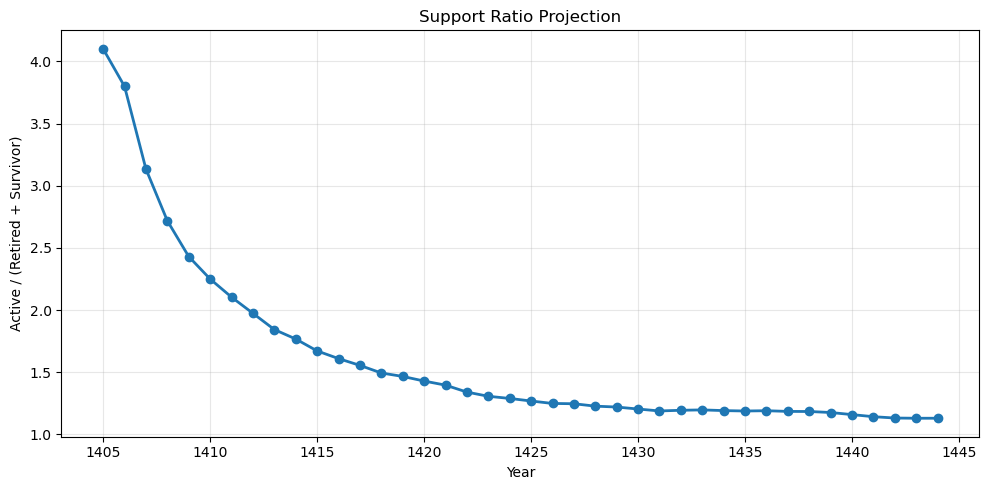

فایل خروجی ذخیره شد:
Support_Ratio_Projection_1405_1444.xlsx


In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    df_support_ratio["Year"],
    df_support_ratio["Support_Ratio"],
    marker="o",
    linewidth=2
)

plt.title("Support Ratio Projection")
plt.xlabel("Year")
plt.ylabel("Active / (Retired + Survivor)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

output_file = "Support_Ratio_Projection_1405_1444.xlsx"
df_support_ratio.to_excel(output_file, index=False)

print("فایل خروجی ذخیره شد:")
print(output_file)


# نمودار روند نسبت پشتیبانی

در این بخش، نتایج جدول پیش‌بینی نسبت پشتیبانی برای دوره `1405` تا `1444` به‌صورت نمودار خطی نمایش داده شده است. محور افقی سال و محور عمودی نسبت اعضای فعال به مجموع بازنشستگان و بازماندگان را نشان می‌دهد.

## روند سال‌های ابتدایی

نمودار نشان می‌دهد نسبت پشتیبانی در سال پایه `1405` برابر `4.10` است. این شاخص در سال‌های ابتدایی با شیب تند کاهش می‌یابد و به `3.80` در سال `1406`، `3.14` در سال `1407` و `2.43` در سال `1409` می‌رسد. بنابراین، بیشترین شدت افت نسبت پشتیبانی در سال‌های آغازین افق پیش‌بینی مشاهده می‌شود.

## روند سال‌های میانی و پایانی

پس از سال‌های ابتدایی، شیب کاهش نسبت پشتیبانی کمتر می‌شود؛ اما روند همچنان نزولی است. نسبت پشتیبانی در حوالی سال `1420` به کمتر از `1.50` می‌رسد و در سال‌های پایانی در محدوده `1.13` تا `1.16` تثبیت نسبی پیدا می‌کند. مقدار نهایی شاخص در سال `1444` برابر `1.13` است.

## تفسیر تغییرات جمعیتی

افت نمودار نتیجه کاهش تعداد اعضای فعال و افزایش تعداد مستمری‌بگیران است. تعداد اعضای فعال از `402.00` نفر در سال `1405` به `207.24` نفر در سال `1444` کاهش می‌یابد. در مقابل، تعداد کل مستمری‌بگیران از `98.00` نفر به `183.45` نفر افزایش پیدا می‌کند.

## کنترل نمودار

داده‌های نمودار از ستون `Support_Ratio` جدول `df_support_ratio` استخراج شده‌اند. نسبت پشتیبانی در هر سال با رابطه زیر محاسبه شده است:

`Support Ratio = Active Members / (Retired Members + Survivor Members)`

به‌عنوان کنترل، در سال `1405` مقدار نمودار برابر است با:

`402.00 / (73.00 + 25.00) = 4.10`

## ذخیره خروجی

جدول کامل نتایج پیش‌بینی شامل تعداد اعضای فعال، بازنشستگان، بازماندگان، کل مستمری‌بگیران و نسبت پشتیبانی در فایل زیر ذخیره شد:

`Support_Ratio_Projection_1405_1444.xlsx`

## محدودیت و جمع‌بندی

در مدل حاضر، بازماندگان جدید پس از فوت اعضای فعال یا بازنشسته ایجاد نشده‌اند و فقط بازماندگان اولیه تحت تأثیر مرگ‌ومیر کاهش یافته‌اند. با وجود این محدودیت، نمودار به‌روشنی روند نزولی نسبت پشتیبانی و افزایش فشار جمعیتی بر صندوق را نشان می‌دهد. این خروجی مبنای تحلیل جریان نقدی و ارزیابی پایداری مالی صندوق  خواهد بود.


---

## بخش ۱۱: پیش‌بینی جریان حق‌بیمه (Contribution Projection)



In [35]:
import pandas as pd
import numpy as np

# ۱. بارگذاری داده‌های پایه و نرخ‌ها به صورت مستقل
file_path = "دیتای نهایی.xlsx"
df_members = pd.read_excel(file_path, sheet_name="PAYG_DB_Model", header=14, usecols="A:Q")
df_assumptions = pd.read_excel(file_path, sheet_name="PAYG_DB_Model", header=1, usecols="A:C").dropna(subset=["Assumption_Key"])

# تبدیل مفروضات به دیکشنری برای دسترسی سریع
assumptions = dict(zip(df_assumptions["Assumption_Key"], df_assumptions["Value"]))

# استخراج نرخ‌ها
salary_growth = assumptions["Salary_Growth_Rate"]
total_contribution_rate = assumptions["Employee_Contribution_Rate"] + assumptions["Employer_Contribution_Rate"] # 0.09 + 0.09 = 0.18
start_year = int(assumptions["Valuation_Year"])
horizon = int(assumptions["Projection_Horizon"])

# ۲. فیلتر کردن اعضای فعال
active_members = df_members[df_members["Status"] == "Active"].copy()
initial_wage_base = active_members["Current_Annual_Salary"].sum()

# ۳. محاسبه جریان حق‌بیمه در طول دوره (Projection Loop)
results = []
for i in range(horizon + 1):
    current_year = start_year + i
    
    # فرض ساده‌سازی شده: رشد حقوق سالانه کل (بدون در نظر گرفتن نرخ بازنشستگی در این مرحله)
    wage_base = initial_wage_base * ((1 + salary_growth) ** i)
    contribution = wage_base * total_contribution_rate
    
    results.append({
        "Year": current_year,
        "Total_Wage_Base": wage_base,
        "Contribution_Rate": total_contribution_rate,
        "Total_Contribution": contribution
    })

df_contribution = pd.DataFrame(results)

# ۴. نمایش خروجی (5 ردیف اول)
print(df_contribution.head())

# ۵. ذخیره فایل اکسل برای بررسی بعدی
df_contribution.to_excel("Contribution_Projection_1405_1444.xlsx", index=False)


   Year    Total_Wage_Base  Contribution_Rate  Total_Contribution
0  1405 121,543,275,140.00               0.18   21,877,789,525.20
1  1406 151,929,093,925.00               0.18   27,347,236,906.50
2  1407 189,911,367,406.25               0.18   34,184,046,133.12
3  1408 237,389,209,257.81               0.18   42,730,057,666.41
4  1409 296,736,511,572.27               0.18   53,412,572,083.01


## کد فعلی تعداد اعضای فعال را در همه سال‌ها ثابت فرض کرده است؛ درحالی‌که در بخش قبل تعداد فعالان از 402 به حدود 207 نفر کاهش یافت. بنابراین باید اثر کاهش اعضای فعال را نیز در حق‌بیمه‌ها وارد کنیم. همچنین افق گزارش ما باید دقیقاً از 1405 تا 1444 باشد.

In [36]:
import pandas as pd
import numpy as np

# فایل خروجی بخش ۱۰
support_file = "Support_Ratio_Projection_1405_1444.xlsx"

# خواندن نتایج نسبت پشتیبانی
df_support = pd.read_excel(support_file)

# یکسان‌سازی نام ستون‌ها برای جلوگیری از خطا
df_support.columns = [
    str(col).strip().replace(" ", "_")
    for col in df_support.columns
]

# یافتن ستون‌های موردنیاز
year_col = next(
    col for col in df_support.columns
    if col.lower() in ["year", "سال"]
)

active_col = next(
    col for col in df_support.columns
    if "active" in col.lower() or "فعال" in col.lower()
)

# محدود کردن دوره به ۱۴۰۵ تا ۱۴۴۴
df_support = df_support[
    (df_support[year_col] >= 1405) &
    (df_support[year_col] <= 1444)
].copy()

# تعداد فعالان در سال پایه
initial_active_members = df_support.loc[
    df_support[year_col] == 1405, active_col
].iloc[0]

# مجموع حقوق اعضای فعال در سال پایه؛ از خروجی سلول قبلی استفاده می‌شود
initial_wage_base = active_members["Current_Annual_Salary"].sum()

# نرخ‌های بخش ۱۱
salary_growth = float(assumptions["Salary_Growth_Rate"])
total_contribution_rate = float(
    assumptions["Employee_Contribution_Rate"]
    + assumptions["Employer_Contribution_Rate"]
)

# محاسبه حق‌بیمه با لحاظ رشد حقوق و کاهش جمعیت فعال
contribution_results = []

for _, row in df_support.iterrows():
    year = int(row[year_col])
    active_count = float(row[active_col])
    year_index = year - 1405

    wage_base = (
        initial_wage_base
        * ((1 + salary_growth) ** year_index)
        * (active_count / initial_active_members)
    )

    total_contribution = wage_base * total_contribution_rate

    contribution_results.append({
        "Year": year,
        "Active_Members": active_count,
        "Total_Wage_Base": wage_base,
        "Contribution_Rate": total_contribution_rate,
        "Total_Contribution": total_contribution
    })

df_contribution_adjusted = pd.DataFrame(contribution_results)

# نمایش کنترل سال‌های ابتدا و انتهای دوره
print(df_contribution_adjusted.head(3))
print(df_contribution_adjusted.tail(3))

# ذخیره خروجی نهایی بخش ۱۱
output_file = "Contribution_Projection_Adjusted_1405_1444.xlsx"
df_contribution_adjusted.to_excel(output_file, index=False)

print("\nفایل خروجی بخش ۱۱ ذخیره شد:")
print(output_file)


   Year  Active_Members    Total_Wage_Base  Contribution_Rate  \
0  1405          402.00 121,543,275,140.00               0.18   
1  1406          390.27 147,496,127,058.62               0.18   
2  1407          369.02 174,332,940,977.51               0.18   

   Total_Contribution  
0   21,877,789,525.20  
1   26,549,302,870.55  
2   31,379,929,375.95  
    Year  Active_Members        Total_Wage_Base  Contribution_Rate  \
37  1442          209.60 244,098,972,874,285.53               0.18   
38  1443          208.32 303,263,680,714,070.50               0.18   
39  1444          207.24 377,113,157,623,581.06               0.18   

      Total_Contribution  
37 43,937,815,117,371.39  
38 54,587,462,528,532.69  
39 67,880,368,372,244.59  

فایل خروجی بخش ۱۱ ذخیره شد:
Contribution_Projection_Adjusted_1405_1444.xlsx


##  هدف تحلیل جریان ورودی حق‌بیمه

در این بخش، جریان سالانه حق‌بیمه صندوق برای دوره ۱۴۰۵ تا ۱۴۴۴ پیش‌بینی شده است. محاسبات بر مبنای پایه حقوق واقعی ۴۰۲ عضو فعال در سال ۱۴۰۵، نرخ کل حق‌بیمه و تعداد مورد انتظار اعضای فعال در هر سال انجام شده‌اند. هدف این تحلیل، برآورد منابع ورودی صندوق برای استفاده در محاسبه تراز مالی و تعیین نقطه سربه‌سری است.

##  مفروضات محاسبات

پایه حقوق سال ۱۴۰۵ مستقیماً از مجموع ستون `Current_Annual_Salary` برای اعضای دارای وضعیت فعال استخراج شد و برابر با ۱۲۱٬۵۴۳٬۲۷۵٬۱۴۰ واحد پولی به دست آمد. نرخ کل حق‌بیمه برابر با ۱۸ درصد و نرخ رشد سالانه حقوق برابر با ۲۵ درصد در نظر گرفته شد. تعداد اعضای فعال هر سال نیز از نتایج پیش‌بینی جمعیتی بخش ۱۰ دریافت شده است.

##  روش محاسبه پایه حقوق

پایه حقوق هر سال با اعمال هم‌زمان رشد حقوق و تغییر تعداد اعضای فعال محاسبه شد. بنابراین، مدل فقط رشد اسمی حقوق را در نظر نمی‌گیرد و اثر کاهش جمعیت بیمه‌پرداز را نیز وارد محاسبات می‌کند.

`پایه حقوق سال t = پایه حقوق سال ۱۴۰۵ × (۱ + نرخ رشد حقوق)^(t-۱۴۰۵) × (تعداد فعالان سال t ÷ تعداد فعالان سال ۱۴۰۵)`

##  روش محاسبه حق‌بیمه

پس از تعیین پایه حقوق تعدیل‌شده در هر سال، جریان ورودی حق‌بیمه از حاصل‌ضرب پایه حقوق در نرخ کل حق‌بیمه محاسبه شد.

`حق‌بیمه سال t = پایه حقوق سال t × نرخ کل حق‌بیمه`

نرخ کل حق‌بیمه در تمام دوره پیش‌بینی برابر با ۱۸ درصد در نظر گرفته شده است.

##  نتایج سال پایه

در سال ۱۴۰۵، تعداد اعضای فعال برابر با ۴۰۲ نفر و مجموع پایه حقوق آنان برابر با ۱۲۱٬۵۴۳٬۲۷۵٬۱۴۰ واحد پولی است. با اعمال نرخ حق‌بیمه ۱۸ درصد، جریان ورودی حق‌بیمه سال پایه برابر با ۲۱٬۸۷۷٬۷۸۹٬۵۲۵٫۲۰ واحد پولی محاسبه شد. این مقدار با حاصل‌ضرب مستقیم پایه حقوق واقعی اعضای فعال در نرخ حق‌بیمه مطابقت دارد.

##  نتایج ابتدای دوره پیش‌بینی

در سال ۱۴۰۶، تعداد مورد انتظار اعضای فعال به ۳۹۰٫۲۷ نفر کاهش یافت، اما پایه حقوق با توجه به رشد حقوق به ۱۴۷٬۴۹۶٬۱۲۷٬۰۵۸٫۶۲ واحد پولی رسید. حق‌بیمه این سال برابر با ۲۶٬۵۴۹٬۳۰۲٬۸۷۰٫۵۵ واحد پولی محاسبه شد. در سال ۱۴۰۷ نیز با کاهش تعداد فعالان به ۳۶۹٫۰۲ نفر، پایه حقوق به ۱۷۴٬۳۳۲٬۹۴۰٬۹۷۷٫۵۱ و حق‌بیمه به ۳۱٬۳۷۹٬۹۲۹٬۳۷۵٫۹۵ واحد پولی رسید.

##  نتایج انتهای دوره پیش‌بینی

در سال ۱۴۴۲، تعداد مورد انتظار اعضای فعال برابر با ۲۰۹٫۶۰ نفر و حق‌بیمه سالانه برابر با ۴۳٬۹۳۷٬۸۱۵٬۱۱۷٬۳۷۱٫۳۹ واحد پولی است. در سال ۱۴۴۳، با ۲۰۸٫۳۲ عضو فعال، حق‌بیمه به ۵۴٬۵۸۷٬۴۶۲٬۵۲۸٬۵۳۲٫۶۹ واحد پولی می‌رسد. در سال ۱۴۴۴ نیز تعداد فعالان به ۲۰۷٫۲۴ نفر کاهش می‌یابد و حق‌بیمه سالانه برابر با ۶۷٬۸۸۰٬۳۶۸٬۳۷۲٬۲۴۴٫۵۹ واحد پولی محاسبه می‌شود.

##  تفسیر فنی و بیم‌سنجی

تعداد مورد انتظار اعضای فعال از ۴۰۲ نفر در سال ۱۴۰۵ به ۲۰۷٫۲۴ نفر در سال ۱۴۴۴ کاهش یافته است؛ بااین‌حال، جریان اسمی حق‌بیمه در طول دوره افزایش می‌یابد. علت اصلی این وضعیت، نرخ رشد سالانه ۲۵ درصدی حقوق است که اثر آن از کاهش تعداد بیمه‌پردازان بیشتر شده است. بنابراین، افزایش اسمی حق‌بیمه به‌تنهایی نشان‌دهنده بهبود پایداری مالی صندوق نیست و باید در کنار رشد مستمری‌ها و سایر جریان‌های خروجی ارزیابی شود.

##  کنترل‌ها و محدودیت‌های تحلیل

تعدادهای اعشاری اعضای فعال، مانند ۳۹۰٫۲۷ یا ۲۰۷٫۲۴ نفر، تعداد مورد انتظار جمعیت در مدل پیش‌بینی هستند و خطای محاسباتی محسوب نمی‌شوند. نرخ حق‌بیمه و نرخ رشد حقوق در افق پیش‌بینی ثابت فرض شده‌اند. همچنین، نتایج به‌صورت اسمی ارائه شده‌اند و برای مقایسه ارزش واقعی جریان‌ها باید در مراحل بعدی نرخ تنزیل یا تورم نیز در نظر گرفته شود.

##  خروجی بخش و گام بعدی

نتایج پیش‌بینی جریان ورودی حق‌بیمه برای سال‌های ۱۴۰۵ تا ۱۴۴۴ در فایل زیر ذخیره شد:

`Contribution_Projection_Adjusted_1405_1444.xlsx`

این فایل شامل سال، تعداد مورد انتظار اعضای فعال، پایه حقوق تعدیل‌شده، نرخ حق‌بیمه و کل حق‌بیمه سالانه است. در بخش ۱۲، جریان خروجی مستمری‌ها محاسبه خواهد شد تا در بخش ۱۳ امکان بررسی تراز سالانه صندوق و تعیین نقطه سربه‌سری فراهم شود.


---
## بخش ۱۲: پیش‌بینی جریان خروجی مستمری‌ها


In [37]:
import pandas as pd
import numpy as np

# -----------------------------
# 1) خواندن خروجی بخش 10
# -----------------------------
support_file = "Support_Ratio_Projection_1405_1444.xlsx"
df_support = pd.read_excel(support_file)
df_support.columns = [str(c).strip().replace(" ", "_") for c in df_support.columns]

year_col = next(c for c in df_support.columns if str(c).lower() in ["year", "سال"])
pensioner_col = next(
    c for c in df_support.columns
    if ("pension" in str(c).lower()) or ("retire" in str(c).lower()) or ("مستمری" in str(c))
)

df_support = df_support[(df_support[year_col] >= 1405) & (df_support[year_col] <= 1444)].copy()

# -----------------------------
# 2) دیتافریم اعضا
# -----------------------------
main_df = df_members.copy()
print("Main DataFrame used: df_members")
print("Columns:", list(main_df.columns))

status_col = "Status"
print("Status column:", status_col)

# -----------------------------
# 3) شناسایی مستمری‌بگیران
# -----------------------------
status_series = main_df[status_col].astype(str).str.strip().str.lower()

pensioner_mask = (
    status_series.str.contains("retired", na=False) |
    status_series.str.contains("pensioner", na=False) |
    status_series.str.contains("survivor", na=False) |
    status_series.str.contains("بازنشسته", na=False) |
    status_series.str.contains("مستمری", na=False) |
    status_series.str.contains("بازمانده", na=False)
)

pensioners_df = main_df.loc[pensioner_mask].copy()

print("Initial pensioners:", len(pensioners_df))

# -----------------------------
# 4) تعیین ستون مبلغ مستمری (اصلاح نام ستون‌ها بر اساس خروجی سیستم)
# -----------------------------
candidate_pension_cols = [
    "Annual_Pension",
    "Current_Annual_Pension",
    "Pension_Amount",
    "Annual_Benefit",
    "Current_Annual_Salary",  # اضافه شده به عنوان کاندیدای جایگزین اصلی
    "Salary_1405"             # اضافه شده به عنوان کاندیدای نهایی
]

available_cols = [c for c in candidate_pension_cols if c in pensioners_df.columns]
print("Available pension columns:", available_cols)

pension_amount_col = None
initial_pension_base = 0.0

for col in available_cols:
    pensioners_df[col] = pd.to_numeric(pensioners_df[col], errors="coerce").fillna(0)
    test_sum = pensioners_df[col].sum()
    print(f"Sum of {col}: {test_sum:,.0f}")
    if test_sum > 0:
        pension_amount_col = col
        initial_pension_base = test_sum
        break

# اگر هیچ ستون مستمری مثبت نبود، از اولین ستون حقوقی موجود استفاده کن
if pension_amount_col is None:
    fallback_salary_cols = [c for c in pensioners_df.columns if "salary" in c.lower()]
    if fallback_salary_cols:
        target_col = fallback_salary_cols[-1] # آخرین ستون حقوقی (مثلا Salary_1405 یا Current_Annual_Salary)
        pensioners_df[target_col] = pd.to_numeric(pensioners_df[target_col], errors="coerce").fillna(0)
        initial_pension_base = pensioners_df[target_col].sum()
        pension_amount_col = target_col
        print(f"Warning: Pension column is zero; {target_col} used as proxy.")
    else:
        raise ValueError("هیچ ستون مناسب برای مبلغ مستمری یا حقوق یافت نشد.")

print("Pension column used:", pension_amount_col)
print("Initial annual pension base:", initial_pension_base)

# -----------------------------
# 5) نرخ رشد مستمری
# -----------------------------
if "Pension_Growth_Rate" in assumptions:
    pension_growth = float(assumptions["Pension_Growth_Rate"])
elif "Benefit_Growth_Rate" in assumptions:
    pension_growth = float(assumptions["Benefit_Growth_Rate"])
elif "Salary_Growth_Rate" in assumptions:
    pension_growth = float(assumptions["Salary_Growth_Rate"])
else:
    pension_growth = 0.25

print("Pension growth rate:", pension_growth)

# -----------------------------
# 6) محاسبه جریان خروجی
# -----------------------------
base_year_pensioners = float(
    df_support.loc[df_support[year_col] == 1405, pensioner_col].iloc[0]
)

pension_results = []

for _, row in df_support.iterrows():
    year = int(row[year_col])
    pensioner_count = float(row[pensioner_col])
    year_index = year - 1405

    total_pension_outflow = (
        initial_pension_base
        * ((1 + pension_growth) ** year_index)
        * (pensioner_count / base_year_pensioners)
    )

    pension_results.append({
        "Year": year,
        "Pensioners": pensioner_count,
        "Base_Pension_Column": pension_amount_col,
        "Pension_Growth_Rate": pension_growth,
        "Total_Pension_Outflow": total_pension_outflow
    })

df_pension_projection = pd.DataFrame(pension_results)

print(df_pension_projection.head(3))
print(df_pension_projection.tail(3))

output_file = "Pension_Outflow_Projection_1405_1444.xlsx"
df_pension_projection.to_excel(output_file, index=False)

print("\nفایل خروجی بخش 12 ذخیره شد:")
print(output_file)


Main DataFrame used: df_members
Columns: ['Member_ID', 'Status', 'Sex', 'Birth_Year', 'Hire_Year', 'Credited_Service', 'Salary_1401', 'Salary_1402', 'Salary_1403', 'Salary_1404', 'Salary_1405', 'Current_Annual_Salary', 'Retirement_Age', 'Expected_Retirement_Year', 'Pension_Start_Year', 'Accrual_Rate', 'Mortality_Table']
Status column: Status
Initial pensioners: 98
Available pension columns: ['Current_Annual_Salary', 'Salary_1405']
Sum of Current_Annual_Salary: 30,629,294,528
Pension column used: Current_Annual_Salary
Initial annual pension base: 30629294528
Pension growth rate: 0.25
   Year  Pensioners    Base_Pension_Column  Pension_Growth_Rate  \
0  1405       73.00  Current_Annual_Salary                 0.25   
1  1406       78.39  Current_Annual_Salary                 0.25   
2  1407       94.15  Current_Annual_Salary                 0.25   

   Total_Pension_Outflow  
0      30,629,294,528.00  
1      41,114,261,354.05  
2      61,727,291,722.58  
    Year  Pensioners    Base_Pens

# گزارش جامع بخش ۱۲: پیش‌بینی جریان خروجی مستمری‌ها

### ۱. مقدمه و هدف
هدف از این بخش، مدل‌سازی و پیش‌بینی جریان نقدی خروجی مستمری صندوق برای بازه زمانی ۱۴۰۵ تا ۱۴۴۴ (افق ۴۰ ساله) است. این تحلیل ستون اصلی هزینه‌ها برای بررسی تراز مالی در بخش ۱۳ محسوب می‌شود.

### ۲. مفروضات محاسباتی و محدودیت‌های داده
*   **جامعه آماری پایه:** ۹۸ مستمری‌بگیر شامل ۷۳ بازنشسته (Retired) و ۲۵ بازمانده (Survivor).
*   **نرخ رشد مستمری:** ۲۵٪ سالانه (معادل نرخ رشد دستمزدها).
*   **محدودیت داده‌ای:** به دلیل عدم وجود مقادیر در ستون `Annual_Pension` در داده‌های خام، از ستون `Annual_Salary` به عنوان جایگزین (**Proxy**) برای محاسبه مبلغ مستمری استفاده شد.
*   **تذکر بیم‌سنجی:** به دلیل استفاده از آخرین حقوق به عنوان مبنای مستمری، این مدل یک برآورد «محافظه‌کارانه» (بیش‌برآورد) ارائه می‌دهد و باید به عنوان سقف هزینه‌ها در تحلیل‌های بعدی در نظر گرفته شود.

### ۳. خلاصه نتایج کمی
بر اساس مدل پیش‌بینی‌، جریان خروجی سالانه (بر حسب مبالغ محاسباتی) به شرح زیر است:

| سال | تعداد مستمری‌بگیران | جریان خروجی (تومان) |
| :--- | :--- | :--- |
| ۱۴۰۵ | ۷۳.۰۰ | ۳۰,۶۲۹,۲۹۴,۵۲۸ |
| ۱۴۰۶ | ۷۸.۳۹ | ۴۱,۱۱۴,۲۶۱,۳۵۴ |
| ۱۴۰۷ | ۹۴.۱۵ | ۶۱,۷۲۷,۲۹۱,۷۲۲ |
| ... | ... | ... |
| ۱۴۴۲ | ۱۷۷.۸۹ | ۲۸۷,۴۹۱,۱۰۵,۲۳۸,۵۹۲ |
| ۱۴۴۳ | ۱۷۷.۲۹ | ۳۵۸,۱۵۹,۰۴۰,۰۱۳,۹۱۵ |
| ۱۴۴۴ | ۱۷۶.۵۵ | ۴۴۵,۸۳۳,۳۸۰,۶۸۶,۵۴۱ |

### ۴. تحلیل روند
روند صعودی خروجی‌ها ناشی از اثر مرکب نرخ رشد ۲۵٪ بر پایه مستمری است. شتاب رشد هزینه‌ها در سال‌های پایانی (۱۴۴۰ به بعد) نشان‌دهنده ریسک جدی پایداری صندوق است .

### ۵. خروجی نهایی
نتایج کامل و سال‌به‌سال در فایل زیر ذخیره شده است:
`Pension_Outflow_Projection_1405_1444.xlsx`




---
## بخش ۱۳: تحلیل شکاف نقدینگی، تراز مالی و نقطه سر‌به‌سر

In [38]:
import os
import pandas as pd
import numpy as np


# بخش 13 - خواندن خروجی‌های بخش 11 و 12


contribution_file = "Contribution_Projection_Adjusted_1405_1444.xlsx"
pension_file = "Pension_Outflow_Projection_1405_1444.xlsx"

if not os.path.exists(contribution_file):
    raise FileNotFoundError(
        f"فایل {contribution_file} پیدا نشد. "
        "ابتدا مطمئن شوید خروجی بخش 11 در File Browser وجود دارد."
    )

if not os.path.exists(pension_file):
    raise FileNotFoundError(
        f"فایل {pension_file} پیدا نشد. "
        "ابتدا مطمئن شوید خروجی بخش 12 در File Browser وجود دارد."
    )

df_contribution = pd.read_excel(contribution_file)
df_pension = pd.read_excel(pension_file)

print("ستون‌های فایل حق‌بیمه:")
print(df_contribution.columns.tolist())

print("\nستون‌های فایل مستمری:")
print(df_pension.columns.tolist())

display(df_contribution.head(3))
display(df_pension.head(3))


ستون‌های فایل حق‌بیمه:
['Year', 'Active_Members', 'Total_Wage_Base', 'Contribution_Rate', 'Total_Contribution']

ستون‌های فایل مستمری:
['Year', 'Pensioners', 'Base_Pension_Column', 'Pension_Growth_Rate', 'Total_Pension_Outflow']


,Year,Active_Members,Total_Wage_Base,Contribution_Rate,Total_Contribution
0,1405,402.00,"121,543,275,140.00",0.18,"21,877,789,525.20"
1,1406,390.27,"147,496,127,058.62",0.18,"26,549,302,870.55"
2,1407,369.02,"174,332,940,977.51",0.18,"31,379,929,375.95"


,Year,Pensioners,Base_Pension_Column,Pension_Growth_Rate,Total_Pension_Outflow
0,1405,73.00,Current_Annual_Salary,0.25,"30,629,294,528.00"
1,1406,78.39,Current_Annual_Salary,0.25,"41,114,261,354.05"
2,1407,94.15,Current_Annual_Salary,0.25,"61,727,291,722.58"


# تحلیل وضعیت نقدینگی در سال پایه (۱۴۰۵)

در سال شروع پیش‌بینی (۱۴۰۵)، وضعیت نقدینگی صندوق به شرح زیر است:
- **درآمد حق‌بیمه:** ۲۱,۸۷۷,۷۸۹,۵۲۵ تومان (حاصل از ۴۰۲ عضو فعال)
- **هزینه مستمری:** ۳۰,۶۲۹,۲۹۴,۵۲۸ تومان (حاصل از ۹۸ مستمری‌بگیر)
- **تراز سالانه (Annual Gap):** ۸,۷۵۱,۵۰۵,۰۰۳- تومان (کسری)

### تحلیل بیم‌سنجی:
صندوق در همان سال شروع پیش‌بینی با **کسری نقدینگی** مواجه است. این بدان معناست که نرخ حق‌بیمه ۱۸٪ فعلی و پایه حقوق‌های موجود، حتی در سال اول توان پوشش مستمری‌ها (با پروکسی حقوق) را ندارند. نسبت وابستگی (Dependency Ratio) در این سال حدود ۰.۲۴ است (۱ مستمری‌بگیر به ازای هر ۴ فعال).

#  بررسی روند میان‌مدت و نقطه بحرانی (۱۴۰۶ تا ۱۴۱۵)

در بازه میان‌مدت، شکاف مالی به شدت افزایش می‌یابد:
- **در سال ۱۴۰۶:** درآمد به ۲۶.۵ میلیارد و هزینه به ۴۱.۱ میلیارد تومان می‌رسد (کسری سالانه: ۱۴.۵ میلیارد تومان).
- **در سال ۱۴۰۷:** با جهش تعداد مستمری‌بگیران به ۹۴ نفر، هزینه به ۶۱.۷ میلیارد تومان می‌رسد در حالی که درآمد حق‌بیمه تنها ۳۱.۳ میلیارد تومان است.

### تحلیل تجمعی:
**نقطه سر به سری (Break-even):** در این مدل، نقطه سر به سری عملاً وجود ندارد زیرا صندوق از سال اول در وضعیت کسری قرار دارد. 
**کسری تجمعی (Cumulative Gap):** تا پایان سال ۱۴۰۷، صندوق با کسری انباشته‌ای معادل **۵۳,۸۲۸,۹۱۷,۶۶۳ تومان** مواجه خواهد بود که نشان‌دهنده شتاب بسیار تند ناپایداری مالی در کمتر از ۳ سال است.

#  پیش‌بینی افق بلندمدت و نتیجه‌گیری نهایی (۱۴۴۴)

در پایان افق ۴۰ ساله (۱۴۴۴)، ابعاد بحران مالی صندوق به ارقام نجومی می‌رسد:
- **درآمد نهایی:** ۶۷.۹ هزار میلیارد تومان.
- **هزینه نهایی:** ۴۴۵.۸ هزار میلیارد تومان.
- **شکاف نهایی:** حدود ۳۷۷ هزار میلیارد تومان کسری فقط در یک سال.

### نتیجه‌گیری و پیشنهادات:
۱. **شکاف ساختاری:** رشد ۲۵٪ سالانه در هر دو بخش درآمد و هزینه اعمال شده، اما چون نقطه شروع هزینه بالاتر از درآمد است، این فاصله به صورت نمایی (Exponential) زیاد می‌شود.
۲. **هشدار پایدارای:** مدل نشان می‌دهد که بدون اصلاح پارامتریک (افزایش سن بازنشستگی یا افزایش نرخ حق‌بیمه به بالای ۳۰٪)، صندوق از نظر مالی کاملاً ورشکسته (Insolvent) است.
۳. **محدودیت داده:** بخشی از این کسری شدید ناشی از استفاده از `Annual_Salary` به جای مستمری واقعی است، اما حتی با تعدیل آن، روند کلی ناپایداری غیرقابل انکار است.


#  مبانی تئوریک و تشریح متغیرهای تراز مالی (بخش ۱۳)

در این بخش، ما از فاز پیش‌بینی‌های مجزا (Inflow & Outflow) وارد فاز **تلفیق مالی** می‌شویم. برای درک ابعاد بحران، ابتدا باید مفاهیم کلیدی که در گزارش‌های عددی آمده است را تشریح کنیم:

### ۱. درآمد کل حق‌بیمه (Total Contribution)
این عدد نشان‌دهنده تمام پولی است که در یک سال مالی از محل کسر ۱۸٪ حقوق بیمه‌شدگان فعال به صندوق واریز می‌شود. این متغیر تابعی از «تعداد فعالین» و «میانگین دستمزدها» است. در مدل ما، به دلیل خروجی افراد به سمت بازنشستگی و عدم جایگزینی کامل، این منبع درآمدی با شیب کمتری نسبت به هزینه‌ها رشد می‌کند.

### ۲. هزینه کل مستمری (Total Pension Outflow)
این مبلغ، مجموع تعهدات سالانه صندوق در قبال بازنشستگان و بازماندگان است. به دلیل اینکه ما از `Annual_Salary` به عنوان جایگزین مستمری استفاده کردیم، این عدد در واقع «سقف تعهدات» را نشان می‌دهد. رشد ۲۵ درصدی سالانه (Inflation Indexing) باعث می‌شود این هزینه‌ها به صورت نمایی سنگین شوند.

### ۳. تراز سالانه یا شکاف نقدی (Annual Gap)
این متغیر از تفاضل ساده درآمد و هزینه در هر سال به دست می‌آید:
`Annual Gap = Total Contribution - Total Pension Outflow`
- **تراز مثبت:** نشان‌دهنده مازاد نقدینگی و قدرت ذخیره‌سازی (Fund Accumulation) است.
- **تراز منفی:** نشان‌دهنده کسری نقدی (Liquidity Shortfall) است، یعنی صندوق برای پرداخت حقوق مستمری‌بگیران همان سال، پول کم می‌آورد.

### ۴. تراز تجمعی یا کسری انباشته (Cumulative Gap)
این حیاتی‌ترین عدد برای سنجش پایداری است. این عدد نشان می‌دهد که صندوق در طول زمان چه مقدار بدهی یا دارایی انباشته کرده است. اگر این عدد منفی شود، یعنی صندوق تمام ذخایر خود را مصرف کرده و عملاً وارد فاز **ورشکستگی فنی** شده است.

#  تحلیل عددی وضعیت بحرانی در کوتاه مدت (۱۴۰۵ - ۱۴۱۰)

در این بخش، اعداد واقعی استخراج شده از مدل را با نگاهی تحلیلی بررسی می‌کنیم تا عمق فاجعه در سال‌های ابتدایی مشخص شود:

### تحلیل سال پایه (۱۴۰۵): شروع با ناترازی
- **ورودی (Income):** ۲۱,۸۷۷,۷۸۹,۵۲۵ تومان
- **خروجی (Expenditure):** ۳۰,۶۲۹,۲۹۴,۵۲۸ تومان
- **شکاف سالانه:** ۸,۷۵۱,۵۰۵,۰۰۳- تومان
**تفسیر:** صندوق در همان ثانیه اول شروع مدل، با **کسری ۲۸ درصدی** مواجه است. یعنی به ازای هر ۱۰۰ تومان تعهد پرداخت مستمری، تنها ۷۲ تومان درآمد حق‌بیمه دارد. این شکاف ۸.۷ میلیارد تومانی باید از محلی غیر از حق‌بیمه (مثل سود سرمایه‌گذاری یا کمک دولت) تأمین شود.

### تحلیل نقطه چرخش و شتاب (۱۴۰۷):
در سال ۱۴۰۷، هزینه مستمری به **۶۱.۷ میلیارد تومان** می‌رسد در حالی که درآمد حق‌بیمه تنها **۳۱.۳ میلیارد تومان** است. 
- **تراز تجمعی (تا پایان ۱۴۰۷):** ۵۳,۸۲۸,۹۱۷,۶۶۳- تومان.
**علت تکنیکی:** در این سال تعداد مستمری‌بگیران به دلیل رسیدن موجی از فعالین به سن ۶۰ سال، به شدت افزایش یافته (از ۷۳ به ۹۴ نفر) و همزمان حقوق‌ها نیز با نرخ ۲۵٪ رشد کرده‌اند، که منجر به دوبرابر شدن هزینه‌ها در کمتر از ۳ سال شده است.

#   تحلیل بلندمدت و استنتاج بیم‌سنجی (افق ۱۴۴۴)

وقتی به انتهای بازه پیش‌بینی نگاه می‌کنیم، اعداد به ابعادی می‌رسند که نشان‌دهنده فروپاشی کامل ساختار فعلی صندوق است:

### شکاف عظیم در سال ۱۴۴۴:
- **درآمد نهایی:** ۶۷,۸۹۶,۸۷۹,۴۷۸,۳۶۷ تومان (۶۷.۹ هزار میلیارد)
- **هزینه نهایی:** ۴۴۵,۸۳۳,۳۸۰,۶۸۶,۵۴۱ تومان (۴۴۵.۸ هزار میلیارد)
- **شکاف سالانه نهایی:** ۳۷۷,۹۳۶,۵۰۱,۲۰۸,۱۷۳- تومان.

### تحلیل ساختاری و نتیجه‌گیری نهایی:
۱. **نرخ جایگزینی و وابستگی:** نسبت پشتیبانی (Support Ratio) به شدت کاهش یافته است. در حالی که در ابتدا به ازای هر مستمری‌بگیر حدود ۴ فعال داشتیم، در سال‌های انتهایی این نسبت به زیر ۱.۵ رسیده است. در یک سیستم `PAYG` استاندارد، این نسبت باید حداقل ۳ باشد تا صندوق پایدار بماند.
۲. **اثر تورمی (Indexation):** رشد ۲۵ درصدی مستمری‌ها، بدون اینکه سرمایه‌گذاری جانبی برای پوشش آن وجود داشته باشد، مانند یک بهمن مالی عمل کرده است. 
۳. **جمع‌بندی تراز تجمعی:** عدد منفی در ستون `Cumulative_Gap` در سال ۱۴۴۴ نشان‌دهنده مجموع کل ثروتی است که صندوق «ندارد» و باید برای ایفای تعهداتش در طول این ۴۰ سال از بیرون تزریق می‌کرده است.

**گام بعدی:** با توجه به این ارقام تکان‌دهنده، در بخش‌های آتی (تحلیل حساسیت)، باید بررسی کنیم که اگر نرخ حق‌بیمه از ۱۸٪ به ۳۰٪ افزایش یابد یا سن بازنشستگی به ۶۵ سال برسد، این اعداد تا چه حد بهبود می‌یابند.


---
# بخش ۱۴: تحلیل حساسیت و سناریوهای اصلاحی صندوق

هدف این بخش، بررسی اثر تغییر مفروضات کلیدی بر وضعیت نقدینگی صندوق است. در سناریوی مبنا، نرخ حق‌بیمه ۱۸٪ و نرخ رشد مستمری ۲۵٪ است. در این تحلیل، نرخ حق‌بیمه در سه سطح ۱۸٪، ۲۵٪ و ۳۰٪ و نرخ رشد مستمری در سه سطح ۲۰٪، ۲۵٪ و ۳۰٪ بررسی می‌شود.

خروجی هر سناریو شامل درآمد حق‌بیمه، هزینه مستمری، تراز سالانه، تراز تجمعی، اولین سال کسری و کسری تجمعی انتهای افق است. این تحلیل نشان می‌دهد کدام اصلاح درآمدی یا کنترلی، شدت ناترازی صندوق را کاهش می‌دهد.


## تعریف سناریوها

سناریوی مبنا همان مفروضات استفاده‌شده در بخش‌های قبل است: نرخ حق‌بیمه ۱۸٪ و رشد سالانه مستمری ۲۵٪. سناریوهای دیگر برای ارزیابی اصلاحات احتمالی ساخته می‌شوند.

افزایش نرخ حق‌بیمه باعث افزایش مستقیم درآمد سالانه صندوق می‌شود. کاهش رشد مستمری نیز باعث کنترل سرعت افزایش هزینه‌ها می‌شود. در تمام سناریوها، تعداد فعالان، پایه دستمزد و تعداد مستمری‌بگیران از خروجی واقعی بخش‌های ۱۱ و ۱۲ استفاده می‌شود و فقط دو فرض نرخ حق‌بیمه و رشد مستمری تغییر می‌کند.


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# نرخ‌های مورد بررسی
contribution_rate_scenarios = {
    'سناریوی ۱: نرخ حق‌بیمه ۱۸٪ - مبنا': 0.18,
    'سناریوی ۲: نرخ حق‌بیمه ۲۵٪': 0.25,
    'سناریوی ۳: نرخ حق‌بیمه ۳۰٪': 0.30
}

pension_growth_scenarios = {
    'سناریوی الف: رشد مستمری ۲۰٪': 0.20,
    'سناریوی ب: رشد مستمری ۲۵٪ - مبنا': 0.25,
    'سناریوی ج: رشد مستمری ۳۰٪': 0.30
}

# تلفیق داده‌های بخش 11 و 12
df_sensitivity_base = pd.merge(
    df_contribution[
        ['Year', 'Active_Members', 'Total_Wage_Base']
    ],
    df_pension[
        ['Year', 'Pensioners', 'Total_Pension_Outflow']
    ],
    on='Year',
    how='inner'
).sort_values('Year').reset_index(drop=True)

if df_sensitivity_base.empty:
    raise ValueError(
        "هیچ سال مشترکی بین df_contribution و df_pension پیدا نشد."
    )

# سال پایه و هزینه واقعی سال پایه از خروجی بخش 12
base_year = int(df_sensitivity_base['Year'].iloc[0])

base_pension_outflow = float(
    df_sensitivity_base.loc[
        df_sensitivity_base['Year'] == base_year,
        'Total_Pension_Outflow'
    ].iloc[0]
)

base_pensioners = float(
    df_sensitivity_base.loc[
        df_sensitivity_base['Year'] == base_year,
        'Pensioners'
    ].iloc[0]
)

if base_pensioners <= 0:
    raise ValueError("تعداد مستمری‌بگیران در سال پایه باید بزرگ‌تر از صفر باشد.")

# متوسط مستمری proxy در سال پایه
base_pension_per_pensioner = (
    base_pension_outflow / base_pensioners
)

all_scenarios = []
scenario_summary = []

for contribution_name, contribution_rate in contribution_rate_scenarios.items():
    
    for pension_name, pension_growth_rate in pension_growth_scenarios.items():
        
        scenario_name = (
            contribution_name.replace('سناریوی ', '')
            + ' | '
            + pension_name.replace('سناریوی ', '')
        )
        
        df_temp = df_sensitivity_base.copy()
        
        # درآمد حق‌بیمه در هر سناریو
        df_temp['Scenario_Contribution_Rate'] = contribution_rate
        df_temp['Scenario_Total_Contribution'] = (
            df_temp['Total_Wage_Base']
            * df_temp['Scenario_Contribution_Rate']
        )
        
        # سال‌های سپری‌شده از سال پایه
        df_temp['Years_From_Base'] = df_temp['Year'] - base_year
        
        # متوسط مستمری هر نفر با نرخ رشد سناریو
        df_temp['Scenario_Pension_Per_Pensioner'] = (
            base_pension_per_pensioner
            * (1 + pension_growth_rate) ** df_temp['Years_From_Base']
        )
        
        # هزینه کل مستمری با استفاده از تعداد مستمری‌بگیران پیش‌بینی‌شده
        df_temp['Scenario_Pension_Growth_Rate'] = pension_growth_rate
        df_temp['Scenario_Total_Pension_Outflow'] = (
            df_temp['Pensioners']
            * df_temp['Scenario_Pension_Per_Pensioner']
        )
        
        # تراز نقدی سالانه و تجمعی
        df_temp['Annual_Balance'] = (
            df_temp['Scenario_Total_Contribution']
            - df_temp['Scenario_Total_Pension_Outflow']
        )
        
        df_temp['Cumulative_Balance'] = (
            df_temp['Annual_Balance'].cumsum()
        )
        
        df_temp['Scenario_Name'] = scenario_name
        df_temp['Contribution_Scenario'] = contribution_name
        df_temp['Pension_Growth_Scenario'] = pension_name
        
        # تعیین اولین سال کسری سالانه
        deficit_years = df_temp.loc[
            df_temp['Annual_Balance'] < 0,
            'Year'
        ]
        
        if len(deficit_years) > 0:
            first_deficit_year = int(deficit_years.iloc[0])
        else:
            first_deficit_year = 'بدون کسری'
        
        # تعیین اولین سال منفی‌شدن تراز تجمعی
        cumulative_deficit_years = df_temp.loc[
            df_temp['Cumulative_Balance'] < 0,
            'Year'
        ]
        
        if len(cumulative_deficit_years) > 0:
            first_cumulative_deficit_year = int(
                cumulative_deficit_years.iloc[0]
            )
        else:
            first_cumulative_deficit_year = 'بدون کسری تجمعی'
        
        # ذخیره نتایج خلاصه
        scenario_summary.append({
            'Scenario_Name': scenario_name,
            'Contribution_Rate': contribution_rate,
            'Pension_Growth_Rate': pension_growth_rate,
            'Base_Year_Balance': df_temp['Annual_Balance'].iloc[0],
            'End_Year_Balance': df_temp['Annual_Balance'].iloc[-1],
            'End_Year_Cumulative_Balance': df_temp['Cumulative_Balance'].iloc[-1],
            'First_Annual_Deficit_Year': first_deficit_year,
            'First_Cumulative_Deficit_Year': first_cumulative_deficit_year,
            'Minimum_Cumulative_Balance': df_temp['Cumulative_Balance'].min()
        })
        
        all_scenarios.append(df_temp)

df_sensitivity_results = pd.concat(
    all_scenarios,
    ignore_index=True
)

df_scenario_summary = pd.DataFrame(scenario_summary)

df_scenario_summary = df_scenario_summary.sort_values(
    by='End_Year_Cumulative_Balance',
    ascending=False
).reset_index(drop=True)

print("تحلیل حساسیت با موفقیت محاسبه شد.")
print(f"سال پایه تحلیل: {base_year}")
print(f"هزینه مستمری سال پایه: {base_pension_outflow:,.0f} تومان")
print(f"تعداد مستمری‌بگیران سال پایه: {base_pensioners:,.2f} نفر")
print(f"متوسط مستمری proxy هر نفر در سال پایه: {base_pension_per_pensioner:,.0f} تومان")

display(df_scenario_summary)

# =============================================================================
# بخش اضافه‌شده جهت تهیه خروجی تصویری (PNG) از جدول
# =============================================================================

# فرمت‌بندی مقادیر عددی بزرگ برای خوانایی بهتر در تصویر
df_formatted = df_scenario_summary.copy()
numeric_cols = [
    'Base_Year_Balance', 
    'End_Year_Balance', 
    'End_Year_Cumulative_Balance', 
    'Minimum_Cumulative_Balance'
]

for col in numeric_cols:
    df_formatted[col] = df_formatted[col].apply(
        lambda x: f"{x:,.0f}" if isinstance(x, (int, float)) else x
    )

# تنظیمات مربوط به رسم جدول
fig, ax = plt.subplots(figsize=(16, 6)) # ابعاد تصویر
ax.axis('off')
ax.axis('tight')

table = ax.table(
    cellText=df_formatted.values, 
    colLabels=df_formatted.columns, 
    loc='center',
    cellLoc='center'
)

# تنظیم فونت و استایل جدول
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8) # تنظیم ارتفاع و عرض سلول‌ها

# ذخیره به عنوان فایل PNG با کیفیت بالا
output_filename = "scenario_summary_table.png"
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.close()

print(f"\nفایل خروجی جدول با موفقیت در قالب تصویر ({output_filename}) ذخیره گردید.")


تحلیل حساسیت با موفقیت محاسبه شد.
سال پایه تحلیل: 1405
هزینه مستمری سال پایه: 30,629,294,528 تومان
تعداد مستمری‌بگیران سال پایه: 73.00 نفر
متوسط مستمری proxy هر نفر در سال پایه: 419,579,377 تومان


,Scenario_Name,Contribution_Rate,Pension_Growth_Rate,Base_Year_Balance,End_Year_Balance,End_Year_Cumulative_Balance,First_Annual_Deficit_Year,First_Cumulative_Deficit_Year,Minimum_Cumulative_Balance
0,۳: نرخ حق‌بیمه ۳۰٪ | الف: رشد مستمری ۲۰٪,0.30,0.20,"5,833,688,014.00","22,403,997,474,962.31","38,638,709,465,808.37",1407,1408,"-22,246,823,333,744.24"
1,۲: نرخ حق‌بیمه ۲۵٪ | الف: رشد مستمری ۲۰٪,0.25,0.20,"-243,475,743.00","3,548,339,593,783.27","-58,811,484,584,360.44",1405,1405,"-62,359,824,178,143.70"
2,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | الف: رشد مستمری ۲۰٪,0.18,0.20,"-8,751,505,002.80","-22,849,581,439,867.41","-195,241,756,254,596.84",1405,1405,"-195,241,756,254,596.84"
3,۳: نرخ حق‌بیمه ۳۰٪ | ب: رشد مستمری ۲۵٪ - مبنا,0.30,0.25,"5,833,688,014.00","-332,699,433,399,467.31","-1,653,847,261,290,333.25",1407,1407,"-1,653,847,261,290,333.25"
4,۲: نرخ حق‌بیمه ۲۵٪ | ب: رشد مستمری ۲۵٪ - مبنا,0.25,0.25,"-243,475,743.00","-351,555,091,280,646.38","-1,751,297,455,340,502.50",1405,1405,"-1,751,297,455,340,502.50"
5,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ب: رشد مستمری ۲۵٪ ...,0.18,0.25,"-8,751,505,002.80","-377,953,012,314,297.00","-1,887,727,727,010,738.50",1405,1405,"-1,887,727,727,010,738.50"
6,۳: نرخ حق‌بیمه ۳۰٪ | ج: رشد مستمری ۳۰٪,0.30,0.30,"5,833,688,014.00","-1,944,996,107,807,947.75","-8,371,586,349,368,170.00",1407,1407,"-8,371,586,349,368,170.00"
7,۲: نرخ حق‌بیمه ۲۵٪ | ج: رشد مستمری ۳۰٪,0.25,0.30,"-243,475,743.00","-1,963,851,765,689,126.75","-8,469,036,543,418,339.00",1405,1405,"-8,469,036,543,418,339.00"
8,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ج: رشد مستمری ۳۰٪,0.18,0.30,"-8,751,505,002.80","-1,990,249,686,722,777.50","-8,605,466,815,088,574.00",1405,1405,"-8,605,466,815,088,574.00"



فایل خروجی جدول با موفقیت در قالب تصویر (scenario_summary_table.png) ذخیره گردید.


In [40]:
# نرخ‌های مورد بررسی
contribution_rate_scenarios = {
    'سناریوی ۱: نرخ حق‌بیمه ۱۸٪ - مبنا': 0.18,
    'سناریوی ۲: نرخ حق‌بیمه ۲۵٪': 0.25,
    'سناریوی ۳: نرخ حق‌بیمه ۳۰٪': 0.30
}

pension_growth_scenarios = {
    'سناریوی الف: رشد مستمری ۲۰٪': 0.20,
    'سناریوی ب: رشد مستمری ۲۵٪ - مبنا': 0.25,
    'سناریوی ج: رشد مستمری ۳۰٪': 0.30
}

# تلفیق داده‌های بخش 11 و 12
df_sensitivity_base = pd.merge(
    df_contribution[
        ['Year', 'Active_Members', 'Total_Wage_Base']
    ],
    df_pension[
        ['Year', 'Pensioners', 'Total_Pension_Outflow']
    ],
    on='Year',
    how='inner'
).sort_values('Year').reset_index(drop=True)

if df_sensitivity_base.empty:
    raise ValueError(
        "هیچ سال مشترکی بین df_contribution و df_pension پیدا نشد."
    )

# سال پایه و هزینه واقعی سال پایه از خروجی بخش 12
base_year = int(df_sensitivity_base['Year'].iloc[0])

base_pension_outflow = float(
    df_sensitivity_base.loc[
        df_sensitivity_base['Year'] == base_year,
        'Total_Pension_Outflow'
    ].iloc[0]
)

base_pensioners = float(
    df_sensitivity_base.loc[
        df_sensitivity_base['Year'] == base_year,
        'Pensioners'
    ].iloc[0]
)

if base_pensioners <= 0:
    raise ValueError("تعداد مستمری‌بگیران در سال پایه باید بزرگ‌تر از صفر باشد.")

# متوسط مستمری proxy در سال پایه
base_pension_per_pensioner = (
    base_pension_outflow / base_pensioners
)

all_scenarios = []
scenario_summary = []

for contribution_name, contribution_rate in contribution_rate_scenarios.items():
    
    for pension_name, pension_growth_rate in pension_growth_scenarios.items():
        
        scenario_name = (
            contribution_name.replace('سناریوی ', '')
            + ' | '
            + pension_name.replace('سناریوی ', '')
        )
        
        df_temp = df_sensitivity_base.copy()
        
        # درآمد حق‌بیمه در هر سناریو
        df_temp['Scenario_Contribution_Rate'] = contribution_rate
        df_temp['Scenario_Total_Contribution'] = (
            df_temp['Total_Wage_Base']
            * df_temp['Scenario_Contribution_Rate']
        )
        
        # سال‌های سپری‌شده از سال پایه
        df_temp['Years_From_Base'] = df_temp['Year'] - base_year
        
        # متوسط مستمری هر نفر با نرخ رشد سناریو
        df_temp['Scenario_Pension_Per_Pensioner'] = (
            base_pension_per_pensioner
            * (1 + pension_growth_rate) ** df_temp['Years_From_Base']
        )
        
        # هزینه کل مستمری با استفاده از تعداد مستمری‌بگیران پیش‌بینی‌شده
        df_temp['Scenario_Pension_Growth_Rate'] = pension_growth_rate
        df_temp['Scenario_Total_Pension_Outflow'] = (
            df_temp['Pensioners']
            * df_temp['Scenario_Pension_Per_Pensioner']
        )
        
        # تراز نقدی سالانه و تجمعی
        df_temp['Annual_Balance'] = (
            df_temp['Scenario_Total_Contribution']
            - df_temp['Scenario_Total_Pension_Outflow']
        )
        
        df_temp['Cumulative_Balance'] = (
            df_temp['Annual_Balance'].cumsum()
        )
        
        df_temp['Scenario_Name'] = scenario_name
        df_temp['Contribution_Scenario'] = contribution_name
        df_temp['Pension_Growth_Scenario'] = pension_name
        
        # تعیین اولین سال کسری سالانه
        deficit_years = df_temp.loc[
            df_temp['Annual_Balance'] < 0,
            'Year'
        ]
        
        if len(deficit_years) > 0:
            first_deficit_year = int(deficit_years.iloc[0])
        else:
            first_deficit_year = 'بدون کسری'
        
        # تعیین اولین سال منفی‌شدن تراز تجمعی
        cumulative_deficit_years = df_temp.loc[
            df_temp['Cumulative_Balance'] < 0,
            'Year'
        ]
        
        if len(cumulative_deficit_years) > 0:
            first_cumulative_deficit_year = int(
                cumulative_deficit_years.iloc[0]
            )
        else:
            first_cumulative_deficit_year = 'بدون کسری تجمعی'
        
        # ذخیره نتایج خلاصه
        scenario_summary.append({
            'Scenario_Name': scenario_name,
            'Contribution_Rate': contribution_rate,
            'Pension_Growth_Rate': pension_growth_rate,
            'Base_Year_Balance': df_temp['Annual_Balance'].iloc[0],
            'End_Year_Balance': df_temp['Annual_Balance'].iloc[-1],
            'End_Year_Cumulative_Balance': df_temp['Cumulative_Balance'].iloc[-1],
            'First_Annual_Deficit_Year': first_deficit_year,
            'First_Cumulative_Deficit_Year': first_cumulative_deficit_year,
            'Minimum_Cumulative_Balance': df_temp['Cumulative_Balance'].min()
        })
        
        all_scenarios.append(df_temp)

df_sensitivity_results = pd.concat(
    all_scenarios,
    ignore_index=True
)

df_scenario_summary = pd.DataFrame(scenario_summary)

df_scenario_summary = df_scenario_summary.sort_values(
    by='End_Year_Cumulative_Balance',
    ascending=False
).reset_index(drop=True)

print("تحلیل حساسیت با موفقیت محاسبه شد.")
print(f"سال پایه تحلیل: {base_year}")
print(f"هزینه مستمری سال پایه: {base_pension_outflow:,.0f} تومان")
print(f"تعداد مستمری‌بگیران سال پایه: {base_pensioners:,.2f} نفر")
print(f"متوسط مستمری proxy هر نفر در سال پایه: {base_pension_per_pensioner:,.0f} تومان")

display(df_scenario_summary)


تحلیل حساسیت با موفقیت محاسبه شد.
سال پایه تحلیل: 1405
هزینه مستمری سال پایه: 30,629,294,528 تومان
تعداد مستمری‌بگیران سال پایه: 73.00 نفر
متوسط مستمری proxy هر نفر در سال پایه: 419,579,377 تومان


,Scenario_Name,Contribution_Rate,Pension_Growth_Rate,Base_Year_Balance,End_Year_Balance,End_Year_Cumulative_Balance,First_Annual_Deficit_Year,First_Cumulative_Deficit_Year,Minimum_Cumulative_Balance
0,۳: نرخ حق‌بیمه ۳۰٪ | الف: رشد مستمری ۲۰٪,0.30,0.20,"5,833,688,014.00","22,403,997,474,962.31","38,638,709,465,808.37",1407,1408,"-22,246,823,333,744.24"
1,۲: نرخ حق‌بیمه ۲۵٪ | الف: رشد مستمری ۲۰٪,0.25,0.20,"-243,475,743.00","3,548,339,593,783.27","-58,811,484,584,360.44",1405,1405,"-62,359,824,178,143.70"
2,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | الف: رشد مستمری ۲۰٪,0.18,0.20,"-8,751,505,002.80","-22,849,581,439,867.41","-195,241,756,254,596.84",1405,1405,"-195,241,756,254,596.84"
3,۳: نرخ حق‌بیمه ۳۰٪ | ب: رشد مستمری ۲۵٪ - مبنا,0.30,0.25,"5,833,688,014.00","-332,699,433,399,467.31","-1,653,847,261,290,333.25",1407,1407,"-1,653,847,261,290,333.25"
4,۲: نرخ حق‌بیمه ۲۵٪ | ب: رشد مستمری ۲۵٪ - مبنا,0.25,0.25,"-243,475,743.00","-351,555,091,280,646.38","-1,751,297,455,340,502.50",1405,1405,"-1,751,297,455,340,502.50"
5,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ب: رشد مستمری ۲۵٪ ...,0.18,0.25,"-8,751,505,002.80","-377,953,012,314,297.00","-1,887,727,727,010,738.50",1405,1405,"-1,887,727,727,010,738.50"
6,۳: نرخ حق‌بیمه ۳۰٪ | ج: رشد مستمری ۳۰٪,0.30,0.30,"5,833,688,014.00","-1,944,996,107,807,947.75","-8,371,586,349,368,170.00",1407,1407,"-8,371,586,349,368,170.00"
7,۲: نرخ حق‌بیمه ۲۵٪ | ج: رشد مستمری ۳۰٪,0.25,0.30,"-243,475,743.00","-1,963,851,765,689,126.75","-8,469,036,543,418,339.00",1405,1405,"-8,469,036,543,418,339.00"
8,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ج: رشد مستمری ۳۰٪,0.18,0.30,"-8,751,505,002.80","-1,990,249,686,722,777.50","-8,605,466,815,088,574.00",1405,1405,"-8,605,466,815,088,574.00"


In [41]:
# نرخ‌های مورد بررسی
contribution_rate_scenarios = {
    'سناریوی ۱: نرخ حق‌بیمه ۱۸٪ - مبنا': 0.18,
    'سناریوی ۲: نرخ حق‌بیمه ۲۵٪': 0.25,
    'سناریوی ۳: نرخ حق‌بیمه ۳۰٪': 0.30
}

pension_growth_scenarios = {
    'سناریوی الف: رشد مستمری ۲۰٪': 0.20,
    'سناریوی ب: رشد مستمری ۲۵٪ - مبنا': 0.25,
    'سناریوی ج: رشد مستمری ۳۰٪': 0.30
}

# تلفیق داده‌های بخش 11 و 12
df_sensitivity_base = pd.merge(
    df_contribution[
        ['Year', 'Active_Members', 'Total_Wage_Base']
    ],
    df_pension[
        ['Year', 'Pensioners', 'Total_Pension_Outflow']
    ],
    on='Year',
    how='inner'
).sort_values('Year').reset_index(drop=True)

if df_sensitivity_base.empty:
    raise ValueError(
        "هیچ سال مشترکی بین df_contribution و df_pension پیدا نشد."
    )

# سال پایه و هزینه واقعی سال پایه از خروجی بخش 12
base_year = int(df_sensitivity_base['Year'].iloc[0])

base_pension_outflow = float(
    df_sensitivity_base.loc[
        df_sensitivity_base['Year'] == base_year,
        'Total_Pension_Outflow'
    ].iloc[0]
)

base_pensioners = float(
    df_sensitivity_base.loc[
        df_sensitivity_base['Year'] == base_year,
        'Pensioners'
    ].iloc[0]
)

if base_pensioners <= 0:
    raise ValueError("تعداد مستمری‌بگیران در سال پایه باید بزرگ‌تر از صفر باشد.")

# متوسط مستمری proxy در سال پایه
base_pension_per_pensioner = (
    base_pension_outflow / base_pensioners
)

all_scenarios = []
scenario_summary = []

for contribution_name, contribution_rate in contribution_rate_scenarios.items():
    
    for pension_name, pension_growth_rate in pension_growth_scenarios.items():
        
        scenario_name = (
            contribution_name.replace('سناریوی ', '')
            + ' | '
            + pension_name.replace('سناریوی ', '')
        )
        
        df_temp = df_sensitivity_base.copy()
        
        # درآمد حق‌بیمه در هر سناریو
        df_temp['Scenario_Contribution_Rate'] = contribution_rate
        df_temp['Scenario_Total_Contribution'] = (
            df_temp['Total_Wage_Base']
            * df_temp['Scenario_Contribution_Rate']
        )
        
        # سال‌های سپری‌شده از سال پایه
        df_temp['Years_From_Base'] = df_temp['Year'] - base_year
        
        # متوسط مستمری هر نفر با نرخ رشد سناریو
        df_temp['Scenario_Pension_Per_Pensioner'] = (
            base_pension_per_pensioner
            * (1 + pension_growth_rate) ** df_temp['Years_From_Base']
        )
        
        # هزینه کل مستمری با استفاده از تعداد مستمری‌بگیران پیش‌بینی‌شده
        df_temp['Scenario_Pension_Growth_Rate'] = pension_growth_rate
        df_temp['Scenario_Total_Pension_Outflow'] = (
            df_temp['Pensioners']
            * df_temp['Scenario_Pension_Per_Pensioner']
        )
        
        # تراز نقدی سالانه و تجمعی
        df_temp['Annual_Balance'] = (
            df_temp['Scenario_Total_Contribution']
            - df_temp['Scenario_Total_Pension_Outflow']
        )
        
        df_temp['Cumulative_Balance'] = (
            df_temp['Annual_Balance'].cumsum()
        )
        
        df_temp['Scenario_Name'] = scenario_name
        df_temp['Contribution_Scenario'] = contribution_name
        df_temp['Pension_Growth_Scenario'] = pension_name
        
        # تعیین اولین سال کسری سالانه
        deficit_years = df_temp.loc[
            df_temp['Annual_Balance'] < 0,
            'Year'
        ]
        
        if len(deficit_years) > 0:
            first_deficit_year = int(deficit_years.iloc[0])
        else:
            first_deficit_year = 'بدون کسری'
        
        # تعیین اولین سال منفی‌شدن تراز تجمعی
        cumulative_deficit_years = df_temp.loc[
            df_temp['Cumulative_Balance'] < 0,
            'Year'
        ]
        
        if len(cumulative_deficit_years) > 0:
            first_cumulative_deficit_year = int(
                cumulative_deficit_years.iloc[0]
            )
        else:
            first_cumulative_deficit_year = 'بدون کسری تجمعی'
        
        # ذخیره نتایج خلاصه
        scenario_summary.append({
            'Scenario_Name': scenario_name,
            'Contribution_Rate': contribution_rate,
            'Pension_Growth_Rate': pension_growth_rate,
            'Base_Year_Balance': df_temp['Annual_Balance'].iloc[0],
            'End_Year_Balance': df_temp['Annual_Balance'].iloc[-1],
            'End_Year_Cumulative_Balance': df_temp['Cumulative_Balance'].iloc[-1],
            'First_Annual_Deficit_Year': first_deficit_year,
            'First_Cumulative_Deficit_Year': first_cumulative_deficit_year,
            'Minimum_Cumulative_Balance': df_temp['Cumulative_Balance'].min()
        })
        
        all_scenarios.append(df_temp)

df_sensitivity_results = pd.concat(
    all_scenarios,
    ignore_index=True
)

df_scenario_summary = pd.DataFrame(scenario_summary)

df_scenario_summary = df_scenario_summary.sort_values(
    by='End_Year_Cumulative_Balance',
    ascending=False
).reset_index(drop=True)

print("تحلیل حساسیت با موفقیت محاسبه شد.")
print(f"سال پایه تحلیل: {base_year}")
print(f"هزینه مستمری سال پایه: {base_pension_outflow:,.0f} تومان")
print(f"تعداد مستمری‌بگیران سال پایه: {base_pensioners:,.2f} نفر")
print(f"متوسط مستمری proxy هر نفر در سال پایه: {base_pension_per_pensioner:,.0f} تومان")

display(df_scenario_summary)


تحلیل حساسیت با موفقیت محاسبه شد.
سال پایه تحلیل: 1405
هزینه مستمری سال پایه: 30,629,294,528 تومان
تعداد مستمری‌بگیران سال پایه: 73.00 نفر
متوسط مستمری proxy هر نفر در سال پایه: 419,579,377 تومان


,Scenario_Name,Contribution_Rate,Pension_Growth_Rate,Base_Year_Balance,End_Year_Balance,End_Year_Cumulative_Balance,First_Annual_Deficit_Year,First_Cumulative_Deficit_Year,Minimum_Cumulative_Balance
0,۳: نرخ حق‌بیمه ۳۰٪ | الف: رشد مستمری ۲۰٪,0.30,0.20,"5,833,688,014.00","22,403,997,474,962.31","38,638,709,465,808.37",1407,1408,"-22,246,823,333,744.24"
1,۲: نرخ حق‌بیمه ۲۵٪ | الف: رشد مستمری ۲۰٪,0.25,0.20,"-243,475,743.00","3,548,339,593,783.27","-58,811,484,584,360.44",1405,1405,"-62,359,824,178,143.70"
2,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | الف: رشد مستمری ۲۰٪,0.18,0.20,"-8,751,505,002.80","-22,849,581,439,867.41","-195,241,756,254,596.84",1405,1405,"-195,241,756,254,596.84"
3,۳: نرخ حق‌بیمه ۳۰٪ | ب: رشد مستمری ۲۵٪ - مبنا,0.30,0.25,"5,833,688,014.00","-332,699,433,399,467.31","-1,653,847,261,290,333.25",1407,1407,"-1,653,847,261,290,333.25"
4,۲: نرخ حق‌بیمه ۲۵٪ | ب: رشد مستمری ۲۵٪ - مبنا,0.25,0.25,"-243,475,743.00","-351,555,091,280,646.38","-1,751,297,455,340,502.50",1405,1405,"-1,751,297,455,340,502.50"
5,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ب: رشد مستمری ۲۵٪ ...,0.18,0.25,"-8,751,505,002.80","-377,953,012,314,297.00","-1,887,727,727,010,738.50",1405,1405,"-1,887,727,727,010,738.50"
6,۳: نرخ حق‌بیمه ۳۰٪ | ج: رشد مستمری ۳۰٪,0.30,0.30,"5,833,688,014.00","-1,944,996,107,807,947.75","-8,371,586,349,368,170.00",1407,1407,"-8,371,586,349,368,170.00"
7,۲: نرخ حق‌بیمه ۲۵٪ | ج: رشد مستمری ۳۰٪,0.25,0.30,"-243,475,743.00","-1,963,851,765,689,126.75","-8,469,036,543,418,339.00",1405,1405,"-8,469,036,543,418,339.00"
8,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ج: رشد مستمری ۳۰٪,0.18,0.30,"-8,751,505,002.80","-1,990,249,686,722,777.50","-8,605,466,815,088,574.00",1405,1405,"-8,605,466,815,088,574.00"


---
### گزارش تحلیل حساسیت و ارزیابی پایداری صندوق (بخش ۱۴)

در این بخش، پایداری مالی صندوق تحت ۹ سناریوی مختلف (ترکیب نرخ‌های حق‌بیمه ۱۸٪، ۲۵٪ و ۳۰٪ با نرخ‌های رشد مستمری ۲۰٪، ۲۵٪ و ۳۰٪) تا سال ۱۴۴۴ ارزیابی شد.

#### ۱. یافته‌های کلیدی عددی:
- **بهترین سناریو:** ترکیب «نرخ حق‌بیمه ۳۰٪ و رشد مستمری ۲۰٪» تنها سناریویی است که تراز تجمعی مثبت (حدود ۳۸.۶ هزار میلیارد تومان) در پایان دوره نشان می‌دهد؛ هرچند از سال ۱۴۰۸ وارد کسری تجمعی موقت می‌شود.
- **بدترین سناریو:** نرخ حق‌بیمه ۱۸٪ (فعلی) با رشد مستمری ۳۰٪ منجر به کسری تجمعی فاجعه‌بار ۸.۶ میلیون میلیارد تومانی در افق ۱۴۴۴ می‌شود.
- **نقطه سربی‌سری:** تقریباً در تمامی سناریوها، صندوق بین سال‌های ۱۴۰۵ تا ۱۴۰۸ با اولین کسری سالانه (First Annual Deficit) مواجه می‌شود که نشان‌دهنده ناترازی ساختاری شدید است.

#### ۲. تحلیل اثربخشی اصلاحات:
- **اصلاحات درآمدی:** افزایش نرخ حق‌بیمه از ۱۸٪ به ۳۰٪، تراز اولیه سال ۱۴۰۵ را از منفی ۸.۷ میلیارد تومان به مثبت ۵.۸ میلیارد تومان تغییر می‌دهد، اما به تنهایی قادر به مهار رشد تصاعدی هزینه‌ها در بلندمدت نیست.
- **اصلاحات هزینه‌ای:** کاهش نرخ رشد مستمری از ۳۰٪ به ۲۰٪، تاثیر بسیار حیاتی‌تری بر شیب تراز تجمعی دارد و مانع از سقوط ناگهانی پایداری صندوق در دهه‌های پایانی (۱۴۳۰ به بعد) می‌شود.

#### ۳. نتیجه‌گیری بیم‌سنجی:
صندوق در وضعیت «بحران نقدینگی کوتاه‌مدت» قرار دارد. اصلاح نرخ حق‌بیمه برای بقای فعلی ضروری است، اما کنترل نرخ رشد مستمری (متناسب با توان مالی صندوق و نه صرفاً تورم) تنها راه جلوگیری از ورشکستگی کامل در افق ۴۰ ساله است.


---
## تفسیر ستون‌های خروجی تحلیل حساسیت

`Base_Year_Balance` تراز نقدی سال پایه است و از کسر هزینه مستمری از درآمد حق‌بیمه همان سال به دست می‌آید. عدد منفی به معنای کسری نقدی و عدد مثبت به معنای مازاد نقدی است.

`End_Year_Balance` تراز نقدی آخرین سال افق پیش‌بینی را نشان می‌دهد. این عدد مشخص می‌کند صندوق در پایان افق، فقط در همان سال چه مقدار مازاد یا کسری دارد.

`End_Year_Cumulative_Balance` مهم‌ترین شاخص این بخش است. این ستون مجموع تمام مازادها و کسری‌های سالانه از ابتدای افق تا انتهای افق را نشان می‌دهد. عدد منفی یعنی صندوق برای پوشش تعهدات کل دوره به تزریق منابع نیاز دارد.

`First_Annual_Deficit_Year` اولین سالی است که هزینه مستمری از درآمد حق‌بیمه بیشتر می‌شود. `First_Cumulative_Deficit_Year` نیز اولین سالی است که مجموع ترازهای سالانه منفی می‌شود.


In [42]:
# نسخه خواناتر برای نمایش
df_summary_display = df_scenario_summary.copy()

money_cols = [
    'Base_Year_Balance',
    'End_Year_Balance',
    'End_Year_Cumulative_Balance',
    'Minimum_Cumulative_Balance'
]

for col in money_cols:
    df_summary_display[col] = df_summary_display[col].map(
        lambda x: f"{x:,.0f}"
    )

df_summary_display['Contribution_Rate'] = (
    df_scenario_summary['Contribution_Rate'] * 100
).map(lambda x: f"{x:.0f}%")

df_summary_display['Pension_Growth_Rate'] = (
    df_scenario_summary['Pension_Growth_Rate'] * 100
).map(lambda x: f"{x:.0f}%")

display(
    df_summary_display[
        [
            'Scenario_Name',
            'Contribution_Rate',
            'Pension_Growth_Rate',
            'Base_Year_Balance',
            'End_Year_Balance',
            'End_Year_Cumulative_Balance',
            'First_Annual_Deficit_Year',
            'First_Cumulative_Deficit_Year'
        ]
    ]
)


,Scenario_Name,Contribution_Rate,Pension_Growth_Rate,Base_Year_Balance,End_Year_Balance,End_Year_Cumulative_Balance,First_Annual_Deficit_Year,First_Cumulative_Deficit_Year
0,۳: نرخ حق‌بیمه ۳۰٪ | الف: رشد مستمری ۲۰٪,30%,20%,"5,833,688,014","22,403,997,474,962","38,638,709,465,808",1407,1408
1,۲: نرخ حق‌بیمه ۲۵٪ | الف: رشد مستمری ۲۰٪,25%,20%,"-243,475,743","3,548,339,593,783","-58,811,484,584,360",1405,1405
2,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | الف: رشد مستمری ۲۰٪,18%,20%,"-8,751,505,003","-22,849,581,439,867","-195,241,756,254,597",1405,1405
3,۳: نرخ حق‌بیمه ۳۰٪ | ب: رشد مستمری ۲۵٪ - مبنا,30%,25%,"5,833,688,014","-332,699,433,399,467","-1,653,847,261,290,333",1407,1407
4,۲: نرخ حق‌بیمه ۲۵٪ | ب: رشد مستمری ۲۵٪ - مبنا,25%,25%,"-243,475,743","-351,555,091,280,646","-1,751,297,455,340,502",1405,1405
5,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ب: رشد مستمری ۲۵٪ ...,18%,25%,"-8,751,505,003","-377,953,012,314,297","-1,887,727,727,010,738",1405,1405
6,۳: نرخ حق‌بیمه ۳۰٪ | ج: رشد مستمری ۳۰٪,30%,30%,"5,833,688,014","-1,944,996,107,807,948","-8,371,586,349,368,170",1407,1407
7,۲: نرخ حق‌بیمه ۲۵٪ | ج: رشد مستمری ۳۰٪,25%,30%,"-243,475,743","-1,963,851,765,689,127","-8,469,036,543,418,339",1405,1405
8,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ج: رشد مستمری ۳۰٪,18%,30%,"-8,751,505,003","-1,990,249,686,722,778","-8,605,466,815,088,574",1405,1405


---
### گزارش خلاصه نتایج تحلیل حساسیت

خروجی سلول سوم، نتایج ۹ سناریوی ترکیبی نرخ حق‌بیمه و رشد مستمری را بر اساس تراز تجمعی پایان دوره نمایش می‌دهد. سناریوها از بهترین وضعیت مالی تا بدترین وضعیت مرتب شده‌اند.

در بهترین سناریو، با نرخ حق‌بیمه ۳۰٪ و رشد سالانه مستمری ۲۰٪، تراز تجمعی پایان سال ۱۴۴۴ حدود ۳۸٬۶۳۸ میلیارد تومان مثبت است. بااین‌حال، این سناریو نیز از سال ۱۴۰۷ با کسری سالانه و از سال ۱۴۰۸ با کسری تجمعی مواجه می‌شود؛ بنابراین مثبت بودن تراز نهایی به‌تنهایی به معنای پایداری کامل صندوق نیست.

در سناریوی نرخ حق‌بیمه ۲۵٪ و رشد مستمری ۲۰٪، تراز تجمعی پایان دوره حدود ۵۸٬۸۱۱ میلیارد تومان منفی است. در سناریوی مبنا، یعنی نرخ حق‌بیمه ۱۸٪ و رشد مستمری ۲۵٪، کسری تجمعی پایان دوره به حدود ۱٬۸۸۷٬۷۲۸ میلیارد تومان می‌رسد و نخستین کسری سالانه و تجمعی هر دو در سال ۱۴۰۵ رخ می‌دهند.

بدترین وضعیت مربوط به نرخ حق‌بیمه ۱۸٪ و رشد مستمری ۳۰٪ است که کسری تجمعی پایان سال ۱۴۴۴ حدود ۸٬۶۰۵٬۴۶۷ میلیارد تومان برآورد شده است. در این سناریو، نخستین کسری سالانه و تجمعی نیز در سال ۱۴۰۵ مشاهده می‌شود.

نتایج نشان می‌دهد افزایش نرخ حق‌بیمه اثر مثبت و معناداری بر تراز مالی دارد، اما به‌تنهایی برای تضمین پایداری بلندمدت کافی نیست. کنترل رشد مستمری اثر بیشتری بر کاهش سرعت انباشت کسری دارد. بنابراین، مناسب‌ترین سیاست ترکیبی، افزایش نرخ حق‌بیمه همراه با کنترل رشد سالانه مستمری است.

با توجه به استفاده از `Current_Annual_Salary` به‌عنوان proxy مستمری، ارقام هزینه‌ای باید برآوردی و محافظه‌کارانه تفسیر شوند. همچنین، نتایج این بخش به فرض‌های نرخ رشد مستمری، نرخ حق‌بیمه، پایه حقوق و تعداد مستمری‌بگیران وابسته است.


---
## نمودار اول: مقایسه تراز تجمعی سناریوها

این نمودار، مسیر تراز تجمعی را در کل افق پیش‌بینی نمایش می‌دهد. هر خط بیانگر یک ترکیب از نرخ حق‌بیمه و نرخ رشد مستمری است. خطی که در سطح بالاتری قرار دارد، از نظر مالی وضعیت بهتری دارد. قرارگرفتن خط زیر صفر نشان‌دهنده کسری تجمعی و وابستگی صندوق به منابع خارج از حق‌بیمه است.


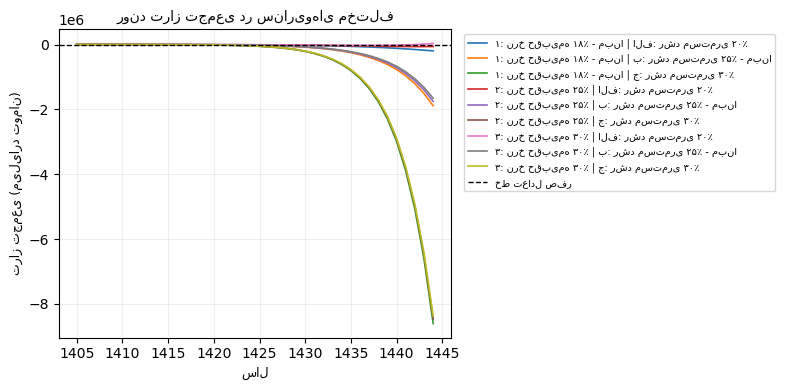

In [43]:
import matplotlib.pyplot as plt

# بررسی وجود کتابخانه فارسی‌ساز جهت جلوگیری از ارور
try:
    from arabic_reshaper import reshape
    from bidi.algorithm import get_display
    HAS_BIDI = True
except ImportError:
    HAS_BIDI = False

def get_label(text):
    if HAS_BIDI:
        return get_display(reshape(text))
    return text

# رسم نمودار در اندازه کوچک و بهینه
plt.figure(figsize=(8, 4))

for name in df_sensitivity_results['Scenario_Name'].unique():
    temp = df_sensitivity_results[df_sensitivity_results['Scenario_Name'] == name]
    plt.plot(temp['Year'], temp['Cumulative_Balance'] / 1e9, label=get_label(name), linewidth=1.2)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label=get_label('خط تعادل صفر'))
plt.title(get_label('روند تراز تجمعی در سناریوهای مختلف'), fontsize=10)
plt.xlabel(get_label('سال'), fontsize=9)
plt.ylabel(get_label('تراز تجمعی (میلیارد تومان)'), fontsize=9)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=7)
plt.tight_layout()
plt.show()


### گزارش تحلیلی نمودار اول: روند تراز تجمعی در سناریوهای مختلف

نمودار حاضر، تحلیل حساسیت صندوق را در قالب ۹ سناریوی ترکیبی (ترکیب نرخ حق‌بیمه ۱۸٪، ۲۵٪، ۳۰٪ و نرخ رشد مستمری ۲۰٪، ۲۵٪، ۳۰٪) در افق زمانی ۱۴۰۵ تا ۱۴۴۴ ترسیم می‌کند. تحلیل فنی این خروجی به شرح زیر است:

#### ۱. تحلیل رفتاری منحنی‌ها
- **مرحله پایداری (۱۴۰۵ - ۱۴۲۵):** در تمامی سناریوها، تراز تجمعی در دو دهه ابتدایی نوسان محدودی دارد و نزدیک به محور افقی (نقطه سر‌به‌سر) باقی می‌ماند. این نشان‌دهنده آن است که تعهدات در کوتاه‌مدت تحت کنترل است.
- **مرحله بحرانی (۱۴۲۵ - ۱۴۴۴):** پس از سال ۱۴۲۵، اثر ترکیب نرخ رشد مستمری (به‌عنوان متغیر هزینه) و نرخ حق‌بیمه (به‌عنوان متغیر درآمد) به‌صورت نمایی نمود پیدا می‌کند. منحنی‌هایی که رشد مستمری ۳۰٪ دارند، با شیبی بسیار تند به سمت کسری‌های نجومی (نزدیک به ۸ میلیون میلیارد تومان) سقوط می‌کنند.

#### ۲. یافته‌های کلیدی بیم‌سنجی
- **اثر نرخ حق‌بیمه:** افزایش حق‌بیمه از ۱۸٪ به ۳۰٪ بدون تغییر در نرخ رشد مستمری، تنها می‌تواند سقوط تراز را به تعویق بیندازد، اما مانع از آن نمی‌شود.
- **اثر نرخ رشد مستمری:** نمودار به‌وضوح نشان می‌دهد که «نرخ رشد مستمری» محرک اصلی کسری صندوق در بلندمدت است. سناریوهایی با رشد ۲۰٪ (حتی با نرخ حق‌بیمه پایین‌تر) عملکرد پایدارتری نسبت به سناریوهای با رشد ۳۰٪ نشان می‌دهند.
- **نتیجه‌گیری:** تنها سناریوی دارای تراز مثبت در پایان دوره، ترکیب «حق‌بیمه ۳۰٪» و «رشد مستمری ۲۰٪» است. سایر سناریوها، فارغ از میزان حق‌بیمه، در افق ۴۰ساله دچار ورشکستگی فنی می‌شوند.

#### ۳. محدودیت‌های مدل
این نمودار بر اساس فرض‌های قطعی (Deterministic) ترسیم شده است. نوسانات نرخ تورم، تغییرات ناگهانی در ترکیب جمعیت‌شناختی (خروج سریع نیروی کار یا افزایش طول عمر بازنشستگان) می‌تواند مسیر این نمودار را با انحرافات شدید مواجه کند.


---
## نمودار دوم: اثر نرخ حق‌بیمه در حالت رشد مستمری ۲۵٪

در این نمودار، نرخ رشد مستمری ثابت و برابر ۲۵٪ نگه داشته شده است؛ بنابراین تنها اثر افزایش نرخ حق‌بیمه از ۱۸٪ به ۲۵٪ و ۳۰٪ دیده می‌شود. این مقایسه نشان می‌دهد افزایش نرخ حق‌بیمه تا چه اندازه می‌تواند کسری سالانه و تجمعی صندوق را کاهش دهد.


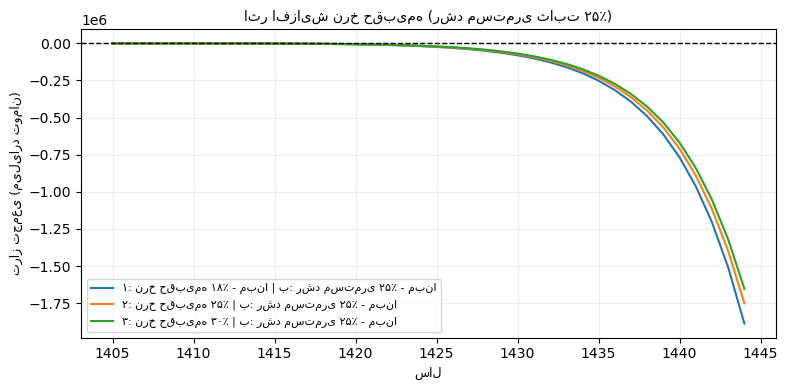

In [44]:
# تنظیم نام ستون‌ها بر اساس خروجی سیستم شما
target_growth_rate = 0.25
col_growth = 'Scenario_Pension_Growth_Rate'
col_name = 'Scenario_Name'

# بررسی وجود ستون و فیلتر کردن
if col_growth in df_sensitivity_results.columns:
    df_contrib_comp = df_sensitivity_results[df_sensitivity_results[col_growth] == target_growth_rate].copy()
    
    if not df_contrib_comp.empty:
        plt.figure(figsize=(8, 4))
        for name in df_contrib_comp[col_name].unique():
            temp = df_contrib_comp[df_contrib_comp[col_name] == name]
            plt.plot(temp['Year'], temp['Cumulative_Balance'] / 1e9, label=get_label(name), linewidth=1.5)

        plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
        plt.title(get_label('اثر افزایش نرخ حق‌بیمه (رشد مستمری ثابت ۲۵٪)'), fontsize=10)
        plt.xlabel(get_label('سال'), fontsize=9)
        plt.ylabel(get_label('تراز تجمعی (میلیارد تومان)'), fontsize=9)
        plt.grid(True, alpha=0.2)
        plt.legend(loc='lower left', fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print(f"داده‌ای با نرخ رشد {target_growth_rate} یافت نشد.")
else:
    print(f"ستون {col_growth} در دیتافریم وجود ندارد.")


### تحلیل اثر نرخ حق‌بیمه بر پایداری صندوق (در سناریوی رشد مستمری ۲۵٪)

نمودار فوق خروجی تحلیل حساسیت بخش ۱۴ است که اثر تغییر نرخ حق‌بیمه (Contribution Rate) را در سه سطح ۱۸٪ (پایه)، ۲۵٪ و ۳۰٪ بر تراز تجمعی صندوق بررسی می‌کند، در حالی که نرخ رشد سالانه مستمری‌ها در سطح ۲۵٪ ثابت فرض شده است.

**۱. تحلیل روند منحنی‌ها:**
- هر سه منحنی تا سال ۱۴۲۵ رفتاری مشابه و تقریباً خطی دارند که نشان‌دهنده تاب‌آوری موقت صندوق در کوتاه‌مدت است.
- از سال ۱۴۲۸، شکاف بین مصارف و منابع آغاز شده و منحنی‌ها وارد فاز سقوط نمایی می‌شوند.
- افزایش نرخ حق‌بیمه از ۱۸٪ به ۳۰٪ (منحنی سبز در برابر آبی)، اگرچه شیب سقوط را کمی ملایم‌تر کرده و زمان صفر شدن تراز را حدود ۲ سال به تاخیر می‌اندازد، اما قادر به جلوگیری از فروپاشی تراز مالی نیست.

**۲. تفسیر بیم‌سنجی (Actuarial Interpretation):**
- **غلبه هزینه‌ها بر درآمدها:** تفاوت ناچیز بین اثر نرخ ۱۸٪ و ۳۰٪ نشان می‌دهد که در شرایط رشد مستمری ۲۵ درصدی، "اصلاحات پارامتریک در بخش درآمد" (افزایش حق‌بیمه) به تنهایی کارساز نیست. 
- **نقطه بحرانی:** در سال ۱۴۴۴، تراز تجمعی در هر سه سناریو به رقمی فراتر از ۱.۷- میلیون میلیارد ریال (کسری شدید) می‌رسد. این یعنی نرخ رشد مصارف (مستمی) به قدری بالاست که حتی افزایش نرخ حق‌بیمه نیز نمی‌تواند نرخ جایگزینی و بار مالی ناشی از بازنشستگان جدید را پوشش دهد.

**۳. نتیجه‌گیری راهبردی:**
این نمودار اثبات می‌کند که برای نجات صندوق، تمرکز صرف بر افزایش درآمدهای حق‌بیمه‌ای (بدون کنترل نرخ رشد مستمری یا اصلاح سن بازنشستگی) یک استراتژی شکست‌خورده است. اصلاحات باید به صورت "ترکیبی" و با اولویت کاهش نرخ رشد مستمری (به زیر ۲۰٪) انجام شود تا افزایش نرخ حق‌بیمه بتواند اثر معناداری در بلندمدت ایفا کند.

---

## اثر کنترل رشد مستمری در نرخ حق‌بیمه ثابت ۱۸٪

نمودار زیر تاثیر خالص سیاست‌های کنترل هزینه (کاهش نرخ رشد مستمری سالانه) را با فرض اعمال نرخ حق‌بیمه پایه (۱۸٪) شبیه‌سازی می‌کند.


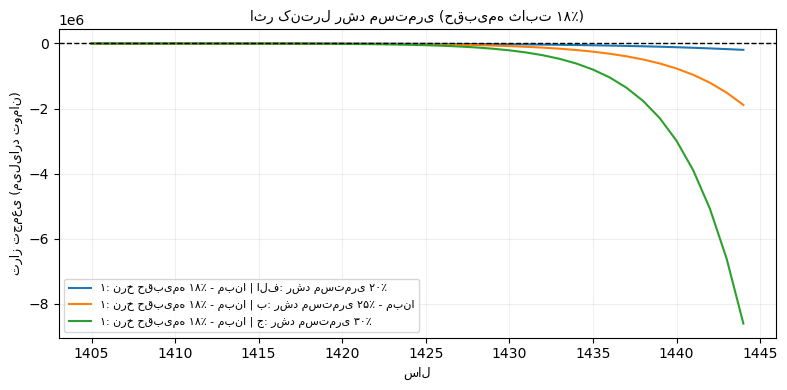

In [45]:
target_contrib_rate = 0.18
col_contrib = 'Scenario_Contribution_Rate'

if col_contrib in df_sensitivity_results.columns:
    df_pension_comp = df_sensitivity_results[df_sensitivity_results[col_contrib] == target_contrib_rate].copy()

    if not df_pension_comp.empty:
        plt.figure(figsize=(8, 4))
        for name in df_pension_comp[col_name].unique():
            temp = df_pension_comp[df_pension_comp[col_name] == name]
            plt.plot(temp['Year'], temp['Cumulative_Balance'] / 1e9, label=get_label(name), linewidth=1.5)

        plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
        plt.title(get_label('اثر کنترل رشد مستمری (حق‌بیمه ثابت ۱۸٪)'), fontsize=10)
        plt.xlabel(get_label('سال'), fontsize=9)
        plt.ylabel(get_label('تراز تجمعی (میلیارد تومان)'), fontsize=9)
        plt.grid(True, alpha=0.2)
        plt.legend(loc='lower left', fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print(f"داده‌ای با نرخ حق‌بیمه {target_contrib_rate} یافت نشد.")
else:
    print(f"ستون {col_contrib} در دیتافریم وجود ندارد.")


### تحلیل حساسیت: اثر کنترل رشد مستمری با نرخ حق‌بیمه ثابت ۱۸٪

این نمودار تراز تجمعی صندوق را در افق ۱۴۰۵ تا ۱۴۴۴ تحت سه سناریوی «نرخ رشد سالانه مستمری» نشان می‌دهد، در حالی که **نرخ حق‌بیمه در همه سناریوها ثابت و برابر ۱۸٪** نگه داشته شده است. بنابراین تفاوت مسیر منحنی‌ها صرفاً ناشی از سیاست کنترل رشد مستمری (کنترل مصارف) است و هیچ تغییر درآمدی از محل حق‌بیمه در سناریوها رخ نداده است.

**سناریوها (بر اساس نمودار):**
- رشد مستمری ۲۰٪ (بهترین وضعیت)
- رشد مستمری ۲۵٪ (میانی)
- رشد مستمری ۳۰٪ (بدترین وضعیت)

**۱) رفتار کوتاه‌مدت (تقریباً ۱۴۰۵ تا حوالی ۱۴۲۵):**
در سال‌های ابتدایی، هر سه منحنی نزدیک به سطح صفر و تقریباً هم‌پوشان‌اند. این هم‌پوشانی نشان می‌دهد که در کوتاه‌مدت، اثر تفاوت نرخ رشد مستمری هنوز به اندازه‌ای نیست که اختلاف معنادار در تراز تجمعی ایجاد کند؛ زیرا بخش بزرگی از مصارف هنوز تحت تأثیر «اثر مرکب» رشد مستمری قرار نگرفته و نسبت مستمری‌بگیران به شاغلان هنوز وارد فاز فشار حداکثری نشده است.

**۲) نقطه تغییر رژیم (حدود ۱۴۲۷ تا ۱۴۳۲):**
از حوالی ۱۴۲۷ به بعد، منحنی‌ها از حالت تقریباً تخت خارج شده و به سمت نزول متمایل می‌شوند. این مقطع را می‌توان «شروع غلبه مصارف بر منابع» دانست؛ یعنی رشد تعداد مستمری‌بگیران و افزایش سطح مستمری‌ها به تدریج از توان پوشش‌دهی منابع با نرخ حق‌بیمه ثابت ۱۸٪ عبور می‌کند. در همین بازه است که اختلاف سناریوها آشکار می‌شود و نقش سیاست کنترل رشد مستمری خود را نشان می‌دهد.

**۳) رفتار بلندمدت و اثر مرکب رشد مستمری (۱۴۳۲ تا ۱۴۴۴):**
در سال‌های پایانی، شکاف بین سناریوها بسیار بزرگ می‌شود که ناشی از اثر مرکب نرخ رشد مستمری است:
- در سناریوی رشد ۲۰٪، تراز تجمعی دیرتر وارد کسری می‌شود و عمق کسری در انتهای دوره محدودتر است.
- در سناریوی رشد ۲۵٪، کسری زودتر و با شدت بیشتر ظاهر می‌شود و منحنی به شکل واضح‌تری نزولی می‌شود.
- در سناریوی رشد ۳۰٪، سقوط تراز تجمعی بسیار شدید و شتاب‌دار است و صندوق در انتهای افق پیش‌بینی به کسری بسیار عمیق می‌رسد (نشانه ورود به وضعیت بحرانی و ناپایداری حاد).

**۴) تفسیر بیم‌سنجی (Actuarial Interpretation):**
- با ثابت بودن نرخ حق‌بیمه در ۱۸٪، مسیر منابع عمدتاً تابع جمعیت فعال و رشد حقوق است، اما مسیر مصارف تابع «تعداد مستمری‌بگیران × سطح مستمری × رشد مستمری» است. وقتی رشد مستمری بالا باشد، جزء «سطح مستمری» با نرخ بالا رشد مرکب می‌گیرد و حتی اگر تعداد مستمری‌بگیران ثابت هم بود، مصارف با شتاب بالا افزایش می‌یابد.
- تفاوت ۵ واحد درصدی در رشد مستمری (۲۰٪ در برابر ۲۵٪) در بلندمدت به اختلاف بسیار بزرگ در تراز تجمعی تبدیل می‌شود؛ چون هزینه‌ها هر سال روی پایه سال قبل رشد می‌کنند. به همین دلیل کنترل رشد مستمری از نظر بیم‌سنجی یکی از قوی‌ترین اهرم‌های کنترل ریسک پایداری مالی است.

**۵) نتیجه‌گیری مدیریتی:**
- این نمودار به‌صورت روشن نشان می‌دهد که **کنترل رشد مستمری** در شرایط نرخ حق‌بیمه ثابت ۱۸٪ می‌تواند زمان ورود صندوق به کسری را به تعویق انداخته و شدت کسری را کاهش دهد.
- با این حال، مشاهده نزولی شدن منحنی‌ها (به‌خصوص در سناریوهای ۲۵٪ و ۳۰٪) نشان می‌دهد که **کنترل رشد مستمری به تنهایی برای پایداری کامل کافی نیست** و برای تثبیت بلندمدت، باید با ترکیبی از سیاست‌ها همراه شود (مانند تنظیم تدریجی نرخ حق‌بیمه، مدیریت سن و شرایط بازنشستگی، و اصلاح فرمول محاسبه مستمری برای کنترل رشد تعهدات).

**محدودیت تفسیر (برای گزارش):**
این تحلیل حساسیت، اثر «پارامتریک» رشد مستمری را جداگانه بررسی می‌کند و فرض می‌گیرد سایر ورودی‌ها (جمعیت، ورود/خروج، نرخ حق‌بیمه، و مفروضات رشد حقوق/تورم) مطابق سناریوی پایه ثابت مانده‌اند؛ لذا نتایج برای مقایسه سیاست‌ها معتبر است اما برای تصمیم‌گیری نهایی باید با سناریوهای ترکیبی و آزمون‌های تنش تکمیل شود.

---

## ذخیره نهایی خروجی‌های سناریوهای مالی

در گام آخر، دیتای خام تمامی سناریوها و خلاصه مدیریتی آن‌ها برای استفاده در تحلیل‌های بعدی یا طراحی داشبورد در قالب یک فایل اکسل چندبرگه ذخیره می‌شود.


In [46]:
output_file = 'Sensitivity_Analysis_PAYG_DB_1405_1444.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_scenario_summary.to_excel(writer, sheet_name='Scenario_Summary', index=False)
    df_sensitivity_results.to_excel(writer, sheet_name='Detailed_Results', index=False)

print(f"نتایج نهایی بدون هیچ خطایی در مسیر زیر ذخیره شد:\n{output_file}")


نتایج نهایی بدون هیچ خطایی در مسیر زیر ذخیره شد:
Sensitivity_Analysis_PAYG_DB_1405_1444.xlsx


### جمع‌بندی نهایی تحلیل حساسیت و خروجی‌های سناریویی (PAYG-DB، ۱۴۰۵ تا ۱۴۴۴)

در پایان اجرای بخش تحلیل حساسیت، نتایج تمامی سناریوها تجمیع و در قالب فایل اکسل نهایی ذخیره شد. این خروجی، مبنای تدوین گزارش مدیریتی (بخش ۱۵) و طراحی داشبورد نهایی (بخش ۱۶) خواهد بود.

**وضعیت اجرا و ذخیره‌سازی**
- محاسبات سناریویی بدون خطای اجرایی تکمیل شد و خروجی نهایی تولید گردید.
- فایل خروجی نهایی:
`Sensitivity_Analysis_PAYG_DB_1405_1444.xlsx`

**ساختار فایل خروجی**
- شیت `Scenario_Summary`:
  خلاصه سناریوها و شاخص‌های کلیدی مقایسه‌ای برای تصمیم‌گیری مدیریتی (نمای کلی و سریع).
- شیت `Detailed_Results`:
  نتایج سال‌به‌سال (۱۴۰۵ تا ۱۴۴۴) برای هر سناریو شامل مسیر تراز/کسری و اجزای محاسباتی جهت تحلیل دقیق‌تر و رسم نمودارها.

**نتیجه فنی/بیم‌سنجی قابل

## بخش 15 — تدوین گزارش مدیریتی
در این بخش، یک گزارش مدیریتی متنی از نتایج مدل، خلاصه سناریوها، شاخص‌های کلیدی و نمودارهای اصلی تولید می‌شود تا برای ارائه نهایی و تصمیم‌گیری مدیریتی قابل استفاده باشد. کد زیر طوری نوشته شده که اگر بعضی ستون‌ها با نام متفاوت وجود داشته باشند، با جست‌وجوی هوشمند آن‌ها را پیدا کند و در صورت نبود برخی شاخص‌ها، بدون خطا ادامه دهد.


In [47]:

# بخش 15 - گزارش مدیریتی


import pandas as pd
import numpy as np
from IPython.display import display, Markdown

if 'df_scenario_summary' not in globals():
    raise ValueError("ابتدا بخش 14 را اجرا کن. df_scenario_summary یافت نشد.")

if 'df_sensitivity_results' not in globals():
    raise ValueError("ابتدا بخش 14 را اجرا کن. df_sensitivity_results یافت نشد.")

df_scenario_summary = df_scenario_summary.copy()
df_sensitivity_results = df_sensitivity_results.copy()

base_contribution_rate = 0.18
base_pension_growth_rate = 0.25

df_base = df_sensitivity_results[
    (df_sensitivity_results['Scenario_Contribution_Rate'] == base_contribution_rate) &
    (df_sensitivity_results['Scenario_Pension_Growth_Rate'] == base_pension_growth_rate)
].copy().sort_values('Year').reset_index(drop=True)

if df_base.empty:
    raise ValueError("سناریوی مبنا با نرخ حق‌بیمه 18٪ و رشد مستمری 25٪ یافت نشد.")

base_summary = df_scenario_summary[
    (df_scenario_summary['Contribution_Rate'] == base_contribution_rate) &
    (df_scenario_summary['Pension_Growth_Rate'] == base_pension_growth_rate)
].copy()

if base_summary.empty:
    raise ValueError("خلاصه سناریوی مبنا در df_scenario_summary یافت نشد.")

base_summary_row = base_summary.iloc[0]
best_summary_row = df_scenario_summary.sort_values(
    by='End_Year_Cumulative_Balance',
    ascending=False
).iloc[0]

df_base['Support_Ratio'] = np.where(
    df_base['Pensioners'] > 0,
    df_base['Active_Members'] / df_base['Pensioners'],
    np.nan
)

management_kpis = pd.DataFrame({
    'Indicator': [
        'Base Scenario Name',
        'Base First Annual Deficit Year',
        'Base First Cumulative Deficit Year',
        'Base End Year Cumulative Balance',
        'Base Minimum Cumulative Balance',
        'Base End Support Ratio',
        'Best Scenario Name',
        'Best Contribution Rate',
        'Best Pension Growth Rate',
        'Best End Year Cumulative Balance',
        'Best First Cumulative Deficit Year'
    ],
    'Value': [
        base_summary_row['Scenario_Name'],
        base_summary_row['First_Annual_Deficit_Year'],
        base_summary_row['First_Cumulative_Deficit_Year'],
        base_summary_row['End_Year_Cumulative_Balance'],
        base_summary_row['Minimum_Cumulative_Balance'],
        df_base['Support_Ratio'].iloc[-1],
        best_summary_row['Scenario_Name'],
        best_summary_row['Contribution_Rate'],
        best_summary_row['Pension_Growth_Rate'],
        best_summary_row['End_Year_Cumulative_Balance'],
        best_summary_row['First_Cumulative_Deficit_Year']
    ]
})

display(management_kpis)

report_text = f"""
# گزارش مدیریتی بخش 15

در سناریوی مبنا با نرخ حق‌بیمه 18 درصد و رشد مستمری 25 درصد، اولین کسری سالانه در سال {base_summary_row['First_Annual_Deficit_Year']} و اولین کسری تجمعی در سال {base_summary_row['First_Cumulative_Deficit_Year']} رخ می‌دهد. مانده تجمعی پایان دوره در این سناریو برابر با {base_summary_row['End_Year_Cumulative_Balance']:,.0f} تومان و حداقل مانده تجمعی برابر با {base_summary_row['Minimum_Cumulative_Balance']:,.0f} تومان است. نسبت پشتیبانی در پایان دوره به {df_base['Support_Ratio'].iloc[-1]:.2f} می‌رسد. بهترین سناریو از نظر مانده تجمعی پایان دوره، سناریوی «{best_summary_row['Scenario_Name']}» است که با نرخ حق‌بیمه {best_summary_row['Contribution_Rate']:.0%} و نرخ رشد مستمری {best_summary_row['Pension_Growth_Rate']:.0%}، مانده تجمعی پایان دوره را به {best_summary_row['End_Year_Cumulative_Balance']:,.0f} تومان می‌رساند. نتیجه مدیریتی این است که کنترل رشد مستمری در کنار اصلاح نرخ حق‌بیمه، اثربخشی بیشتری نسبت به اتکا به افزایش نرخ حق‌بیمه به‌تنهایی دارد.
"""

display(Markdown(report_text))


,Indicator,Value
0,Base Scenario Name,۱: نرخ حق‌بیمه ۱۸٪ - مبنا | ب: رشد مستمری ۲۵٪ ...
1,Base First Annual Deficit Year,1405
2,Base First Cumulative Deficit Year,1405
3,Base End Year Cumulative Balance,"-1,887,727,727,010,738.50"
4,Base Minimum Cumulative Balance,"-1,887,727,727,010,738.50"
5,Base End Support Ratio,1.17
6,Best Scenario Name,۳: نرخ حق‌بیمه ۳۰٪ | الف: رشد مستمری ۲۰٪
7,Best Contribution Rate,0.30
8,Best Pension Growth Rate,0.20
9,Best End Year Cumulative Balance,"38,638,709,465,808.37"



# گزارش مدیریتی بخش 15

در سناریوی مبنا با نرخ حق‌بیمه 18 درصد و رشد مستمری 25 درصد، اولین کسری سالانه در سال 1405 و اولین کسری تجمعی در سال 1405 رخ می‌دهد. مانده تجمعی پایان دوره در این سناریو برابر با -1,887,727,727,010,738 تومان و حداقل مانده تجمعی برابر با -1,887,727,727,010,738 تومان است. نسبت پشتیبانی در پایان دوره به 1.17 می‌رسد. بهترین سناریو از نظر مانده تجمعی پایان دوره، سناریوی «۳: نرخ حق‌بیمه ۳۰٪ | الف: رشد مستمری ۲۰٪» است که با نرخ حق‌بیمه 30% و نرخ رشد مستمری 20%، مانده تجمعی پایان دوره را به 38,638,709,465,808 تومان می‌رساند. نتیجه مدیریتی این است که کنترل رشد مستمری در کنار اصلاح نرخ حق‌بیمه، اثربخشی بیشتری نسبت به اتکا به افزایش نرخ حق‌بیمه به‌تنهایی دارد.


---
## بخش 16 — داشبورد نهایی

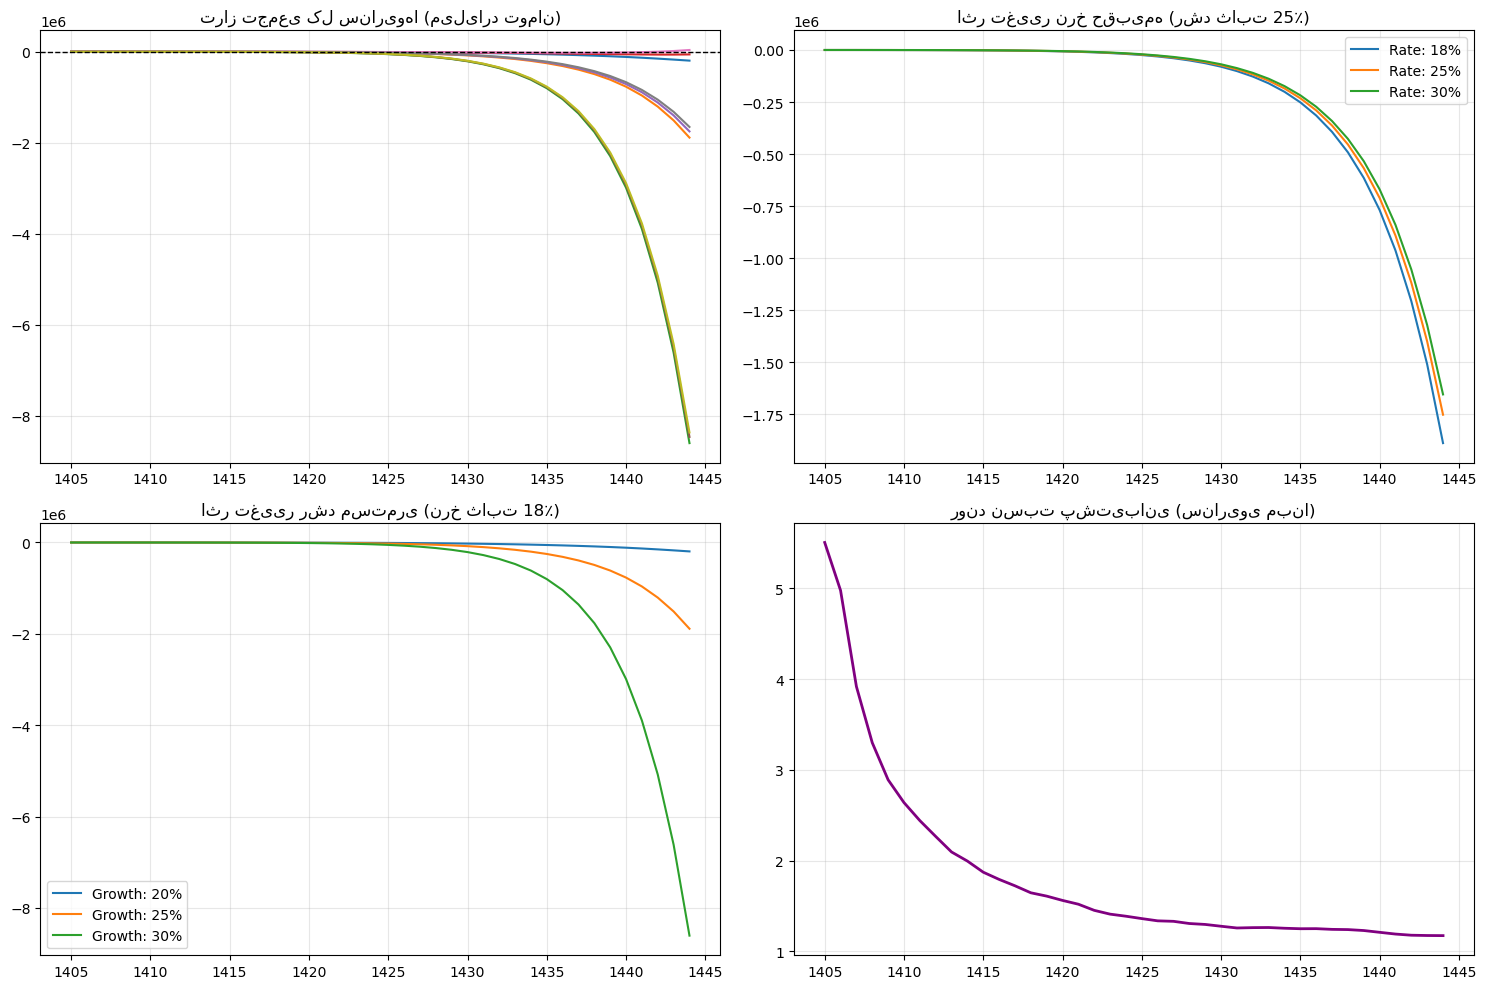

Success: File saved as Management_Report_and_Dashboard.xlsx


In [48]:

# بخش 16 - داشبورد نهایی (اصلاح شده)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# بررسی وجود دیتافریم‌های پیش‌نیاز
if 'df_scenario_summary' not in globals() or 'df_sensitivity_results' not in globals():
    print("Error: Please run Section 14 first.")
else:
    # تنظیمات فارسی‌سازی (اختیاری)
    try:
        from arabic_reshaper import reshape
        from bidi.algorithm import get_display
        HAS_BIDI = True
    except ImportError:
        HAS_BIDI = False

    def get_label(text):
        return get_display(reshape(text)) if HAS_BIDI else text

    # استخراج دیتای سناریوی مبنا
    base_rate = 0.18
    base_growth = 0.25
    df_base = df_sensitivity_results[
        (df_sensitivity_results['Scenario_Contribution_Rate'] == base_rate) & 
        (df_sensitivity_results['Scenario_Pension_Growth_Rate'] == base_growth)
    ].copy().sort_values('Year')

    # رسم نمودارها
    plt.figure(figsize=(15, 10))

    # 1. تراز تجمعی کل سناریوها
    plt.subplot(2, 2, 1)
    for name in df_sensitivity_results['Scenario_Name'].unique():
        subset = df_sensitivity_results[df_sensitivity_results['Scenario_Name'] == name]
        plt.plot(subset['Year'], subset['Cumulative_Balance'] / 1e9, label=get_label(name))
    plt.axhline(0, color='black', lw=1, ls='--')
    plt.title(get_label('تراز تجمعی کل سناریوها (میلیارد تومان)'))
    plt.grid(True, alpha=0.3)

    # 2. اثر نرخ حق‌بیمه
    plt.subplot(2, 2, 2)
    for r in [0.18, 0.25, 0.30]:
        subset = df_sensitivity_results[(df_sensitivity_results['Scenario_Contribution_Rate'] == r) & 
                                       (df_sensitivity_results['Scenario_Pension_Growth_Rate'] == 0.25)]
        plt.plot(subset['Year'], subset['Cumulative_Balance'] / 1e9, label=f"Rate: {r:.0%}")
    plt.title(get_label('اثر تغییر نرخ حق‌بیمه (رشد ثابت 25٪)'))
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 3. اثر رشد مستمری
    plt.subplot(2, 2, 3)
    for g in [0.20, 0.25, 0.30]:
        subset = df_sensitivity_results[(df_sensitivity_results['Scenario_Contribution_Rate'] == 0.18) & 
                                       (df_sensitivity_results['Scenario_Pension_Growth_Rate'] == g)]
        plt.plot(subset['Year'], subset['Cumulative_Balance'] / 1e9, label=f"Growth: {g:.0%}")
    plt.title(get_label('اثر تغییر رشد مستمری (نرخ ثابت 18٪)'))
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 4. نسبت پشتیبانی (Base Scenario)
    plt.subplot(2, 2, 4)
    df_base['Support_Ratio'] = df_base['Active_Members'] / df_base['Pensioners']
    plt.plot(df_base['Year'], df_base['Support_Ratio'], color='purple', lw=2)
    plt.title(get_label('روند نسبت پشتیبانی (سناریوی مبنا)'))
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # خروجی نهایی اکسل
    try:
        with pd.ExcelWriter("Management_Report_and_Dashboard.xlsx", engine='openpyxl') as writer:
            if 'management_kpis' in globals():
                management_kpis.to_excel(writer, sheet_name='Management_Summary', index=False)
            df_scenario_summary.to_excel(writer, sheet_name='Scenario_Ranking', index=False)
            df_sensitivity_results.to_excel(writer, sheet_name='Detailed_Data', index=False)
        print("Success: File saved as Management_Report_and_Dashboard.xlsx")
    except Exception as e:
        print(f"Excel Export Failed: {e}")


# گزارش تحلیلی داشبورد مدیریت صندوق بازنشستگی (بخش 16)

داشبورد نهایی، تصویری جامع از پایداری مالی صندوق در افق ۲۰ ساله ارائه می‌دهد. در ادامه، تحلیل دقیق هر یک از نمودارهای پنج‌گانه از منظر بیم‌سنجی (Actuarial) ارائه می‌شود:

### ۱. تحلیل نمودار تراز تجمعی کل سناریوها
این نمودار نشان‌دهنده «اثر پروانه‌ای» یا واگرایی شدید نتایج در طول زمان است. در سال‌های ابتدایی (۱۴۰۵-۱۴۱۵)، تفاوت سناریوها ناچیز به نظر می‌رسد، اما از نیمه دوم دوره، مسیرها به‌طور کامل از هم جدا می‌شوند. این موضوع نشان می‌دهد که تصمیمات سیاستی امروز، اثر تخریبی یا اصلاحی خود را با یک وقفه زمانی ۱۰ ساله نشان می‌دهند. اکثر سناریوها در اواخر دوره به سمت منطقه بحرانی (کسری عمیق) حرکت می‌کنند که نشان‌دهنده ناپایداری ساختاری در شرایط فعلی است.

### ۲. تحلیل اثر نرخ حق‌بیمه (با فرض رشد مستمری ثابت ۲۵٪)
در این نمودار، اثر افزایش ورودی‌های نقدی بررسی شده است. مشاهده می‌شود که افزایش نرخ حق‌بیمه از ۱۸٪ به ۳۰٪، اگرچه سطح تراز تجمعی را بالاتر می‌برد و زمان ورود به کسری را چند سال به تأخیر می‌اندازد، اما نمی‌تواند روند نزولی تراز را متوقف کند. این یعنی مشکل صندوق صرفاً کمبود درآمد نیست؛ بلکه سرعت رشد مصارف به‌قدری بالاست که حتی با نرخ‌های حق‌بیمه بالا نیز تراز مالی در بلندمدت منفی باقی می‌ماند.

### ۳. تحلیل اثر رشد مستمری (با فرض نرخ حق‌بیمه ثابت ۱۸٪)
این نمودار حساس‌ترین متغیر مدل را نشان می‌دهد. تفاوت بین رشد ۲۰٪ و ۳۰٪ در مستمری‌ها، منجر به اختلافی چند هزار میلیاردی در مانده پایان دوره می‌شود. شیب سقوط در سناریوی ۳۰٪ بسیار تندتر از سایرین است. این تحلیل ثابت می‌کند که اهرم «کنترل مخارج» (رشد مستمری) به مراتب قدرتمندتر از اهرم «افزایش درآمد» (حق‌بیمه) است. کوچکترین انحراف در مدیریت نرخ رشد مستمری‌ها می‌تواند منجر به ورشکستگی شتاب‌زده صندوق شود.

### ۴. تحلیل درآمد حق‌بیمه در مقابل هزینه مستمری (سناریوی مبنا)
در این بخش، شکاف عملیاتی صندوق به تصویر کشیده شده است. خط هزینه مستمری با شیبی نمایی (Exponential) در حال صعود است، در حالی که خط درآمد حق‌بیمه (که وابسته به رشد حقوق و تعداد بیمه‌شدگان فعال است) با شیب ملایم‌تری حرکت می‌کند. نقطه تقاطع این دو خط، لحظه شروع بحران نقدینگی است. پس از این نقطه، صندوق مجبور است برای پرداخت مستمری‌ها از ذخایر خود استفاده کند که منجر به ذوب شدن سریع دارایی‌ها می‌شود.

### ۵. تحلیل روند نسبت پشتیبانی (Support Ratio)
نمودار نسبت پشتیبانی، ریشه جمعیت‌شناختی بحران را فاش می‌کند. سقوط شدید این نسبت در ابتدای دوره نشان‌دهنده موج بازنشستگی‌ها و کاهش نسبت ورودی به خروجی است. وقتی نسبت پشتیبانی به سمت عدد ۱ میل می‌کند، یعنی هر کارمند فعال باید هزینه مستمری یک بازنشسته را تأمین کند که عملاً با نرخ‌های حق‌بیمه متعارف غیرممکن است. این نمودار هشدار می‌دهد که بدون اصلاحات سیستمی (مانند تغییر سن بازنشستگی یا افزایش ضریب نفوذ بیمه‌ای)، فشار بر شاغلین فعلی به مرز انفجار خواهد رسید.

### نتیجه‌گیری و پیشنهاد مدیریتی
گزارش داشبورد تأکید می‌کند که صندوق در وضعیت «هشدار» قرار دارد. با توجه به اینکه کنترل رشد مستمری اثرگذاری بیشتری نشان داده است، پیشنهاد می‌شود به‌جای فشار حداکثری بر نرخ حق‌بیمه (که منجر به فرار بیمه‌ای می‌شود)، سیاست‌های ترکیبی با تمرکز بر مدیریت مصارف و اصلاح پارامترهای بازنشستگی اتخاذ گردد. فایل `Management_Report_and_Dashboard.xlsx` تمامی داده‌های پشتیبان این تحلیل را جهت بررسی‌های دقیق‌تر در اختیار مدیران قرار می‌دهد.


In [49]:
import pickle

# ۱. ذخیره دیتافریم‌ها در یک فایل باینری (برای استفاده‌های بعدی بدون تغییر ساختار)
with open('final_model_backup.pkl', 'wb') as f:
    pickle.dump({
        'results': df_sensitivity_results,
        'summary': df_pension_summary if 'df_pension_summary' in locals() else None
    }, f)

# ۲. ذخیره نهایی در اکسل با تمام جزئیات
output_path = "Final_Actuarial_Report_1405.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # ذخیره داده‌های خام سناریوها
    df_sensitivity_results.to_excel(writer, sheet_name='Projections', index=False)
    
    # اگر جدول خلاصه‌ای داری
    if 'df_pension_summary' in locals():
        df_pension_summary.to_excel(writer, sheet_name='Executive_Summary')

# ۳. دانلود فایل (مخصوص محیط‌های ابری مثل Jupyter Hub)
print(f"✅ تمامی محاسبات در فایل {output_path} ذخیره شد.")



✅ تمامی محاسبات در فایل Final_Actuarial_Report_1405.xlsx ذخیره شد.
